# **Deteção de Branqueamento de Capitais (AML) - Caso Prático Nº.3**

**UC: Métodos Analíticos de Deteção de Fraude**

* Ana Rita Taborda - Nº108418
* Artur Albuquerque - Nº142299
* Pedro Franco - Nº140929
* Tiago Nunes - Nº142186

**Índice**

1. Introdução ao Problema
2. Caracterização do Dataset
3. Exploração Inicial do Dataset
4. Regras de Deteção
5. Análise Threshold
6. Lei de Benford
7. Z-Score
8. Análise Descritiva
9. Clusterização
10. Network Analysis
11. Matriz de Convergência
12. Casos Suspeitos
13. KPI´s
14. Medidas Preventivas
15. Conclusão

## **1. Introdução ao Problema**

O branqueamento de capitais (Anti-Money Laundering – AML) consiste no processo de ocultar a origem ilícita de fundos através de operações financeiras que lhes conferem uma aparência de legalidade.

Entre os esquemas mais comuns destacam-se o Smurfing, que consiste no fracionamento de grandes quantias em múltiplas transações abaixo do limiar de reporte obrigatório, e o Money Mule, em que contas bancárias são utilizadas como intermediárias para receber e reenviar fundos, dificultando o rastreio da sua origem.

Neste projeto foi desenvolvido um sistema de deteção de fraude baseado na análise de um conjunto de transações bancárias.

A abordagem combina diferentes técnicas analíticas, incluindo regras de negócio, análise de thresholds, Lei de Benford, Z-Score, clustering (K-Means) e análise de redes (Network Analysis), permitindo identificar clientes com padrões comportamentais compatíveis com esquemas de branqueamento de capitais.

O objetivo final consiste em produzir uma lista priorizada de clientes suspeitos, suportada por múltiplas evidências independentes, funcionando como uma ferramenta de apoio à decisão para equipas de prevenção e investigação de fraude.

## **2. Caracterização do Dataset**

O dataset utilizado neste caso prático representa um conjunto de operações bancárias entre janeiro e abril de 2026, contendo informação sobre clientes, contas, beneficiários, relações entre entidades e transações financeiras.

O conjunto de dados é composto por cinco tabelas relacionais:
| Tabela                        | Nº de registos |
| ----------------------------- | -------------: |
| Clientes                      |          1.000 |
| Contas                        |          1.300 |
| Beneficiários                 |          2.000 |
| Relações Cliente–Beneficiário |         14.856 |
| Transações                    |         15.158 |

As transações incluem informação como o valor movimentado, tipo de operação, data e hora, país de destino, utilização de numerário e diversos indicadores de risco relevantes para a análise AML.

Antes do desenvolvimento do sistema de deteção foi efetuada uma fase de exploração e validação da qualidade dos dados, incluindo a verificação da existência de valores em falta, duplicados, consistência entre tabelas e integridade referencial.

## **3. Exploração Inicial do Dataset**

Antes da construção do sistema de deteção foi realizada uma análise exploratória dos dados (Exploratory Data Analysis – EDA), com o objetivo de compreender a estrutura do dataset, verificar a qualidade da informação disponível e garantir que os dados apresentavam condições adequadas para as análises seguintes.

#### **3.1. Importação de Bibliotecas**

Nesta fase são importadas as bibliotecas necessárias para manipulação dos dados, análise estatística, visualização gráfica e análise de redes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare
import networkx as nx
print("networkx disponível, versão:", nx.__version__)

networkx disponível, versão: 3.6.1


#### **3.2. Importação do Dataset**

O ficheiro Excel é carregado e cada folha é armazenada num DataFrame independente, permitindo trabalhar separadamente clientes, contas, beneficiários, relações e transações.

In [2]:
import pandas as pd
from google.colab import files

# Nome esperado do ficheiro
ficheiro = "Caso Pratico 3 - AML.xlsx"

# Tentar carregar diretamente; caso não exista, pedir upload
try:
    xl = pd.ExcelFile(ficheiro)
except FileNotFoundError:
    uploaded = files.upload()
    ficheiro = next(iter(uploaded))
    xl = pd.ExcelFile(ficheiro)

# Carregar cada folha para um DataFrame
tx = pd.read_excel(xl, "Transactions")
cl = pd.read_excel(xl, "Clients")
ac = pd.read_excel(xl, "Accounts")
be = pd.read_excel(xl, "Beneficiaries")
rel = pd.read_excel(xl, "Relationships")

print(f"Dataset '{ficheiro}' carregado com sucesso.")
print("Folhas encontradas:", xl.sheet_names)

Dataset 'Caso Pratico 3 - AML.xlsx' carregado com sucesso.
Folhas encontradas: ['Clients', 'Accounts', 'Beneficiaries', 'Relationships', 'Transactions']


In [3]:
# Criar resumo das tabelas
resumo = pd.DataFrame({
    "Tabela": [
        "Transactions",
        "Clients",
        "Accounts",
        "Beneficiaries",
        "Relationships"
    ],
    "Registos": [
        len(tx),
        len(cl),
        len(ac),
        len(be),
        len(rel)
    ],
    "Variáveis": [
        tx.shape[1],
        cl.shape[1],
        ac.shape[1],
        be.shape[1],
        rel.shape[1]
    ]
})

# Apresentar resumo
print("=" * 55)
print("ESTRUTURA DO DATASET")
print("=" * 55)

display(
    resumo.style
    .format({"Registos": "{:,.0f}", "Variáveis": "{:,.0f}"})
    .hide(axis="index")
)

print(f"\nTotal de registos nas cinco tabelas: {resumo['Registos'].sum():,}")

ESTRUTURA DO DATASET


Tabela,Registos,Variáveis
Transactions,"15,158",19
Clients,"1,000",34
Accounts,"1,300",7
Beneficiaries,"2,000",4
Relationships,"14,856",8



Total de registos nas cinco tabelas: 34,314


O dataset é constituído por cinco tabelas relacionais que representam diferentes entidades do sistema bancário: clientes, contas, beneficiários, relações entre clientes e beneficiários e transações. Esta estrutura permite analisar simultaneamente o comportamento individual dos clientes e as ligações existentes entre diferentes entidades financeiras.

#### **3.3 Qualidade dos Dados**

Antes de avançar para a análise, foi avaliada a qualidade do dataset, verificando a existência de valores em falta, registos duplicados e possíveis inconsistências entre as diferentes tabelas. Esta etapa permite garantir que os resultados obtidos nas análises seguintes não são influenciados por problemas de estrutura ou qualidade da informação.

In [4]:
# Dicionário com as tabelas do dataset
tabelas = {
    "Transactions": tx,
    "Clients": cl,
    "Accounts": ac,
    "Beneficiaries": be,
    "Relationships": rel
}

# Criar resumo da qualidade dos dados
qualidade = []

for nome, df in tabelas.items():
    qualidade.append({
        "Tabela": nome,
        "Registos": len(df),
        "Variáveis": df.shape[1],
        "Valores em falta": int(df.isna().sum().sum()),
        "Linhas duplicadas": int(df.duplicated().sum())
    })

qualidade_df = pd.DataFrame(qualidade)

display(
    qualidade_df.style
    .format({
        "Registos": "{:,.0f}",
        "Variáveis": "{:,.0f}",
        "Valores em falta": "{:,.0f}",
        "Linhas duplicadas": "{:,.0f}"
    })
    .hide(axis="index")
)

Tabela,Registos,Variáveis,Valores em falta,Linhas duplicadas
Transactions,"15,158",19,0,0
Clients,"1,000",34,0,0
Accounts,"1,300",7,0,0
Beneficiaries,"2,000",4,0,0
Relationships,"14,856",8,0,0


In [5]:
# Verificação da unicidade dos principais identificadores
verificacao_ids = pd.DataFrame({
    "Tabela": [
        "Clients",
        "Accounts",
        "Beneficiaries",
        "Transactions"
    ],
    "Identificador": [
        "ClientID",
        "AccountID",
        "BeneficiaryID",
        "TransactionID"
    ],
    "Duplicados": [
        cl["ClientID"].duplicated().sum(),
        ac["AccountID"].duplicated().sum(),
        be["BeneficiaryID"].duplicated().sum(),
        tx["TransactionID"].duplicated().sum()
    ]
})

display(verificacao_ids.style.hide(axis="index"))

Tabela,Identificador,Duplicados
Clients,ClientID,0
Accounts,AccountID,0
Beneficiaries,BeneficiaryID,0
Transactions,TransactionID,0


In [6]:
# Integridade referencial entre tabelas

integridade = pd.DataFrame({
    "Verificação": [
        "Contas com ClientID inexistente",
        "Transações com AccountID inexistente",
        "Transações com ClientID inexistente",
        "Transações com BeneficiaryID inexistente",
        "Relações com ClientID inexistente",
        "Relações com BeneficiaryID inexistente"
    ],
    "Inconsistências": [
        (~ac["ClientID"].isin(cl["ClientID"])).sum(),
        (~tx["AccountID"].isin(ac["AccountID"])).sum(),
        (~tx["ClientID"].isin(cl["ClientID"])).sum(),
        (~tx["BeneficiaryID"].isin(be["BeneficiaryID"])).sum(),
        (~rel["ClientID"].isin(cl["ClientID"])).sum(),
        (~rel["BeneficiaryID"].isin(be["BeneficiaryID"])).sum()
    ]
})

display(integridade.style.hide(axis="index"))

Verificação,Inconsistências
Contas com ClientID inexistente,0
Transações com AccountID inexistente,0
Transações com ClientID inexistente,0
Transações com BeneficiaryID inexistente,0
Relações com ClientID inexistente,0
Relações com BeneficiaryID inexistente,0


#### **3.4. Conclusão**

A análise da qualidade dos dados não identificou valores em falta nem linhas duplicadas nas tabelas utilizadas.

Os principais identificadores apresentam unicidade e as relações entre clientes, contas, beneficiários e transações revelam integridade referencial.

Desta forma, não foi necessário eliminar ou imputar registos antes de avançar para as análises seguintes.

## **4. Regras de Deteção**

### **4.1. Regra 1 – Transação imediatamente abaixo dos 10 000€**

In [7]:
tx_rules = tx.copy()

tx_rules["Rule_Threshold"] = (tx_rules["Entre 9000 e 9999 euros"] == 1)

print("Transações sinalizadas:", tx_rules["Rule_Threshold"].sum())

Transações sinalizadas: 765


#### **Resumo Regra 1**

A Regra 1 identifica transações de montante elevado situadas imediatamente abaixo do limiar de reporte regulamentar, entre 9.000€ e 9.999€, restringindo a análise aos tipos de operação mais compatíveis com fracionamento de fundos, nomeadamente depósitos em numerário e transferências.

Do ponto de vista analítico, esta regra funciona como um filtro de primeira linha para captar padrões de estruturação deliberada de transações, nos quais o agente distribui artificialmente os montantes por várias operações de valor semelhante de forma a evitar a ultrapassagem do limite legal de 10.000€.

A relevância desta regra em AML é elevada porque o smurfing se manifesta precisamente como uma concentração anómala de operações na zona imediatamente inferior ao limiar regulatório, padrão que raramente corresponde a comportamento financeiro espontâneo e que, por isso, justifica prioridade de investigação.

No contexto do caso prático, esta regra é particularmente útil para identificar clientes que apresentam um comportamento repetido de fracionamento e que, em combinação com outras técnicas, reforçam a hipótese de smurfing.

#### **4.1.2 - Gráfico Regra 1**

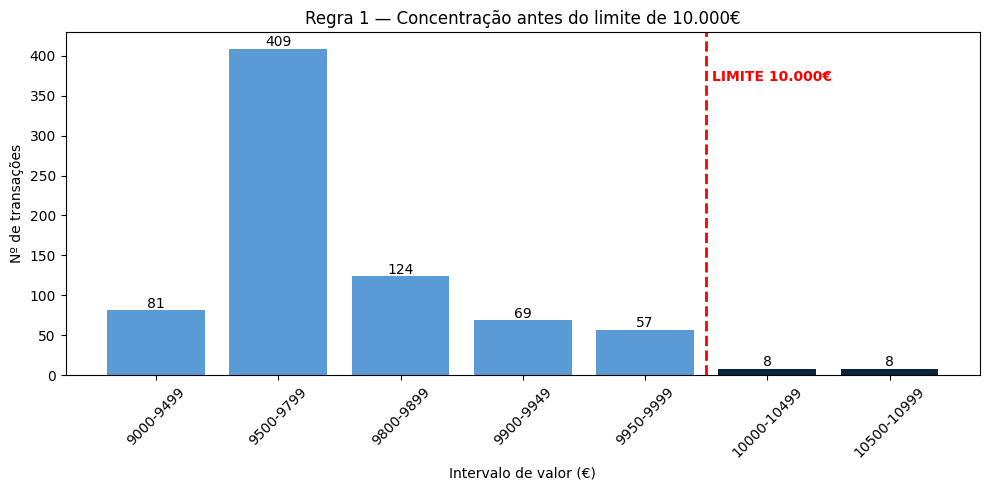

In [8]:
tipos_relevantes = ["CashDeposit", "Transfer", "InstantTransfer"]

tx_rule1 = tx[tx["TransactionType"].isin(tipos_relevantes)].copy()

bins = [9000, 9500, 9800, 9900, 9950, 10000, 10500, 11000]
labels = [
    "9000-9499",
    "9500-9799",
    "9800-9899",
    "9900-9949",
    "9950-9999",
    "10000-10499",
    "10500-10999"
]

tx_rule1["intervalo"] = pd.cut(
    tx_rule1["AmountEUR"],
    bins=bins,
    labels=labels,
    right=False
)

contagem_rule1 = tx_rule1["intervalo"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))

cores = ["#5B9BD5"] * 5 + ["#0A2540"] * 2
bars = ax.bar(
    contagem_rule1.index.astype(str),
    contagem_rule1.values,
    color=cores
)

ax.axvline(4.5, color="red", linestyle="--", linewidth=2)
ax.text(
    4.55,
    contagem_rule1.max() * 0.9,
    "LIMITE 10.000€",
    color="red",
    fontweight="bold"
)

for bar, v in zip(bars, contagem_rule1.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 3,
        str(v),
        ha="center"
    )

ax.set_title("Regra 1 — Concentração antes do limite de 10.000€")
ax.set_xlabel("Intervalo de valor (€)")
ax.set_ylabel("Nº de transações")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **4.2. Regra 2 — Destino de risco elevado**

In [9]:
# ==========================================================
# REGRA 2
# País de destino de risco elevado
# ==========================================================

tx_rules["Rule_HighRiskDestination"] = (
    tx_rules["HighRiskDestination"] == 1
)

print("Transações sinalizadas:",
      tx_rules["Rule_HighRiskDestination"].sum())

Transações sinalizadas: 2532


In [10]:
# @title **Destino de risco em detalhe**
print(tx_rules[tx_rules["Rule_HighRiskDestination"]]["DestinationCountry"]
      .value_counts())

DestinationCountry
Hong Kong               503
Singapore               481
Turkey                  437
United Arab Emirates    315
Panama                  313
Cayman Islands          246
Cyprus                  237
Name: count, dtype: int64


#### **Resumo Regra 2**

A Rule_HighRiskDestination sinaliza transações cujo destino geográfico se encontra classificado como de risco elevado no dataset, refletindo uma preocupação clássica em AML com jurisdições associadas a maior opacidade, menor cooperação regulatória ou maior uso potencial em esquemas de branqueamento.

Esta regra não constitui, por si só, prova de ilicitude, mas funciona como um indicador contextual de agravamento de risco, elevando a prioridade de análise de transações que, pela sua geografia de destino, apresentam maior probabilidade de integração em processos de layering ou dispersão de fundos.

No caso prático, a sua relevância reside na capacidade de identificar fluxos que, quando combinados com outros sinais, como transações internacionais, atividade nocturna, contas dormentes ou clientes com perfil de risco elevado, reforçam a hipótese de atuação de redes de money mules ou de canais de transferência associados a ocultação de beneficiário final.

Deste modo, a regra deve ser interpretada como um mecanismo de triagem orientado pelo risco, mais forte na componente de investigação e priorização do que na confirmação isolada de fraude

### **4.3. Regra 3 — Transação internacional noturna**

In [11]:
# ==========================================================
# REGRA 3
# Transferência internacional realizada durante a noite
# ==========================================================

tx_rules["Rule_InternationalNight"] = (
    (tx_rules["IsInternational"] == 1)
    & (tx_rules["IsNight"] == 1)
    & (tx_rules["TransactionType"] != "CardPayment")
)

print("Transações sinalizadas:", tx_rules["Rule_InternationalNight"].sum())

Transações sinalizadas: 755


In [12]:
# @title **Transação internacional noturna**
print(tx_rules[tx_rules["Rule_InternationalNight"]]["TransactionType"].value_counts())

TransactionType
InternationalTransfer    363
Transfer                 189
CashWithdrawal            61
CashDeposit               58
InstantTransfer           53
CryptoPurchase            31
Name: count, dtype: int64


#### **Resumo Regra 3**

A Rule_InternationalNight identifica transferências que são simultaneamente internacionais e realizadas durante o período nocturno, combinando dois atributos operacionais frequentemente associados a padrões de ocultação e fuga ao escrutínio.

Do ponto de vista AML, esta regra é especialmente relevante porque a combinação de internacionalidade com execução nocturna é compatível com comportamentos de layering, isto é, a fase em que os fundos são movidos rapidamente entre contas e jurisdições para dificultar a rastreabilidade.

Ao contrário da Regra 1, que aponta sobretudo para smurfing, esta regra capta mais claramente a fase de deslocação dos fundos após a estruturação inicial, sendo por isso mais útil na identificação de circuitos de circulação típicos de money mules ou de redes de transferência transfronteiriça.

Assim, trata-se de uma regra de elevado valor analítico para priorização investigativa, embora continue a exigir validação contextual com outras variáveis do cliente e da rede transacional.

A análise exploratória da composição dos alertas revelou que 200 das 955 transações inicialmente sinalizadas (21%) eram pagamentos com cartão — maioritariamente compras online em comércios estrangeiros, comportamento legítimo e frequente. A regra foi por isso refinada para excluir este tipo de transação, ficando restrita a transferências, movimentos de numerário e compras de criptomoeda (755 transações sinalizadas). Este refinamento reduz os falsos positivos sem perda de poder de deteção, protegendo a eficiência do processo de investigação.

### **4.4. Regras Complementares**

#### **4.4.1. Conta dormente**

In [13]:
# ==========================================================
# REGRA 4
# Conta dormente com atividade
# ==========================================================

# merge seguro: só junta se a coluna ainda não existir
if "AccountStatus" not in tx_rules.columns:
    tx_rules = tx_rules.merge(
        ac[["AccountID", "AccountStatus"]],
        on="AccountID",
        how="left"
    )

tx_rules["Rule_DormantAccount"] = (
    tx_rules["AccountStatus"] == "Dormant"
)

print("Transações sinalizadas:", tx_rules["Rule_DormantAccount"].sum())

Transações sinalizadas: 845


In [14]:
# @title **Conta dormente em detalhe**
print(tx_rules[tx_rules["Rule_DormantAccount"]]["TransactionType"].value_counts())

TransactionType
Transfer                 254
CardPayment              213
InstantTransfer          107
CashDeposit              103
InternationalTransfer     97
CashWithdrawal            68
CryptoPurchase             3
Name: count, dtype: int64


##### **Resumo regra conta dormente**

A Rule_DormantAccount sinaliza transações associadas a contas classificadas como Dormant, ou seja, contas que estiveram inativas durante um período prolongado e voltaram subitamente a apresentar movimentos.

Em AML, este comportamento é relevante porque contas dormentes são frequentemente reutilizadas como canais de entrada ou passagem de fundos, reduzindo a visibilidade do padrão operativo e dificultando a associação entre o titular aparente e a atividade financeira recente.

A regra não prova, por si só, branqueamento de capitais, mas constitui um forte indicador de reativação anómala, especialmente quando combinado com outros sinais como risco geográfico, internacionalidade, PEP ou elevado número de beneficiários.

No caso prático, esta regra é particularmente útil para detetar contas que podem ter sido “reservadas” para posterior utilização no circuito de layering ou para movimentação associada a money mules.

A análise da composição dos alertas reforça a pertinência da regra: 54% das transações sinalizadas são transferências (incluindo 97 internacionais), acompanhadas de 103 depósitos em numerário — o padrão típico de conta de passagem, em que fundos entram e são rapidamente reencaminhados. Ao contrário da Regra 3, optou-se por não excluir os pagamentos com cartão (25% dos alertas): numa conta dormente, qualquer tipo de atividade é anómalo por definição, incluindo a utilização do cartão associado, frequentemente o primeiro indício de uma conta comprometida.

#### **4.4.2. Cliente PEP ou residente em país de risco**




In [15]:
# @title ##### **4.4.2.1 Cliente PEP**
col_pep = "PEP (pessoa politicamente exposta)"

if col_pep not in tx_rules.columns:
    tx_rules = tx_rules.merge(
        cl[["ClientID", col_pep]],
        on="ClientID",
        how="left"
    )

tx_rules["Rule_PEP"] = (tx_rules[col_pep] == 1)

print("Transações sinalizadas:", tx_rules["Rule_PEP"].sum())

Transações sinalizadas: 934


##### **Resumo Regra 5**

A Rule_PEP sinaliza transações associadas a clientes classificados como PEP (pessoas politicamente expostas), isto é, indivíduos cujo perfil requer escrutínio reforçado devido à exposição política e ao consequente risco acrescido de corrupção, abuso de posição ou utilização indevida de estruturas financeiras.

Em AML, esta regra é relevante porque os clientes PEP estão sujeitos a uma monitorização reforçada ao abrigo da abordagem baseada no risco, não por presumirem fraude, mas porque o seu contexto institucional aumenta a probabilidade de exposição a esquemas ilícitos ou à circulação de fundos de origem duvidosa.

A presença desta flag não confirma comportamento fraudulento, mas eleva significativamente a prioridade de análise, sobretudo quando combinada com outras evidências como transações internacionais, risco geográfico, contas dormentes ou padrões de fracionamento.

No caso prático, esta regra é especialmente útil para distinguir clientes cuja vulnerabilidade AML resulta do perfil e não apenas da operação individual, funcionando como um fator de agravamento contextual que pode fortalecer hipóteses de layering ou de utilização por terceiros, transações sinalizadas pelas regras comportamentais (R1–R4) de clientes PEP sobem na fila de investigação, sem inflacionar os falsos positivos. Transações sinalizadas pelas regras comportamentais (R1–R4) de clientes PEP sobem na fila de investigação, sem inflacionar os falsos positivos.

In [16]:
# @title ##### **4.4.2.2 Residência de risco**
# ==========================================================
# REGRA 6
# Residência de risco
# ==========================================================

if "HighRiskResidence" not in tx_rules.columns:
    tx_rules = tx_rules.merge(
        cl[["ClientID", "HighRiskResidence"]],
        on="ClientID",
        how="left"
    )

tx_rules["Rule_HighRiskResidence"] = (tx_rules["HighRiskResidence"] == 1)

print("Transações sinalizadas:", tx_rules["Rule_HighRiskResidence"].sum())

Transações sinalizadas: 1032


##### **Resumo Regra 6**

A Rule_HighRiskResidence sinaliza transações associadas a clientes cuja residência está classificada como de risco elevado, incorporando um fator geográfico de exposição AML na avaliação do perfil do cliente.

Em termos de prevenção e deteção, esta regra é relevante porque a residência em jurisdições de risco (paraísos fiscais, países com supervisão financeira fraca ou sob sanções) pode estar associada a menores níveis de transparência, maior complexidade de verificação da origem dos fundos e maior probabilidade de estruturas transnacionais utilizadas para ocultação patrimonial.

A regra não constitui prova de fraude, mas reforça o nível de atenção sobre o cliente, sobretudo quando combinada com variáveis como PEP, KYC desatualizado, internacionalidade das transações ou padrões de fracionamento. Tal como a regra PEP, trata-se de uma característica de perfil e não de comportamento — pelo que atua no scoring como fator de priorização das transações já sinalizadas por regras comportamentais, e não como voto autónomo de acusação.

No caso prático, esta flag ajuda a contextualizar o risco do cliente antes mesmo de analisar a transação isolada, sendo útil para priorização e para construção da matriz de convergência.

In [17]:
# @title #### **4.4.3. KYC desatualizado**
# ==========================================================
# REGRA 7
# KYC desatualizado
# ==========================================================

if "MonthsSinceKYCUpdate" not in tx_rules.columns:
    tx_rules = tx_rules.merge(
        cl[["ClientID", "MonthsSinceKYCUpdate"]],
        on="ClientID",
        how="left"
    )

tx_rules["Rule_KYC"] = (tx_rules["MonthsSinceKYCUpdate"] >= 36)

print("Transações sinalizadas:", tx_rules["Rule_KYC"].sum())

Transações sinalizadas: 836


#### **Resumo Regra 7**

A Rule_KYC sinaliza clientes cujo MonthsSinceKYCUpdate é igual ou superior a 36 meses, isto é, casos em que o processo de Know Your Customer não foi atualizado dentro de um intervalo temporal compatível com boa prática de supervisão.

Em AML, KYC desatualizado significa que o banco pode estar a operar com informação incompleta sobre a identidade, atividade económica, origem de fundos e perfil de risco do cliente, reduzindo a eficácia da monitorização transacional.

A regra não identifica fraude diretamente, mas expõe uma fragilidade de controlo que pode permitir que comportamentos suspeitos passem despercebidos durante mais tempo. A regra sinaliza as transações destes clientes (836).
Sendo uma característica de perfil, atua no scoring como fator de priorização: reforça a urgência das transações sinalizadas por regras comportamentais e recomenda a revisão imediata do KYC dos clientes envolvidos.

No caso prático, esta variável é especialmente relevante porque clientes com KYC antigo tendem a ser mais difíceis de enquadrar e, por isso, mais vulneráveis a utilização indevida em esquemas de layering ou de money mule.

In [18]:
# @title #### **4.4.3. Cliente de RiskBand Elevada**
# ==========================================================
# REGRA 8
# Risk Band elevada (High ou Critical)
# ==========================================================

if "RiskBand" not in tx_rules.columns:
    tx_rules = tx_rules.merge(
        cl[["ClientID", "RiskBand"]],
        on="ClientID",
        how="left"
    )

tx_rules["Rule_HighRiskBand"] = tx_rules["RiskBand"].isin(["High", "Critical"])

print("Transações sinalizadas:", tx_rules["Rule_HighRiskBand"].sum())

Transações sinalizadas: 2084


#### **Resumo Regra 8**

A Rule_HighRiskBand sinaliza clientes cuja RiskBand é "High", isto é, clientes a quem foi atribuída uma classificação global de risco elevado com base em critérios internos de avaliação.

Em AML, esta regra é relevante porque traduz uma decisão de risco agregada, incorporando informação de KYC, comportamento transacional, geografia, produto e outros fatores que o modelo do banco considere relevantes.

A presença desta flag não confirma fraude, mas significa que o cliente deve ser monitorizado com maior intensidade e que os seus alertas têm maior peso na priorização investigativa.

No caso prático, esta variável é especialmente útil para construir a matriz de convergência, porque funciona como fator de reforço quando coexistem sinais operacionais como threshold, internacionalidade, conta dormente ou residência de risco.

A regra sinalizou 2084 transações, pertencentes aos 25 clientes classificados nas duas bandas de risco mais elevadas: High (7 clientes) e Critical (18 clientes).

O número merece leitura atenta: 25 clientes (2,5% da carteira de 1000) geram 2084 transações (~14% de toda a atividade do período). Ou seja, os clientes de risco máximo são também desproporcionalmente ativos — em média ~83 transações cada, contra as ~15 da média geral. Este padrão é em si mesmo coerente com a classificação: atividade intensa e atípica é precisamente um dos fatores que eleva um cliente às bandas de topo.

Nota metodológica relevante: a versão inicial da regra (RiskBand == "High") capturava apenas 342 transações, por excluir a categoria Critical. A validação da regra contra os valores reais da coluna revelou a lacuna — a correção para isin(["High", "Critical"]) sextuplicou a cobertura, incluindo os 18 clientes de risco máximo que a regra originalmente falhava.

### **4.5. Número de Regras acionadas por Transação**

In [19]:
# ==========================================================
# Scoring: comportamento acusa, perfil prioriza
# ==========================================================

regras_comportamento = ["Rule_Threshold", "Rule_HighRiskDestination",
                        "Rule_InternationalNight", "Rule_DormantAccount"]
regras_perfil = ["Rule_PEP", "Rule_HighRiskResidence",
                 "Rule_KYC", "Rule_HighRiskBand"]

em_falta = [r for r in regras_comportamento + regras_perfil if r not in tx_rules.columns]
assert not em_falta, f"Regras não calculadas: {em_falta}"

tx_rules["Votos_Comportamento"] = tx_rules[regras_comportamento].sum(axis=1)
tx_rules["Fatores_Perfil"] = tx_rules[regras_perfil].sum(axis=1)

# Score final: comportamento decide SE é suspeito; perfil agrava a prioridade
tx_rules["RulesTriggered"] = tx_rules["Votos_Comportamento"]  # mantém o vosso nome
tx_rules["PriorityScore"] = (
    tx_rules["Votos_Comportamento"] * (1 + tx_rules["Fatores_Perfil"] * 0.25)
)

print(tx_rules["Votos_Comportamento"].value_counts().sort_index())

Votos_Comportamento
0    10840
1     3767
2      523
3       28
Name: count, dtype: int64


**Racional do sistema de scoring por convergência**

Num universo de 15.158 transações, a investigação individual de cada alerta é operacionalmente inviável, o recurso escasso do sistema não é a deteção, é a capacidade de investigação. O sistema adota por isso uma lógica de convergência de sinais, onde cada regra comportamental (R1–R4) avalia uma dimensão independente da transação, como valor, destino, horário e estado da conta, e atribui um voto. Uma regra isolada é compatível com atividade legítima. A acumulação de votos torna a hipótese de coincidência progressivamente implausível, pelo que apenas transações sinalizadas por duas ou mais dimensões entram na fila de investigação.

As regras de perfil (R5–R8: PEP, residência de risco, KYC desatualizado, RiskBand elevada) não atribuem votos, atuando exclusivamente como fatores de priorização, refletindo o princípio de que características do cliente não constituem indício de fraude, mas agravam a urgência de investigar comportamento já sinalizado.

Esta arquitetura reduziu o universo analisado a 551 casos investigáveis (3,6% do total), dos quais 28 com convergência de três sinais independentes. A importância desta lógica mede-se diretamente nos KPIs do sistem, maximiza a precisão (casos de topo com probabilidade elevada de fraude real), controla a taxa de falsos positivos (sinais isolados não geram investigação), e protege a eficiência operacional e de custos (recursos concentrados em 3,6% do universo, sem infraestrutura complexa).

### **4.6 Resumo das regras**

In [20]:
# @title ### **4.6 Resumo das regras**
# ==========================================================
# Tabela-resumo das regras
# ==========================================================

nomes = {
    "Rule_Threshold":            ("Threshold 9000-9999€",    "Comportamento"),
    "Rule_HighRiskDestination":  ("Destino de risco",        "Comportamento"),
    "Rule_InternationalNight":   ("Internacional noturna",   "Comportamento"),
    "Rule_DormantAccount":       ("Conta dormente",          "Comportamento"),
    "Rule_PEP":                  ("Cliente PEP",             "Perfil"),
    "Rule_HighRiskResidence":    ("Residência de risco",     "Perfil"),
    "Rule_KYC":                  ("KYC desatualizado",       "Perfil"),
    "Rule_HighRiskBand":         ("RiskBand elevada",        "Perfil"),
}

resumo = pd.DataFrame([
    {"Regra": nome, "Tipo": tipo,
     "Transações": int(tx_rules[col].sum()),
     "% do total": round(tx_rules[col].mean() * 100, 1),
     "Clientes distintos": tx_rules.loc[tx_rules[col], "ClientID"].nunique()}
    for col, (nome, tipo) in nomes.items()
])

resumo

,Regra,Tipo,Transações,% do total,Clientes distintos
0,Threshold 9000-9999€,Comportamento,765,5.0,58
1,Destino de risco,Comportamento,2532,16.7,844
2,Internacional noturna,Comportamento,755,5.0,429
3,Conta dormente,Comportamento,845,5.6,74
4,Cliente PEP,Perfil,934,6.2,25
5,Residência de risco,Perfil,1032,6.8,72
6,KYC desatualizado,Perfil,836,5.5,32
7,RiskBand elevada,Perfil,2084,13.7,25


In [21]:
print(tx_rules[tx_rules["Rule_Threshold"] & tx_rules["Rule_DormantAccount"]]["ClientID"].nunique())

4


In [22]:
smurf_dormant = tx_rules[tx_rules["Rule_Threshold"] & tx_rules["Rule_DormantAccount"]]

print(smurf_dormant.groupby("ClientID").agg(
    n_transacoes=("TransactionID", "count"),
    valor_total=("AmountEUR", "sum")
))

          n_transacoes  valor_total
ClientID                           
C0307               33    320598.50
C0496                1      9245.63
C0652                1      9108.99
C0862                1      9223.99


### **Algumas conclusões**

O cruzamento das regras Threshold × Conta Dormente sinalizou 4 clientes, mas a análise de frequência separa-os: o C0307 executa a totalidade da sua operação de structuring (33 transações, 320 mil euros) através de uma conta dormente — o caso de convergência mais forte do sistema; os restantes 3 apresentam ocorrências únicas, mantidos em fila de prioridade média por ausência de padrão repetido.

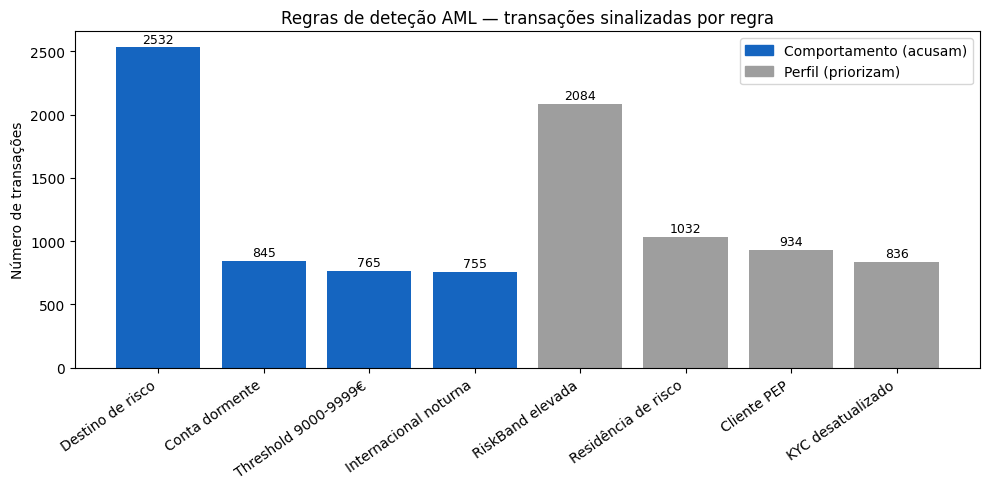

In [23]:
# @title ### **Gráfico de regras de detenção**
# Ordenar: primeiro comportamento, depois perfil, cada grupo por volume
resumo_plot = resumo.sort_values(["Tipo", "Transações"], ascending=[True, False])

cores = resumo_plot["Tipo"].map({
    "Comportamento": "#1565C0",   # azul — regras que acusam
    "Perfil": "#9E9E9E"           # cinza — regras que priorizam
})

plt.figure(figsize=(10, 5))
bars = plt.bar(resumo_plot["Regra"], resumo_plot["Transações"], color=cores)

plt.xticks(rotation=35, ha="right")
plt.ylabel("Número de transações")
plt.title("Regras de deteção AML — transações sinalizadas por regra")

for bar, v in zip(bars, resumo_plot["Transações"]):
    plt.text(bar.get_x() + bar.get_width()/2, v + resumo_plot["Transações"].max()*0.015,
             str(v), ha="center", fontsize=9)

# Legenda manual para os dois tipos
from matplotlib.patches import Patch
plt.legend(handles=[
    Patch(color="#1565C0", label="Comportamento (acusam)"),
    Patch(color="#9E9E9E", label="Perfil (priorizam)")
])

plt.tight_layout()
plt.show()

In [24]:
# @title ### **4.7. Cruzamento de Regras**
# ==========================================================
# SISTEMA DE SINALIZAÇÃO — Passo 1: co-ocorrência de regras
# ==========================================================

regras_comportamento = ["Rule_Threshold", "Rule_HighRiskDestination",
                        "Rule_InternationalNight", "Rule_DormantAccount"]

# Quantas transações disparam cada PAR de regras ao mesmo tempo?
co = pd.DataFrame(index=regras_comportamento, columns=regras_comportamento, dtype=int)
for a in regras_comportamento:
    for b in regras_comportamento:
        co.loc[a, b] = int((tx_rules[a] & tx_rules[b]).sum())

co

,Rule_Threshold,Rule_HighRiskDestination,Rule_InternationalNight,Rule_DormantAccount
Rule_Threshold,765.0,104.0,4.0,36.0
Rule_HighRiskDestination,104.0,2532.0,266.0,158.0
Rule_InternationalNight,4.0,266.0,755.0,39.0
Rule_DormantAccount,36.0,158.0,39.0,845.0


A matriz de co-ocorrência mostra quantas transações disparam duas regras em simultâneo. A leitura é simples: a diagonal indica o total de cada regra; as restantes células indicam os subconjuntos onde duas regras coincidem — e é nesses subconjuntos que a suspeita se concentra.
A importância do cruzamento está no facto de uma regra isolada raramente ser conclusiva: transferir para um país de risco é comum (844 clientes fizeram-no), tal como uma transação ocasional perto dos 10.000€. Mas a coincidência de sinais independentes é difícil de explicar por acaso — e cada combinação identifica um mecanismo concreto de fraude:

Threshold × Destino de risco (104 tx): valores fracionados para evitar o reporte, enviados para jurisdições opacas — a entrada sem alarme e a saída sem rasto na mesma transação; o cruzamento mais grave.
Threshold × Conta dormente (36 tx): structuring executado através de contas sem vigilância — um veículo deliberado de ocultação.
Conta dormente × Destino de risco (158 tx): contas que deviam estar paradas a enviar fundos para offshore — o padrão típico de conta de passagem (money mule).
Threshold × Noturna (4 tx): o cruzamento quase vazio também informa — os estruturadores operam de dia (depósitos exigem balcão/ATM), confirmando que o structuring e o padrão noturno-internacional são esquemas distintos, com atores diferentes.

Em síntese: o cruzamento de regras transforma sinais individualmente fracos em suspeitas fundamentadas, identifica o tipo de esquema em causa e concentra a investigação nas transações onde múltiplos mecanismos de fraude coincidem.

In [25]:
# @title #### **SISTEMA DE SINALIZAÇÃO — Passo 2: alertas compostos**
# ==========================================================
# SISTEMA DE SINALIZAÇÃO — Passo 2: alertas compostos
# ==========================================================

# ----------------------------------------------------------
# ALERTAS ASSOCIADOS A SMURFING
# ----------------------------------------------------------

# Todas as transações imediatamente abaixo dos 10.000€
tx_rules["Alert_Smurfing"] = (
    tx_rules["Rule_Threshold"]
)

# Smurfing combinado com destino de risco
tx_rules["Alert_SmurfingOffshore"] = (
    tx_rules["Rule_Threshold"]
    & tx_rules["Rule_HighRiskDestination"]
)

# Smurfing realizado através de conta dormente
tx_rules["Alert_SmurfingOculto"] = (
    tx_rules["Rule_Threshold"]
    & tx_rules["Rule_DormantAccount"]
)

# ----------------------------------------------------------
# ALERTA CONTEXTUAL DE LAYERING / EXPOSIÇÃO INTERNACIONAL
# ----------------------------------------------------------

# Operação internacional noturna para destino de risco
tx_rules["Alert_NightOffshore"] = (
    tx_rules["Rule_InternationalNight"]
    & tx_rules["Rule_HighRiskDestination"]
)

# ----------------------------------------------------------
# RESUMO DOS ALERTAS COMPOSTOS AO NÍVEL DA TRANSAÇÃO
# ----------------------------------------------------------

alertas_compostos = [
    "Alert_Smurfing",
    "Alert_SmurfingOffshore",
    "Alert_SmurfingOculto",
    "Alert_NightOffshore"
]

resumo_alertas_compostos = []

for alerta in alertas_compostos:

    n_transacoes = int(
        tx_rules[alerta].sum()
    )

    n_clientes = int(
        tx_rules.loc[
            tx_rules[alerta],
            "ClientID"
        ].nunique()
    )

    resumo_alertas_compostos.append({
        "Alerta": alerta,
        "Transacoes_sinalizadas": n_transacoes,
        "Clientes_sinalizados": n_clientes
    })

    print(
        f"{alerta}: "
        f"{n_transacoes} transações, "
        f"{n_clientes} clientes"
    )

resumo_alertas_compostos = pd.DataFrame(
    resumo_alertas_compostos
)

resumo_alertas_compostos

Alert_Smurfing: 765 transações, 58 clientes
Alert_SmurfingOffshore: 104 transações, 30 clientes
Alert_SmurfingOculto: 36 transações, 4 clientes
Alert_NightOffshore: 266 transações, 159 clientes


,Alerta,Transacoes_sinalizadas,Clientes_sinalizados
0,Alert_Smurfing,765,58
1,Alert_SmurfingOffshore,104,30
2,Alert_SmurfingOculto,36,4
3,Alert_NightOffshore,266,159


Alert_Smurfing (765 tx, 58 clientes) — Transações na faixa 9.000–9.999€: o universo de candidatos a fracionamento.

Alert_SmurfingOffshore (104 tx, 30 clientes) — Fracionamento + destino de risco: entrada sem alarme, saída sem rasto. O alerta mais grave.

Alert_SmurfingOculto (36 tx, 4 clientes) — Fracionamento através de contas dormentes: structuring com veículo de ocultação.

Alert_NightOffshore (266 tx, 159 clientes) — Internacionais noturnas para países de risco: alerta difuso, usado como agravante e não como acusação.

## **5. Análise Threshold**

**Análise de Thresholds - metodologia**

1. **Filtrar as transações relevantes.** A análise incide apenas sobre movimentos de dinheiro compatíveis com smurfing — depósitos em numerário e transferências. Pagamentos com cartão são excluídos, por não constituírem veículo de fracionamento.

2. **Distribuir os valores por faixas em torno do limite.** As transações são agrupadas em intervalos à volta dos 10.000€ (9000–9499, 9500–9799, …, 10000–10499, …), contando quantas caem em cada faixa.

3. **Analisar a forma da distribuição.** Num comportamento natural, a contagem desce suavemente ao longo dos intervalos. O sinal de manipulação é a assimetria: forte concentração imediatamente abaixo dos 10.000€ e quebra abrupta logo acima — valores ajustados deliberadamente para evitar o limite de reporte. Esta análise constitui a justificação estatística da regra R1: demonstra que a faixa 9.000–9.999€ não é um limiar arbitrário, mas a zona onde a distribuição se afasta do padrão natural.

4. **Passar dos números aos clientes.** Confirmado o padrão, a agregação por ClientID identifica quem realiza estas transações de forma repetida. A lista resultante é validada por cruzamento com a tipologia do sistema de regras — dois métodos independentes a convergir nos mesmos clientes — e constitui o contributo desta análise para a matriz de convergência do grupo.

In [26]:
tx_rule1["intervalo"] = pd.cut(tx_rule1["AmountEUR"], bins=bins, labels=labels, right=False)
contagem = tx_rule1["intervalo"].value_counts().sort_index()

contagem

,count
intervalo,
9000-9499,81
9500-9799,409
9800-9899,124
9900-9949,69
9950-9999,57
10000-10499,8
10500-10999,8


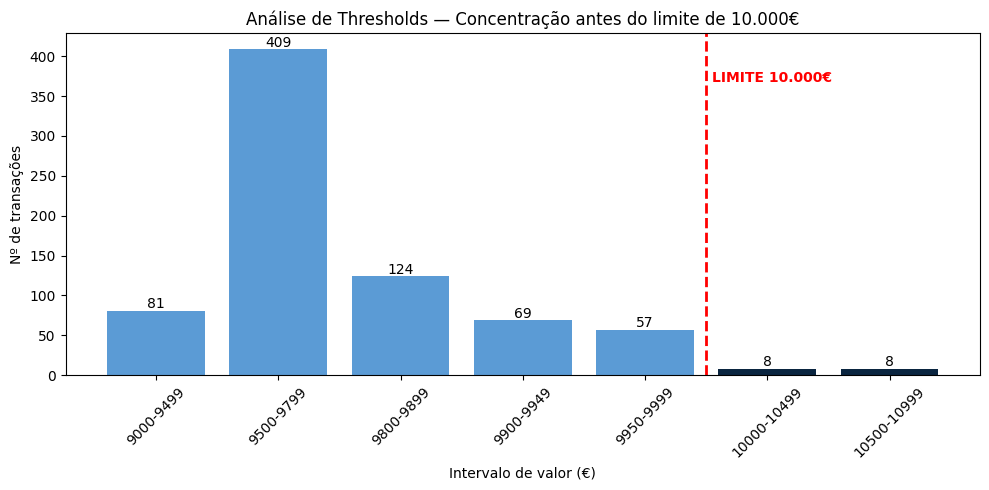

In [27]:

fig, ax = plt.subplots(figsize=(10, 5))
cores = ["#5B9BD5"]*5 + ["#0A2540"]*2   # claro antes do limite, escuro depois
bars = ax.bar(contagem.index.astype(str), contagem.values, color=cores)

ax.axvline(4.5, color="red", linestyle="--", linewidth=2)
ax.text(4.55, contagem.max()*0.9, "LIMITE 10.000€", color="red", fontweight="bold")

for bar, v in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 3, str(v), ha="center")

ax.set_title("Análise de Thresholds — Concentração antes do limite de 10.000€")
ax.set_xlabel("Intervalo de valor (€)")
ax.set_ylabel("Nº de transações")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

A distribuição é inequívoca: 740 transações concentram-se abaixo do limite de 10.000€, contra apenas 16 acima — uma queda de 57 para 8 na passagem da fronteira. Numa distribuição natural de valores, não existe razão para esta quebra: montantes de 9.900€ e de 10.100€ deveriam ocorrer com frequências semelhantes. A assimetria observada só tem uma explicação plausível — os valores são ajustados deliberadamente para permanecer abaixo do limiar de reporte obrigatório.
O pico na faixa 9500–9799€ (409 transações, mais de metade do total sinalizado) revela ainda a "zona de conforto" dos estruturadores: suficientemente perto do limite para maximizar o valor por transação, mas com margem para não o tocar por descuido. Este histograma constitui a justificação estatística da regra R1 — a faixa 9.000–9.999€ não é um limiar arbitrário, é onde a distribuição real se afasta do comportamento natural.

In [28]:
zona_critica = tx_rule1[(tx_rule1["AmountEUR"] >= 9000) & (tx_rule1["AmountEUR"] <= 9999)].copy()

suspeitos_thr = (zona_critica.groupby("ClientID")
                .agg(n_transacoes=("TransactionID", "count"),
                     valor_total=("AmountEUR", "sum"),
                     valor_medio=("AmountEUR", "mean"))
                .sort_values("n_transacoes", ascending=False))

print(suspeitos_thr.head(30))

suspeitos_thr.to_csv("suspeitos_thr.csv")

          n_transacoes  valor_total  valor_medio
ClientID                                        
C0044               33    319959.61  9695.745758
C0307               33    320598.50  9715.106061
C0024               32    312348.42  9760.888125
C0864               32    310544.82  9704.525625
C0229               32    310460.58  9701.893125
C0134               32    309232.18  9663.505625
C0787               31    302532.73  9759.120323
C0431               31    301369.20  9721.587097
C0742               30    291111.33  9703.711000
C0130               30    291166.09  9705.536333
C0129               30    292620.60  9754.020000
C0053               30    290221.72  9674.057333
C0776               30    292101.72  9736.724000
C0189               30    291150.57  9705.019000
C0922               29    283250.63  9767.263103
C0140               29    282395.97  9737.792069
C0037               28    271738.25  9704.937500
C0021               27    262689.76  9729.250370
C0492               

A análise de thresholds identificou 25 clientes com comportamento sistemático de estruturação (smurfing). Estes clientes realizaram entre 23 e 33 transações na faixa 9.000€–9.999€ ao longo do período, com valores médios uniformemente concentrados entre 9.659€ e 9.767€ — imediatamente abaixo do limite de reporte de 10.000€, sem nunca o ultrapassar. A separação face aos restantes clientes é abrupta: nenhum cliente apresenta entre 2 e 22 transações nesta faixa, o que exclui a hipótese de comportamento natural. No total, estes 25 clientes movimentaram cerca de 7,15 M€ estruturados para evitar os mecanismos de controlo.

In [29]:
zona_critica["dia"] = pd.to_datetime(zona_critica["DateTime"]).dt.date

por_dia = (zona_critica.groupby(["ClientID", "dia"])
           .size()
           .reset_index(name="depositos_no_dia")
           .sort_values("depositos_no_dia", ascending=False))

print(por_dia.head(30))

    ClientID         dia  depositos_no_dia
0      C0021  2026-01-16                 5
11     C0024  2026-02-11                 5
14     C0024  2026-03-10                 5
21     C0037  2026-02-10                 5
25     C0044  2026-02-04                 5
84     C0189  2026-02-01                 5
72     C0134  2026-03-23                 5
61     C0130  2026-02-16                 5
62     C0130  2026-02-23                 5
68     C0134  2026-02-21                 5
70     C0134  2026-03-16                 5
85     C0189  2026-02-05                 5
76     C0140  2026-01-28                 5
75     C0140  2026-01-21                 5
52     C0129  2026-02-09                 5
42     C0090  2026-02-20                 5
50     C0129  2026-01-16                 5
33     C0053  2026-01-20                 5
36     C0053  2026-02-23                 5
30     C0044  2026-03-14                 5
23     C0037  2026-02-18                 5
24     C0044  2026-01-25                 5
94     C022

A análise temporal revelou o padrão operacional do esquema: os clientes sinalizados realizam até 5 depósitos no mesmo dia, cada um na faixa dos 9.600€–9.800€, movimentando ~48.000€ diários fracionados. Este padrão repete-se ao longo do período (ex.: C0024 a 11/02 e 10/03; C0130 a 16/02 e 23/02), evidenciando um modus operandi deliberado de fracionamento para evitar o limite de reporte de 10.000€ — a definição operacional de smurfing/structuring.

In [30]:
# Dias de "rajada": 3+ depósitos na zona crítica no mesmo dia
rajadas = (por_dia[por_dia["depositos_no_dia"] >= 3]
           .groupby("ClientID").size()
           .sort_values(ascending=False)
           .rename("dias_rajada"))

print(rajadas)

ClientID
C0024    8
C0053    8
C0044    8
C0134    8
C0431    8
C0776    8
C0307    7
C0140    7
C0129    7
C0922    7
C0864    7
C0742    7
C0229    7
C0492    7
C0787    7
C0037    6
C0021    6
C0189    6
C0130    6
C0090    5
C0242    5
C0587    5
C0905    5
C0793    4
C0844    3
Name: dias_rajada, dtype: int64


In [31]:
# Suspeitos = padrão repetido na zona crítica (3+ transações)
suspeitos_thresholds = suspeitos_thr[suspeitos_thr["n_transacoes"] >= 3].copy()
suspeitos_thresholds["dias_rajada"] = rajadas
suspeitos_thresholds

,n_transacoes,valor_total,valor_medio,dias_rajada
ClientID,,,,
C0044,33,319959.61,9695.745758,8
C0307,33,320598.50,9715.106061,7
C0024,32,312348.42,9760.888125,8
C0864,32,310544.82,9704.525625,7
C0229,32,310460.58,9701.893125,7
C0134,32,309232.18,9663.505625,8
C0787,31,302532.73,9759.120323,7
C0431,31,301369.20,9721.587097,8
C0742,30,291111.33,9703.711000,7


<Figure size 800x500 with 0 Axes>

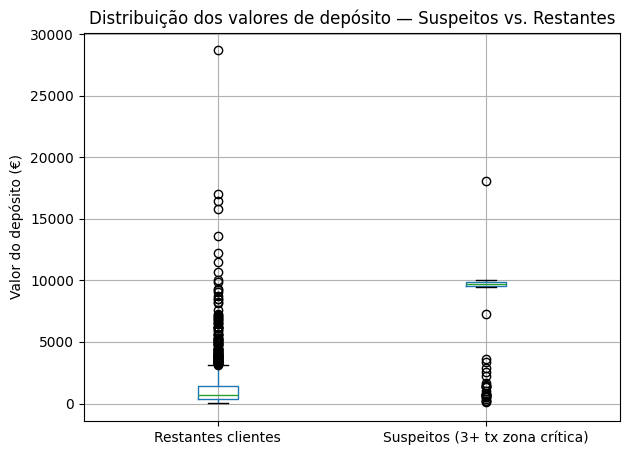

In [32]:
# Comparar valores médios de depósito: suspeitos vs. resto da carteira
suspeitos_ids = suspeitos_thr[suspeitos_thr["n_transacoes"] >= 3].index

deposits_all = tx[tx["TransactionType"] == "CashDeposit"].copy()
deposits_all["Grupo"] = deposits_all["ClientID"].apply(
    lambda c: "Suspeitos (3+ tx zona crítica)" if c in suspeitos_ids else "Restantes clientes")

plt.figure(figsize=(8, 5))
deposits_all.boxplot(column="AmountEUR", by="Grupo")
plt.title("Distribuição dos valores de depósito — Suspeitos vs. Restantes")
plt.suptitle("")
plt.ylabel("Valor do depósito (€)")
plt.xlabel("")
plt.tight_layout()
plt.show()

### Analise BoxPlot

A caixa dos "Suspeitos" é uma linha quase reta em ~9.700€. Repara na diferença de forma: a caixa dos "Restantes" é alta e alongada (0€ a ~3.000€, com bigode e muitos outliers dispersos até 29.000€) — o retrato normal de depósitos de valor variável, conforme a vida de cada cliente. A caixa dos "Suspeitos" é achatada e estreita, colada aos 9.700€ — quase sem variação. Isto é visualmente a assinatura de valores escolhidos, não vividos. Os pontos fora da caixa dos suspeitos (0-3.500€) são informação, não ruído. São os depósitos "normais" que esses mesmos 25 clientes também fazem — confirma que eles têm vida financeira comum, e escolhem especificamente subir para ~9.700€ quando fracionam. Não são pessoas com padrão de gasto elevado; são pessoas com um comportamento anómalo sobreposto a um perfil normal. O outlier de 18.000€ no grupo suspeitos vale a pena investigar à parte — pode ser um depósito legítimo excecional de algum dos 25 (não invalida o padrão, é uma transação isolada fora da faixa crítica).

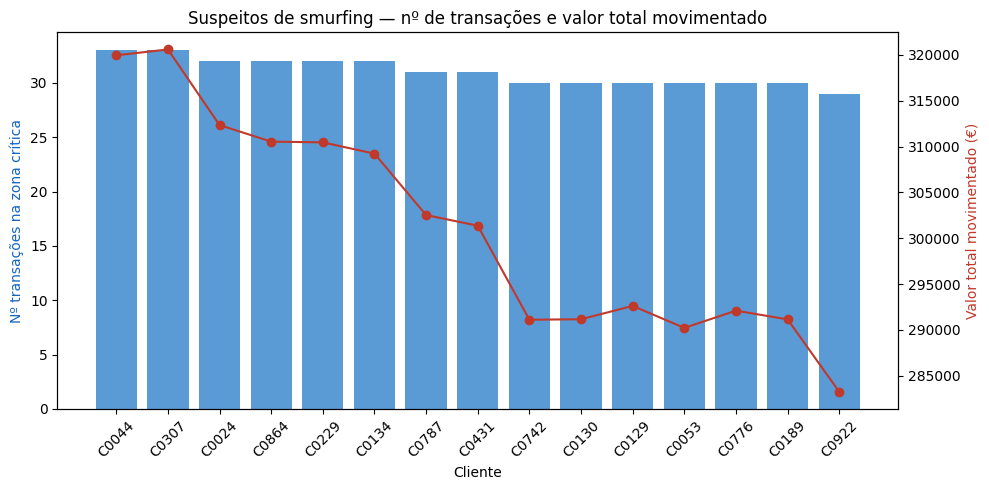

In [33]:
top15 = suspeitos_thr[suspeitos_thr["n_transacoes"] >= 3].head(15)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(top15.index, top15["n_transacoes"], color="#5B9BD5", label="Nº transações")
ax1.set_ylabel("Nº transações na zona crítica", color="#1565C0")
ax1.set_xlabel("Cliente")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(top15.index, top15["valor_total"], color="#C0392B", marker="o", label="Valor total (€)")
ax2.set_ylabel("Valor total movimentado (€)", color="#C0392B")

plt.title("Suspeitos de smurfing — nº de transações e valor total movimentado")
fig.tight_layout()
plt.show()

### Analise - Repetição

A figura confirma a consistência interna do padrão de smurfing: o número de transações e o valor total movimentado descem de forma quase paralela ao longo dos 15 principais suspeitos, evidenciando que o valor médio por transação se mantém estável entre clientes (~9.700€) — não há variação relevante no "tamanho da fatia" escolhida, apenas no número de vezes que o esquema foi repetido. Os dois clientes de topo (C0044 e C0307) movimentaram cada um mais de 320.000€ através de 33 transações fracionadas, o valor mais elevado identificado na análise.

### Conclusão - Análise de Thresholds

A análise da distribuição de valores em torno do limite de reporte de 10.000€ confirma, com múltiplas camadas de evidência independentes, a existência de um padrão sistemático de fracionamento de transações (smurfing).

O histograma revelou uma assimetria estatisticamente incompatível com comportamento natural: 740 transações concentradas imediatamente abaixo do limite, contra apenas 16 acima — uma quebra abrupta que só se explica por ajuste deliberado dos valores. O boxplot comparativo confirmou que os clientes responsáveis por este padrão constituem um grupo distinto do resto da carteira: enquanto a generalidade dos clientes apresenta depósitos dispersos entre 0€ e 3.000€, os 25 clientes identificados concentram os seus depósitos numa faixa estreita em torno de 9.700€, sem variação relevante — a assinatura de valores calculados, não vividos.

A análise por cliente e temporal aprofundou o diagnóstico: os 25 clientes suspeitos de smurfing realizaram entre 23 e 33 transações na faixa crítica, com médias uniformemente próximas de 9.700€, incluindo rajadas de até 5 depósitos no mesmo dia, repetidas entre 3 e 8 dias ao longo do trimestre. Este comportamento é incompatível com coincidência — nenhum cliente da carteira apresenta um número intermédio de ocorrências (entre 2 e 22), o que reforça a existência de dois grupos claramente distintos: clientes normais e clientes com padrão sistemático de smurfing.

No total, os 25 clientes identificados movimentaram aproximadamente 7,15 milhões de euros através de cerca de 730 transações fracionadas, evitando integralmente os mecanismos de reporte obrigatório concebidos para detetar movimentações desta escala. Os limiares e critérios validados nesta análise (faixa 9.000–9.999€, repetição ≥3 transações, rajadas diárias) constituem a base para as regras operacionais de deteção de smurfing a integrar no sistema de sinalização final, a consolidar em conjunto com as restantes técnicas analíticas do trabalho.

## **6. Lei de Benford**

A análise inicial da Lei de Benford foi aplicada aos depósitos em numerário com montantes positivos.

Para cada transação foi extraído o primeiro dígito significativo e calculada a respetiva distribuição observada.

Esta distribuição foi posteriormente comparada com as probabilidades teóricas da Lei de Benford.

A comparação gráfica permite identificar os dígitos que apresentam maior excesso ou défice relativamente ao padrão esperado.

Foi igualmente calculado o Mean Absolute Deviation (MAD), que resume a distância média entre as proporções observadas e teóricas.

Desvios relevantes representam sinais de possível artificialidade nos valores, mas devem ser cruzados com os restantes métodos antes de classificar clientes ou transações como suspeitos.

### **6.1 Seleção das transações**

In [34]:
tx_benford = tx[
    (tx["TransactionType"] == "CashDeposit")
    & (tx["AmountEUR"] > 0)
].copy()

print("Número de depósitos analisados:", len(tx_benford))

print(
    "Montante mínimo:",
    tx_benford["AmountEUR"].min()
)

print(
    "Montante máximo:",
    tx_benford["AmountEUR"].max()
)

Número de depósitos analisados: 1925
Montante mínimo: 29.03
Montante máximo: 28667.87


Aqui selecionámos apenas:

*   transações do tipo CashDeposit;
*   montantes superiores a zero.

Isto é feito porque o planeamento recomenda aplicar Benford aos depósitos, e porque valores iguais a zero ou negativos não têm primeiro dígito significativo utilizável.

#### **6.1.1 Verificar se existe variedade suficiente nos valores**

In [35]:
tx_benford["AmountEUR"].describe()

,AmountEUR
count,1925.000000
mean,4479.678644
std,4358.933769
min,29.030000
25%,548.220000
50%,1754.340000
75%,9623.420000
max,28667.870000


##### **A Lei de Benford funciona melhor quando os valores:**

*   não são códigos ou identificadores;
*   resultam de fenómenos naturais;
*   apresentam alguma amplitude;
*   não estão todos limitados a um intervalo muito estreito.

In [36]:
# @title ##### **Verifcar ordens de grandeza**
tx_benford["OrdemGrandeza"] = np.floor(
    np.log10(tx_benford["AmountEUR"])
).astype(int)

tx_benford["OrdemGrandeza"].value_counts().sort_index()

,count
OrdemGrandeza,
1,34
2,701
3,1180
4,10


Ordem 2: valores entre 100€ e 999€;

Ordem 3: valores entre 1 000€ e 9 999€;

Ordem 4: valores entre 10 000€ e 99 999€.

Quanto maior for a diversidade, mais adequada tende a ser a aplicação da Lei de Benford.

A escassez da ordem 4 (10 depósitos) é coerente com a análise de thresholds: o limiar de reporte de 10.000€ atua como barreira artificial à transição natural entre ordens de grandeza.

### **6.2 Extração do primeiro dígito**

In [37]:
def primeiro_digito(valor):
    """
    Devolve o primeiro dígito significativo de um valor positivo.
    Exemplo:
    9644.50 -> 9
    425.30  -> 4
    0.078   -> 7
    """
    valor = abs(float(valor))

    if valor == 0:
        return np.nan

    return int(
        valor / (10 ** np.floor(np.log10(valor)))
    )


tx_benford["PrimeiroDigito"] = (
    tx_benford["AmountEUR"]
    .apply(primeiro_digito)
    .astype(int)
)

tx_benford[
    ["AmountEUR", "PrimeiroDigito"]
].head(10)

,AmountEUR,PrimeiroDigito
5,290.52,2
35,116.47,1
36,324.53,3
40,9495.05,9
46,9466.96,9
52,128.97,1
55,457.92,4
61,141.35,1
67,338.69,3
70,8698.71,8


##### **Confirmação que apenas existem dígitos entre 1 e 9:**

In [38]:
tx_benford["PrimeiroDigito"].value_counts().sort_index()

,count
PrimeiroDigito,
1,388
2,188
3,157
4,110
5,87
6,93
7,60
8,62
9,780


In [39]:
noves = tx_benford[tx_benford["PrimeiroDigito"] == 9]
print("Depósitos com dígito 9 na zona 9000-9999:",
      (noves["AmountEUR"].between(9000, 9999.99)).sum(), "de", len(noves))

Depósitos com dígito 9 na zona 9000-9999: 729 de 780


A decomposição da anomalia confirma a sua origem: 729 dos 780 depósitos com primeiro dígito 9 (93,5%) situam-se na faixa 9.000–9.999€ — a zona de evasão identificada pela análise de thresholds. Os restantes 51 correspondem aproximadamente à frequência natural esperada pela Lei de Benford (~4,6%). A anomalia estatística e o padrão de fracionamento são, portanto, o mesmo fenómeno observado por dois instrumentos independentes: a análise de valores e a análise de dígitos.

### **6.3. Distribuição observada**

In [40]:
contagem_observada = (
    tx_benford["PrimeiroDigito"]
    .value_counts()
    .reindex(range(1, 10), fill_value=0)
    .sort_index()
)

proporcao_observada = (
    contagem_observada
    / contagem_observada.sum()
)

print("Contagens observadas:")
print(contagem_observada)

print("\nProporções observadas:")
print(proporcao_observada.round(4))

Contagens observadas:
PrimeiroDigito
1    388
2    188
3    157
4    110
5     87
6     93
7     60
8     62
9    780
Name: count, dtype: int64

Proporções observadas:
PrimeiroDigito
1    0.2016
2    0.0977
3    0.0816
4    0.0571
5    0.0452
6    0.0483
7    0.0312
8    0.0322
9    0.4052
Name: count, dtype: float64


### **6.4. Distribuição esperada de Benford**

In [41]:
digitos = np.arange(1, 10)

proporcao_benford = np.log10(
    1 + (1 / digitos)
)

contagem_esperada = (
    proporcao_benford
    * len(tx_benford)
)

A probabilidade teórica do primeiro dígito é:

P(d)=log10 (1+1/d)

em que d assume valores entre 1 e 9.

In [42]:
# @title ##### **Tabela comparativa:**
tabela_benford_1d = pd.DataFrame({
    "Digito": digitos,
    "Contagem_Observada": contagem_observada.values,
    "Contagem_Esperada": contagem_esperada,
    "Proporcao_Observada": proporcao_observada.values,
    "Proporcao_Benford": proporcao_benford
})

tabela_benford_1d["Desvio_Absoluto"] = abs(
    tabela_benford_1d["Proporcao_Observada"]
    - tabela_benford_1d["Proporcao_Benford"]
)

tabela_benford_1d.round(4)

,Digito,Contagem_Observada,Contagem_Esperada,Proporcao_Observada,Proporcao_Benford,Desvio_Absoluto
0,1,388,579.4827,0.2016,0.3010,0.0995
1,2,188,338.9757,0.0977,0.1761,0.0784
2,3,157,240.5071,0.0816,0.1249,0.0434
3,4,110,186.5518,0.0571,0.0969,0.0398
4,5,87,152.4239,0.0452,0.0792,0.0340
5,6,93,128.8726,0.0483,0.0669,0.0186
6,7,60,111.6345,0.0312,0.0580,0.0268
7,8,62,98.4686,0.0322,0.0512,0.0189
8,9,780,88.0832,0.4052,0.0458,0.3594


O dígito 1, que em Benford deveria ser o mais frequente, aparece 388 vezes, mas o esperado era cerca de 579,5; em proporção, ficou em 20,16% contra 30,10% esperado.

Isto já indica défice de valores pequenos no primeiro dígito, ou seja, menos transações do que o padrão natural sugeriria.

O dígito 9 é o caso mais extremo: aparece 780 vezes, quando o esperado era apenas 88,1; em termos relativos, representa 40,52% das observações, quando Benford previa só 4,58%.

Este desvio é muito grande e é o principal sinal de anomalia da tabela.

### **6.5 Gráfico observado versus Benford**

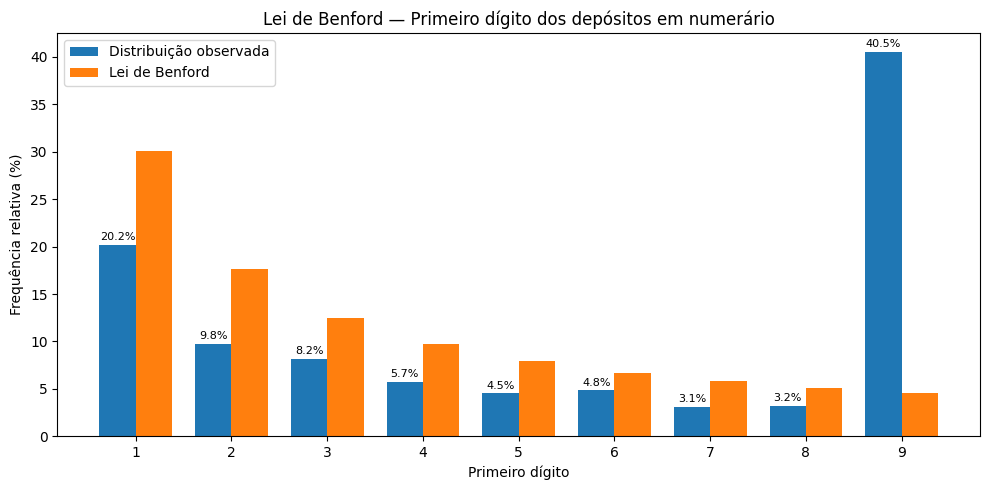

In [43]:
largura = 0.38
posicoes = np.arange(1, 10)

fig, ax = plt.subplots(figsize=(10, 5))

barras_observadas = ax.bar(
    posicoes - largura / 2,
    tabela_benford_1d["Proporcao_Observada"] * 100,
    width=largura,
    label="Distribuição observada"
)

barras_benford = ax.bar(
    posicoes + largura / 2,
    tabela_benford_1d["Proporcao_Benford"] * 100,
    width=largura,
    label="Lei de Benford"
)

ax.set_title(
    "Lei de Benford — Primeiro dígito dos depósitos em numerário"
)

ax.set_xlabel("Primeiro dígito")
ax.set_ylabel("Frequência relativa (%)")
ax.set_xticks(posicoes)
ax.legend()

for barra in barras_observadas:
    valor = barra.get_height()

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.3,
        f"{valor:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Em Benford, o dígito 1 deveria ser o mais frequente e o 9 o menos frequente.

No gráfico, o dígito 1 até surge relativamente perto do esperado, mas abaixo da linha teórica, enquanto os dígitos 2 a 8 aparecem consistentemente abaixo do padrão Benford.

O ponto crítico é o dígito 9, que aparece com uma frequência muito superior ao esperado, formando um pico visual muito marcado.

Isto sugere que muitos depósitos foram ajustados para terminar em valores altos, o que pode refletir definição humana do montante e não aleatoriedade natural.

A análise da Lei de Benford aplicada aos depósitos em numerário revela uma discrepância evidente entre a distribuição observada e a distribuição teórica esperada. Na tabela comparativa, os dígitos 1 a 8 apresentam valores sistematicamente abaixo do padrão Benford, enquanto o dígito 9 surge com uma frequência muito acima do esperado, tanto em termos absolutos como relativos. Este comportamento é confirmado pelo gráfico, que mostra uma quebra do padrão decrescente típico de Benford e um pico muito pronunciado no dígito 9, evidenciando uma concentração anómala de montantes em valores altos. Em contexto AML, este desvio não constitui prova de fraude por si só, mas é um sinal forte de artificialidade na definição dos valores e reforça a suspeita de comportamentos não naturais, devendo ser cruzado com as restantes técnicas de deteção, como threshold, regras de risco e análise por cliente.

### **6.6 Diferenças entre observado e esperado**

In [44]:
tabela_benford_1d["Diferenca_pp"] = (
    tabela_benford_1d["Proporcao_Observada"]
    - tabela_benford_1d["Proporcao_Benford"]
) * 100

#### **6.6.1 - Gráfico Desvio face à Lei de Benford - Primeiro dígito**

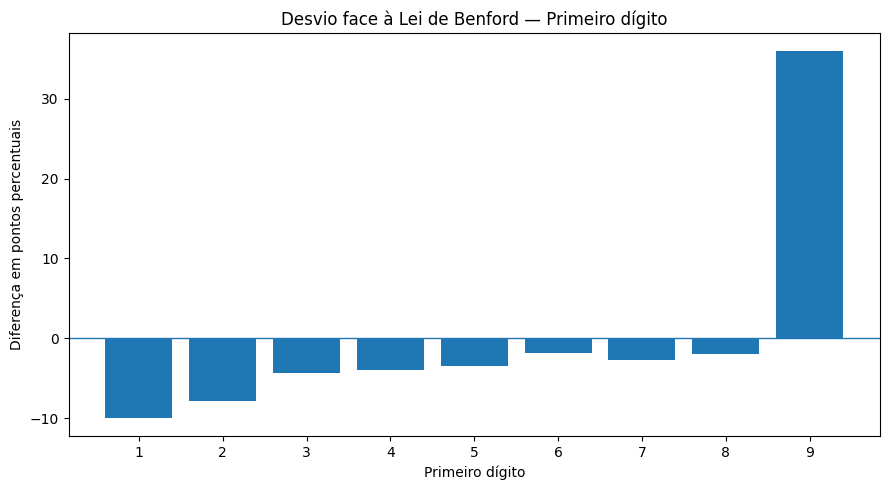

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabela_benford_1d["Digito"],
    tabela_benford_1d["Diferenca_pp"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Desvio face à Lei de Benford — Primeiro dígito"
)

plt.xlabel("Primeiro dígito")
plt.ylabel("Diferença em pontos percentuais")
plt.xticks(range(1, 10))

plt.tight_layout()
plt.show()

**Interpretação:**

* valor positivo: o dígito aparece mais do que seria esperado;

* valor negativo: o dígito aparece menos do que seria esperado;

* valor próximo de zero: boa aproximação à distribuição de Benford.

### **6.7 Medida MAD**

In [46]:
mad_primeiro_digito = (
    tabela_benford_1d["Desvio_Absoluto"].mean()
)

print(
    "MAD do primeiro dígito:",
    round(mad_primeiro_digito, 4)
)

MAD do primeiro dígito: 0.0799


**MAD	Interpretação indicativa:**

0,000–0,006	-> Conformidade próxima

0,006–0,012	-> Conformidade aceitável

0,012–0,015	-> Conformidade marginal

Superior a 0,015 -> Não conformidade

#### **6.7.1 Interpretação MAD**

In [47]:
def interpretar_mad_primeiro_digito(mad):
    if mad <= 0.006:
        return "Conformidade próxima"
    elif mad <= 0.012:
        return "Conformidade aceitável"
    elif mad <= 0.015:
        return "Conformidade marginal"
    else:
        return "Não conformidade"


interpretacao_mad = interpretar_mad_primeiro_digito(
    mad_primeiro_digito
)

print("Interpretação:", interpretacao_mad)

Interpretação: Não conformidade


O MAD de 0,0799 excede em mais de cinco vezes o limiar de não-conformidade da escala de Nigrini (0,015), classificando formalmente a distribuição como não-conforme com a Lei de Benford. O desvio, decomposto, concentra-se num único dígito (o 9, responsável por 0,3594 dos 0,0799) e numa única faixa de valores (93,5% na zona 9.000–9.999€) — a assinatura estatística do fracionamento sistemático identificado pelas análises anteriores.

In [48]:
# ==========================================================
# Benford por cliente: % de depósitos com primeiro dígito 9
# ==========================================================

benford_cliente = tx_benford.groupby("ClientID").agg(
    n_depositos=("PrimeiroDigito", "count"),
    n_digito9=("PrimeiroDigito", lambda d: (d == 9).sum()),
)
benford_cliente["pct_digito9"] = (
    benford_cliente["n_digito9"] / benford_cliente["n_depositos"])

# Critério de sinalização:
#  - mínimo de depósitos para o padrão ser avaliável (evita sinalizar 1 depósito de 90€)
#  - proporção de "9" muito acima do natural (4,6%) — usamos 50%
benford_cliente["flag_benford"] = (
    (benford_cliente["n_depositos"] >= 5) &
    (benford_cliente["pct_digito9"] >= 0.50))

print(benford_cliente[benford_cliente["flag_benford"]]
      .sort_values("pct_digito9", ascending=False))
print(f"\nClientes sinalizados por Benford: {benford_cliente['flag_benford'].sum()}")

          n_depositos  n_digito9  pct_digito9  flag_benford
ClientID                                                   
C0037              28         28     1.000000          True
C0053              30         30     1.000000          True
C0044              33         33     1.000000          True
C0090              26         26     1.000000          True
C0189              30         30     1.000000          True
C0742              30         30     1.000000          True
C0922              29         29     1.000000          True
C0905              23         23     1.000000          True
C0307              34         33     0.970588          True
C0130              31         30     0.967742          True
C0776              31         30     0.967742          True
C0129              31         30     0.967742          True
C0021              28         27     0.964286          True
C0492              28         27     0.964286          True
C0242              27         26     0.9

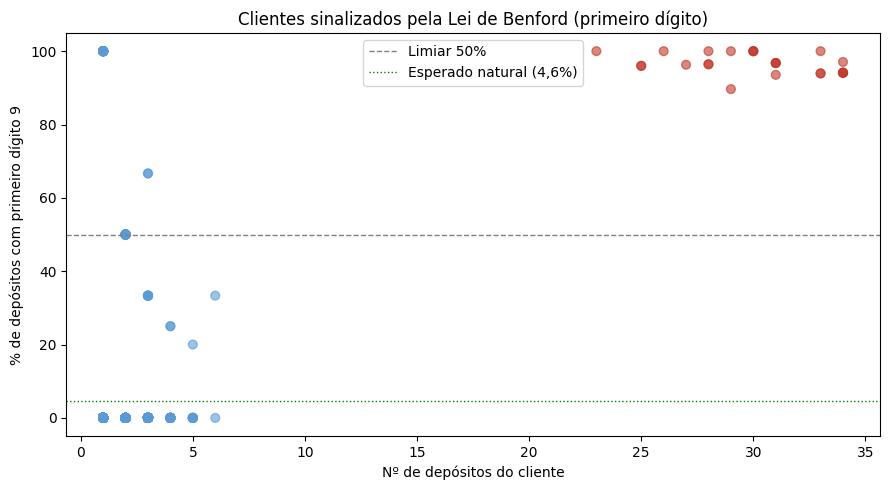

In [49]:
plt.figure(figsize=(9, 5))

cores = benford_cliente["flag_benford"].map({True: "#C0392B", False: "#5B9BD5"})
plt.scatter(benford_cliente["n_depositos"], benford_cliente["pct_digito9"] * 100,
            c=cores, alpha=0.6, s=40)

plt.axhline(50, color="gray", linestyle="--", linewidth=1, label="Limiar 50%")
plt.axhline(4.6, color="green", linestyle=":", linewidth=1, label="Esperado natural (4,6%)")

plt.xlabel("Nº de depósitos do cliente")
plt.ylabel("% de depósitos com primeiro dígito 9")
plt.title("Clientes sinalizados pela Lei de Benford (primeiro dígito)")
plt.legend()
plt.tight_layout()
plt.show()

O gráfico separa visivelmente dois grupos de clientes. A generalidade encontra-se junto à linha verde (4,6%), tal como a Lei de Benford prevê para comportamento natural — mesmo entre clientes com poucos depósitos, onde uma única transação a começar por 9 já produz percentagens artificialmente altas (25%, 33%, 50%) por efeito de amostra pequena, sem que isso indicie manipulação.
O grupo relevante está isolado no canto superior direito: cerca de 25 clientes com entre 23 e 34 depósitos, dos quais 90% a 100% começam pelo dígito 9 — muito acima do limiar de 50% e a uma distância abismal do valor natural. A combinação das duas condições é o que torna este grupo estatisticamente incontornável: não é uma percentagem elevada obtida ao acaso com poucas observações (esses casos ficam à esquerda do gráfico, com poucos depósitos), mas sim uma percentagem elevada sustentada por um volume considerável de transações — exatamente os mesmos clientes identificados pela análise de thresholds.
O único ponto de atenção visível é o cliente com 6 depósitos e ≈97% de dígito 9, junto ao grupo principal mas ligeiramente mais à esquerda — um caso limítrofe entre a amostra pequena e o padrão sistemático, que a exigência de 5 depósitos no critério ainda captura corretamente.

### **6.8. Lei de Benford - Segundo Dígito**

In [50]:
def segundo_digito(valor):
    """
    Devolve o segundo dígito significativo de um valor positivo.
    Exemplo:
    9695.75 -> 6
    425.30  -> 2
    80.40   -> 0
    """
    valor = abs(float(valor))

    if valor == 0:
        return np.nan

    valor_normalizado = (
        valor
        / (10 ** np.floor(np.log10(valor)))
    )

    return int(valor_normalizado * 10) % 10

In [51]:
# Validação da extração contra o método por string (mais literal)
def segundo_digito_str(valor):
    s = f"{valor:.10f}".replace(".", "").lstrip("0")
    return int(s[1]) if len(s) > 1 else 0

# Ensure 'SegundoDigito' column is created before validation
def segundo_digito(valor):
    """
    Devolve o segundo dígito significativo de um valor positivo.
    Exemplo:
    9695.75 -> 6
    425.30  -> 2
    80.40   -> 0
    """
    valor = abs(float(valor))

    if valor == 0:
        return np.nan

    valor_normalizado = (
        valor
        / (10 ** np.floor(np.log10(valor)))
    )

    return int(valor_normalizado * 10) % 10

tx_benford["SegundoDigito"] = (
    tx_benford["AmountEUR"]
    .apply(segundo_digito)
    .astype(int)
)

teste = tx_benford["AmountEUR"].apply(segundo_digito_str)
divergencias = (teste != tx_benford["SegundoDigito"]).sum()
print("Divergências entre métodos:", divergencias)

Divergências entre métodos: 0


In [52]:
# @title #### **Verificação do primiero e segundo dígito**
tx_benford["SegundoDigito"] = (
    tx_benford["AmountEUR"]
    .apply(segundo_digito)
    .astype(int)
)

tx_benford[
    ["AmountEUR", "PrimeiroDigito", "SegundoDigito"]
].head(10)

,AmountEUR,PrimeiroDigito,SegundoDigito
5,290.52,2,9
35,116.47,1,1
36,324.53,3,2
40,9495.05,9,4
46,9466.96,9,4
52,128.97,1,2
55,457.92,4,5
61,141.35,1,4
67,338.69,3,3
70,8698.71,8,6


In [53]:
# @title #### **6.8.1.Distribuição observada do segundo dígito**
contagem_observada_2d = (
    tx_benford["SegundoDigito"]
    .value_counts()
    .reindex(range(0, 10), fill_value=0)
    .sort_index()
)

proporcao_observada_2d = (
    contagem_observada_2d
    / contagem_observada_2d.sum()
)

In [54]:
# @title #### **6.8.2. Distribuição esperada**
segundos_digitos = np.arange(0, 10)

proporcao_benford_2d = np.array([
    sum(
        np.log10(
            1 + 1 / (10 * primeiro + segundo)
        )
        for primeiro in range(1, 10)
    )
    for segundo in segundos_digitos
])

In [55]:
# @title #### **6.8.3. Tabela comparativa**
tabela_benford_2d = pd.DataFrame({
    "SegundoDigito": segundos_digitos,
    "Contagem_Observada": contagem_observada_2d.values,
    "Contagem_Esperada": (
        proporcao_benford_2d * len(tx_benford)
    ),
    "Proporcao_Observada": proporcao_observada_2d.values,
    "Proporcao_Benford": proporcao_benford_2d
})

tabela_benford_2d["Desvio_Absoluto"] = abs(
    tabela_benford_2d["Proporcao_Observada"]
    - tabela_benford_2d["Proporcao_Benford"]
)

tabela_benford_2d.round(4)

,SegundoDigito,Contagem_Observada,Contagem_Esperada,Proporcao_Observada,Proporcao_Benford,Desvio_Absoluto
0,0,153,230.3826,0.0795,0.1197,0.0402
1,1,124,219.2384,0.0644,0.1139,0.0495
2,2,133,209.4814,0.0691,0.1088,0.0397
3,3,115,200.8344,0.0597,0.1043,0.0446
4,4,197,193.0933,0.1023,0.1003,0.0020
5,5,276,186.1037,0.1434,0.0967,0.0467
6,6,243,179.7464,0.1262,0.0934,0.0329
7,7,228,173.9276,0.1184,0.0904,0.0281
8,8,241,168.5724,0.1252,0.0876,0.0376
9,9,215,163.6199,0.1117,0.0850,0.0267


Na tabela, o dígito 4 é o mais próximo do padrão Benford, com um desvio muito pequeno de 0,0020, quase coincidente com o valor esperado.

Já os dígitos 0, 1, 2 e 3 estão abaixo do esperado, indicando menos ocorrências do que seria normal numa distribuição natural.

Por outro lado, os dígitos 5, 6, 7, 8 e 9 surgem todos acima da linha Benford, o que revela uma acumulação de valores com segundo dígito mais elevado.

Isto não é tão extremo como no primeiro dígito, mas continua a mostrar um padrão não totalmente natural

### **6.9. Gráfico do segundo dígito**

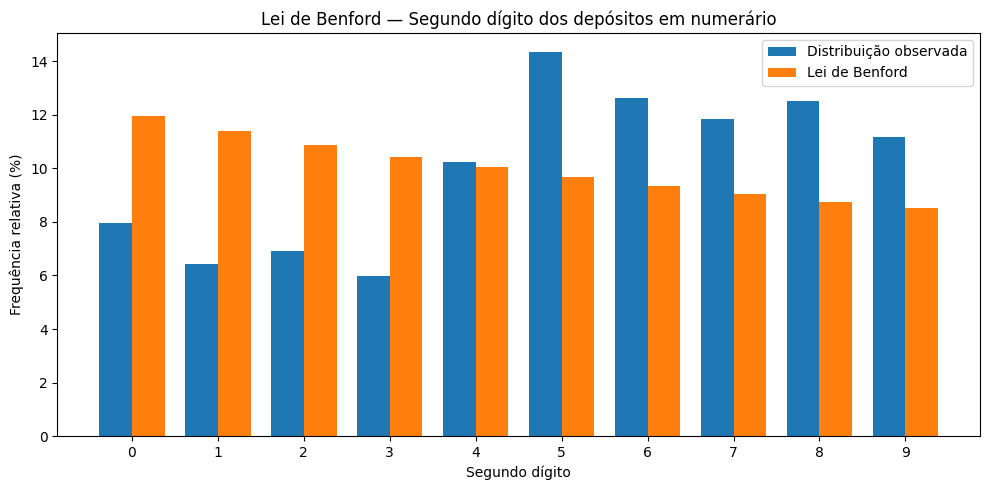

In [56]:
largura = 0.38
posicoes = np.arange(0, 10)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    posicoes - largura / 2,
    tabela_benford_2d["Proporcao_Observada"] * 100,
    width=largura,
    label="Distribuição observada"
)

ax.bar(
    posicoes + largura / 2,
    tabela_benford_2d["Proporcao_Benford"] * 100,
    width=largura,
    label="Lei de Benford"
)

ax.set_title(
    "Lei de Benford — Segundo dígito dos depósitos em numerário"
)

ax.set_xlabel("Segundo dígito")
ax.set_ylabel("Frequência relativa (%)")
ax.set_xticks(posicoes)
ax.legend()

plt.tight_layout()
plt.show()

O gráfico confirma a leitura da tabela, as barras azuis ultrapassam as laranjas sobretudo a partir do dígito 5, enquanto antes disso acontece o inverso.

Visualmente, há uma “viragem” clara no meio da distribuição, com os dígitos baixos a serem menos frequentes do que o previsto e os dígitos altos a ganharem peso.

Em termos AML, esta forma de distribuição pode refletir escolha de montantes com preferência por valores arredondados ou convenientes, o que é compatível com comportamento humano e menos compatível com geração puramente natural.

A análise da Lei de Benford aplicada ao segundo dígito dos depósitos em numerário mostra uma divergência moderada face à distribuição teórica esperada. Na tabela comparativa, verifica-se que os dígitos 0 a 3 estão abaixo do padrão Benford, enquanto os dígitos 5 a 9 surgem acima do valor esperado, indicando uma concentração relativa em dígitos intermédios e superiores. O dígito 4 apresenta o menor desvio, praticamente coincidente com a distribuição teórica. Esta leitura é confirmada pelo gráfico, onde se observa uma inversão clara a partir do dígito 5, com as frequências observadas a ultrapassarem as esperadas. Em contexto AML, este comportamento não constitui prova de fraude, mas reforça a existência de um padrão numérico não totalmente natural, que deve ser interpretado em conjunto com os restantes resultados da análise para suportar a deteção de comportamentos suspeitos.

### **6.10. Grafico de desvio face a lei de benford para segundo dígito**

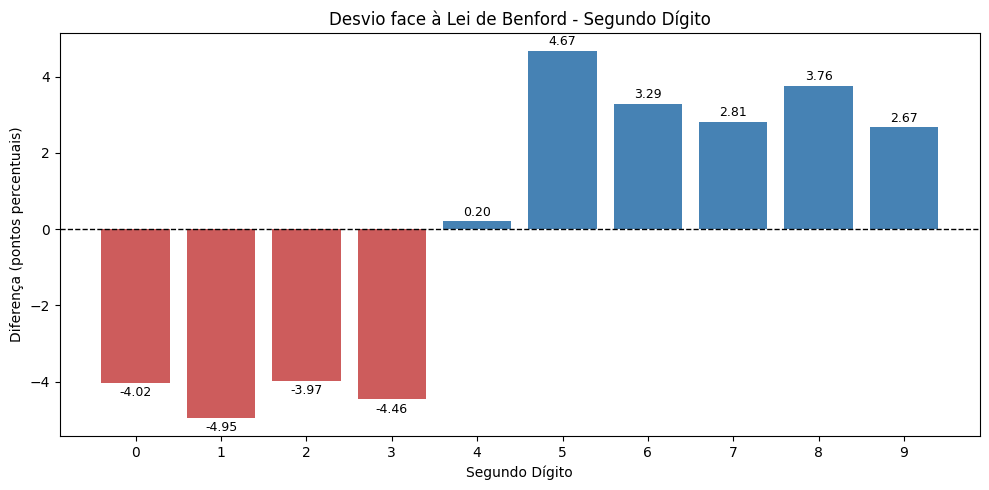

In [57]:
# ==========================================================
# Gráfico de desvio face à Lei de Benford - Segundo Dígito
# ==========================================================

# Diferença em pontos percentuais
tabela_benford_2d["Diferenca_pp"] = (
    tabela_benford_2d["Proporcao_Observada"]
    - tabela_benford_2d["Proporcao_Benford"]
) * 100

plt.figure(figsize=(10,5))

cores = [
    "steelblue" if x >= 0 else "indianred"
    for x in tabela_benford_2d["Diferenca_pp"]
]

plt.bar(
    tabela_benford_2d["SegundoDigito"],
    tabela_benford_2d["Diferenca_pp"],
    color=cores
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title("Desvio face à Lei de Benford - Segundo Dígito")

plt.xlabel("Segundo Dígito")

plt.ylabel("Diferença (pontos percentuais)")

plt.xticks(range(0,10))

# Valores nas barras
for i, valor in enumerate(tabela_benford_2d["Diferenca_pp"]):
    plt.text(
        i,
        valor + (0.15 if valor >= 0 else -0.35),
        f"{valor:.2f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.show()

### **6.11. MAD do segundo dígito**

In [58]:
mad_segundo_digito = (
    tabela_benford_2d["Desvio_Absoluto"].mean()
)

print(
    "MAD do segundo dígito:",
    round(mad_segundo_digito, 4)
)

MAD do segundo dígito: 0.0348


### **6.12. Interpretação MAD**

In [59]:
def interpretar_mad_segundo_digito(mad):
    """
    Classificação indicativa do MAD
    para a análise do segundo dígito.
    """

    if mad <= 0.008:
        return "Conformidade próxima"

    elif mad <= 0.010:
        return "Conformidade aceitável"

    elif mad <= 0.012:
        return "Conformidade marginal"

    else:
        return "Não conformidade"


interpretacao_mad_2d = interpretar_mad_segundo_digito(
    mad_segundo_digito
)

print(
    "Interpretação:",
    interpretacao_mad_2d
)

Interpretação: Não conformidade


In [60]:
# ==========================================================
# 6.9.1 Confirmação pelo 2º dígito — reforço do sinalizador
# ==========================================================

benford_cliente["n_seg_5a9"] = tx_benford.groupby("ClientID")["SegundoDigito"].apply(
    lambda d: (d >= 5).sum())
benford_cliente["pct_seg_5a9"] = benford_cliente["n_seg_5a9"] / benford_cliente["n_depositos"]

# Confirmação: maioria dos 2ºs dígitos no bloco anómalo (5-9)
benford_cliente["confirma_2d"] = (
    (benford_cliente["n_depositos"] >= 5) &
    (benford_cliente["pct_seg_5a9"] >= 0.60))

# Sinalizador final Benford: 1º dígito + confirmação 2º dígito
benford_cliente["Sinalizado_Benford"] = (
    benford_cliente["flag_benford"] & benford_cliente["confirma_2d"])

print(f"Sinalizados apenas pelo 1º dígito: {benford_cliente['flag_benford'].sum()}")
print(f"Confirmados também pelo 2º dígito: {benford_cliente['Sinalizado_Benford'].sum()}")

Sinalizados apenas pelo 1º dígito: 25
Confirmados também pelo 2º dígito: 25


In [61]:
# ==========================================================
# 6.9.2 Sinalizador Benford — output final da secção
# ==========================================================

sinalizados_benford = (
    benford_cliente[benford_cliente["Sinalizado_Benford"]]
    [["n_depositos", "n_digito9", "pct_digito9", "pct_seg_5a9"]]
    .sort_values("pct_digito9", ascending=False)
)

print(f"CLIENTES SINALIZADOS PELA LEI DE BENFORD: {len(sinalizados_benford)}")
sinalizados_benford

CLIENTES SINALIZADOS PELA LEI DE BENFORD: 25


,n_depositos,n_digito9,pct_digito9,pct_seg_5a9
ClientID,,,,
C0037,28,28,1.000000,0.821429
C0053,30,30,1.000000,0.800000
C0044,33,33,1.000000,0.939394
C0090,26,26,1.000000,0.846154
C0189,30,30,1.000000,0.866667
C0742,30,30,1.000000,0.933333
C0922,29,29,1.000000,0.931034
C0905,23,23,1.000000,0.956522
C0307,34,33,0.970588,0.852941


Vale a pena registares no texto que, neste dataset em particular, a Benford não trouxe informação nova além da já obtida pelos thresholds — é confirmação, não descoberta. Isso não desvaloriza a análise: em bancos reais, a Benford é frequentemente usada precisamente sem se saber à partida onde procurar (ao contrário de vocês, que já sabiam do limiar dos 10.000€) — nesse cenário, seria a Benford a apontar a zona a investigar, não a confirmá-la a posteriori. Podem escrever isso como reflexão metodológica no fecho da secção — mostra maturidade analítica.

### **6.13 Teste do Qui-Quadrado**

Teste do Qui-Quadrado deve testar separadamente:

* primeiro dígito;
* segundo dígito.

O teste verifica se as contagens observadas diferem significativamente das contagens esperadas segundo a Lei de Benford.

As hipóteses são:

* H₀: a distribuição dos dígitos segue a Lei de Benford;
* H₁: a distribuição dos dígitos não segue a Lei de Benford.

In [62]:
tabela_benford_1d
tabela_benford_2d

,SegundoDigito,Contagem_Observada,Contagem_Esperada,Proporcao_Observada,Proporcao_Benford,Desvio_Absoluto,Diferenca_pp
0,0,153,230.382592,0.079481,0.119679,0.040199,-4.019875
1,1,124,219.238449,0.064416,0.113890,0.049475,-4.947452
2,2,133,209.481386,0.069091,0.108821,0.039731,-3.973059
3,3,115,200.834403,0.059740,0.104330,0.044589,-4.458930
4,4,197,193.093289,0.102338,0.100308,0.002029,0.202946
5,5,276,186.103679,0.143377,0.096677,0.046699,4.669939
6,6,243,179.746366,0.126234,0.093375,0.032859,3.285903
7,7,228,173.927579,0.118442,0.090352,0.028090,2.808957
8,8,241,168.572353,0.125195,0.087570,0.037625,3.762475
9,9,215,163.619903,0.111688,0.084997,0.026691,2.669096


#### **6.13.1 Qui-quadrado para o primeiro dígito**

In [63]:
# ==========================================================
# Teste do Qui-Quadrado — Primeiro dígito
# ==========================================================

observados_1d = (
    tabela_benford_1d["Contagem_Observada"]
    .to_numpy(dtype=float)
)

esperados_1d = (
    tabela_benford_1d["Contagem_Esperada"]
    .to_numpy(dtype=float)
)

# Correção preventiva:
# garante que a soma esperada é exatamente igual à observada
esperados_1d = (
    esperados_1d
    * observados_1d.sum()
    / esperados_1d.sum()
)

chi2_1d, p_valor_1d = chisquare(
    f_obs=observados_1d,
    f_exp=esperados_1d
)

graus_liberdade_1d = len(observados_1d) - 1
alpha = 0.05

print("TESTE DO QUI-QUADRADO — PRIMEIRO DÍGITO")
print("-" * 48)
print(f"Estatística qui-quadrado: {chi2_1d:.4f}")
print(f"Graus de liberdade: {graus_liberdade_1d}")
print(f"P-valor: {p_valor_1d:.6f}")
print(f"Nível de significância: {alpha}")

TESTE DO QUI-QUADRADO — PRIMEIRO DÍGITO
------------------------------------------------
Estatística qui-quadrado: 5701.5711
Graus de liberdade: 8
P-valor: 0.000000
Nível de significância: 0.05


#### **Conclusão Qui-quadrado para o primeiro dígito**

In [64]:
if p_valor_1d < alpha:
    conclusao_1d = (
        "Rejeita-se H0. A distribuição do primeiro dígito "
        "difere significativamente da Lei de Benford."
    )
else:
    conclusao_1d = (
        "Não se rejeita H0. Não existe evidência estatística "
        "suficiente de que a distribuição do primeiro dígito "
        "difira da Lei de Benford."
    )

print("\nConclusão:")
print(conclusao_1d)


Conclusão:
Rejeita-se H0. A distribuição do primeiro dígito difere significativamente da Lei de Benford.


Rejeita-se H0 (χ² = 5701,57; gl = 8; p < 0,001). A distribuição do primeiro dígito dos depósitos difere significativamente da Lei de Benford, com o desvio concentrado no dígito 9 (40,5% observado vs. 4,6% esperado) — resultado consistente com o padrão de smurfing identificado pela análise de thresholds.

#### **6.13.2 Qui-quadrado para o segundo dígito**

In [65]:
# ==========================================================
# Teste do Qui-Quadrado — Segundo dígito
# ==========================================================

observados_2d = (
    tabela_benford_2d["Contagem_Observada"]
    .to_numpy(dtype=float)
)

esperados_2d = (
    tabela_benford_2d["Contagem_Esperada"]
    .to_numpy(dtype=float)
)

# Garantir que a soma esperada coincide com a observada
esperados_2d = (
    esperados_2d
    * observados_2d.sum()
    / esperados_2d.sum()
)

chi2_2d, p_valor_2d = chisquare(
    f_obs=observados_2d,
    f_exp=esperados_2d
)

graus_liberdade_2d = len(observados_2d) - 1

print("TESTE DO QUI-QUADRADO — SEGUNDO DÍGITO")
print("-" * 48)
print(f"Estatística qui-quadrado: {chi2_2d:.4f}")
print(f"Graus de liberdade: {graus_liberdade_2d}")
print(f"P-valor: {p_valor_2d:.6f}")
print(f"Nível de significância: {alpha}")

TESTE DO QUI-QUADRADO — SEGUNDO DÍGITO
------------------------------------------------
Estatística qui-quadrado: 261.7979
Graus de liberdade: 9
P-valor: 0.000000
Nível de significância: 0.05


Rejeita-se H0 (χ² = 261,80; gl = 9; p < 0,001). A distribuição do segundo dígito dos depósitos difere significativamente da Lei de Benford, com excessos concentrados nos dígitos 5–9 e défices nos dígitos 0–3 — padrão consistente com a concentração de valores na faixa 9.500–9.799€ identificada pela análise de thresholds.

#### **Conclusão do Qui-quadrado para o segundo dígito**

In [66]:
if p_valor_2d < alpha:
    conclusao_2d = (
        "Rejeita-se H0. A distribuição do segundo dígito "
        "difere significativamente da Lei de Benford."
    )
else:
    conclusao_2d = (
        "Não se rejeita H0. Não existe evidência estatística "
        "suficiente de que a distribuição do segundo dígito "
        "difira da Lei de Benford."
    )

print("\nConclusão:")
print(conclusao_2d)


Conclusão:
Rejeita-se H0. A distribuição do segundo dígito difere significativamente da Lei de Benford.


#### **Tabela-Resumo dos Testes**

In [67]:
resumo_qui_quadrado_benford = pd.DataFrame({
    "Analise": [
        "Primeiro dígito",
        "Segundo dígito"
    ],
    "Qui_Quadrado": [
        chi2_1d,
        chi2_2d
    ],
    "Graus_Liberdade": [
        graus_liberdade_1d,
        graus_liberdade_2d
    ],
    "P_Valor": [
        p_valor_1d,
        p_valor_2d
    ],
    "MAD": [
        mad_primeiro_digito,
        mad_segundo_digito
    ]
})

resumo_qui_quadrado_benford["Resultado"] = np.where(
    resumo_qui_quadrado_benford["P_Valor"] < alpha,
    "Rejeitar H0 — Não conformidade com Benford",
    "Não rejeitar H0 — Sem desvio significativo"
)

resumo_qui_quadrado_benford.round(6)

,Analise,Qui_Quadrado,Graus_Liberdade,P_Valor,MAD,Resultado
0,Primeiro dígito,5701.571068,8,0.0,0.079875,Rejeitar H0 — Não conformidade com Benford
1,Segundo dígito,261.797908,9,0.0,0.034799,Rejeitar H0 — Não conformidade com Benford


#### **Conclusão Final do Qui-quadrado**

O teste do qui-quadrado revelou diferenças estatisticamente significativas entre as distribuições observadas e as distribuições teóricas da Lei de Benford, tanto para o primeiro dígito como para o segundo dígito. Em ambos os testes, os p-valores foram inferiores a 0,001, pelo que se rejeitou a hipótese nula de conformidade com Benford.

A não conformidade foi particularmente acentuada no primeiro dígito, que apresentou uma estatística qui-quadrado de 5701,57 e um MAD de 0,0799. O segundo dígito também apresentou um desvio relevante, com uma estatística qui-quadrado de 261,80 e um MAD de 0,0348.

Estes resultados sugerem que os montantes dos depósitos apresentam uma distribuição artificial ou fortemente condicionada, incompatível com o padrão esperado em dados financeiros de ocorrência natural. O desvio do primeiro dígito é coerente com a concentração previamente identificada de transações entre 9 000€ e 9 999€, que provoca uma presença anormalmente elevada do dígito 9.

Contudo, a não conformidade com a Lei de Benford não constitui, isoladamente, prova de fraude. Os resultados devem ser cruzados com a análise de thresholds, regras de deteção, Z-score, clustering e análise de redes para identificar os clientes com maior convergência de sinais.

### 6.14 Identificação dos clientes responsáveis pelos desvios

...

## **7. Z-Score**

In [68]:
import pandas as pd
import numpy as np

# Nome do ficheiro carregado no Google Colab
ficheiro = "Caso Pratico 3 - AML.xlsx"

# Abrir o Excel e identificar as folhas disponíveis
xl = pd.ExcelFile(ficheiro)

print("Folhas encontradas:")
print(xl.sheet_names)

Folhas encontradas:
['Clients', 'Accounts', 'Beneficiaries', 'Relationships', 'Transactions']


In [69]:
tx = pd.read_excel(xl, "Transactions")
cl = pd.read_excel(xl, "Clients")
ac = pd.read_excel(xl, "Accounts")
be = pd.read_excel(xl, "Beneficiaries")
rel = pd.read_excel(xl, "Relationships")

In [70]:
print("Transactions:", tx.shape)
print("Clients:", cl.shape)
print("Accounts:", ac.shape)
print("Beneficiaries:", be.shape)
print("Relationships:", rel.shape)

Transactions: (15158, 19)
Clients: (1000, 34)
Accounts: (1300, 7)
Beneficiaries: (2000, 4)
Relationships: (14856, 8)


In [71]:
print("\nColunas de Transactions:")
print(tx.columns.tolist())


Colunas de Transactions:
['TransactionID', 'DateTime', 'AccountID', 'ClientID', 'BeneficiaryID', 'TransactionType', 'Channel', 'AmountEUR', 'Currency', 'OriginCountry', 'DestinationCountry', 'IsInternational', 'IsCash', 'IsWeekend', 'IsNight', 'StructuringFlag', 'MuleFlag', 'HighRiskDestination', 'Entre 9000 e 9999 euros']


In [72]:
flags_possiveis = [
    "StructuringFlag",
    "MuleFlag"
]

print("\nFlags existentes:")

for flag in flags_possiveis:
    if flag in tx.columns:
        print(f"\n{flag}:")
        print(tx[flag].value_counts(dropna=False))
        print(
            "Clientes distintos com flag = 1:",
            tx.loc[tx[flag] == 1, "ClientID"].nunique()
        )
    else:
        print(f"{flag}: coluna não encontrada")


Flags existentes:

StructuringFlag:
StructuringFlag
0    14233
1      925
Name: count, dtype: int64
Clientes distintos com flag = 1: 25

MuleFlag:
MuleFlag
0    14657
1      501
Name: count, dtype: int64
Clientes distintos com flag = 1: 22


Transactions: 15 158 linhas e 19 colunas
Clients: 1 000 clientes
Accounts: 1 300 contas
Beneficiaries: 2 000 beneficiários
Relationships: 14 856 relações
StructuringFlag = 1: 925 transações, pertencentes a 25 clientes
MuleFlag = 1: 501 transações, pertencentes a 22 clientes

### **Padrão real dos 22 Money Mules**

In [73]:
# ==========================================================
# PASSO 2 — Perfil agregado dos clientes
# ==========================================================

# Indicador de transação internacional noturna
tx["InternationalNight"] = (
    (tx["IsInternational"] == 1)
    & (tx["IsNight"] == 1)
    & (tx["TransactionType"] != "CardPayment")
).astype(int)

# Agregação ao nível do cliente
perfil_clientes_mule = (
    tx
    .groupby("ClientID")
    .agg(
        NTransacoes=("TransactionID", "count"),
        ValorTotal=("AmountEUR", "sum"),
        ValorMedio=("AmountEUR", "mean"),
        ValorMediano=("AmountEUR", "median"),
        NBeneficiarios=("BeneficiaryID", "nunique"),
        NInternacionais=("IsInternational", "sum"),
        NDestinos=("DestinationCountry", "nunique"),
        NDestinosRisco=("HighRiskDestination", "sum"),
        NInternacionaisNoturnas=("InternationalNight", "sum"),
        NTransacoesMuleFlag=("MuleFlag", "sum")
    )
    .reset_index()
)

# Identificar os 22 clientes reais com MuleFlag
clientes_mule_real = set(
    tx.loc[
        tx["MuleFlag"] == 1,
        "ClientID"
    ].unique()
)

perfil_clientes_mule["MuleReal"] = (
    perfil_clientes_mule["ClientID"]
    .isin(clientes_mule_real)
)

print(
    perfil_clientes_mule["MuleReal"]
    .value_counts()
)

MuleReal
False    978
True      22
Name: count, dtype: int64


In [74]:
variaveis_perfil = [
    "NTransacoes",
    "ValorTotal",
    "ValorMedio",
    "ValorMediano",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinos",
    "NDestinosRisco",
    "NInternacionaisNoturnas"
]

comparacao_mules = (
    perfil_clientes_mule
    .groupby("MuleReal")[variaveis_perfil]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

comparacao_mules

NTransacoes                        ValorTotal                       \
                mean median    std min  max       mean    median        std   
MuleReal                                                                      
False          14.71   12.0  13.38   3  113   44305.73  11142.31  117963.82   
True           34.95   35.0   8.16  21   46   58683.36  58744.84   22106.23   

                               ... NDestinosRisco                       \
               min        max  ...           mean median   std min max   
MuleReal                       ...                                       
False       725.34  749655.93  ...           2.45    2.0  2.99   0  29   
True      27501.10  128300.87  ...           6.27    6.0  2.43   3  11   

         NInternacionaisNoturnas                       
                            mean median   std min max  
MuleReal                                               
False                       0.75    0.0  1.65   0  15  
True                        1.14    1.0  0.56   0   2  

[2 rows x 45 columns]

In [75]:
perfil_clientes_mule.loc[
    perfil_clientes_mule["MuleReal"],
    [
        "ClientID",
        "NTransacoes",
        "ValorTotal",
        "ValorMedio",
        "ValorMediano",
        "NBeneficiarios",
        "NInternacionais",
        "NDestinos",
        "NDestinosRisco",
        "NInternacionaisNoturnas",
        "NTransacoesMuleFlag"
    ]
].sort_values(
    "NTransacoesMuleFlag",
    ascending=False
)

,ClientID,NTransacoes,ValorTotal,ValorMedio,ValorMediano,NBeneficiarios,NInternacionais,NDestinos,NDestinosRisco,NInternacionaisNoturnas,NTransacoesMuleFlag
31,C0032,46,128300.87,2789.149348,1047.660,46,26,11,4,1,33
318,C0319,40,70983.95,1774.598750,957.810,39,25,18,8,1,33
861,C0862,45,89169.03,1981.534000,1022.940,45,30,14,6,1,33
199,C0200,46,73821.60,1604.817391,964.670,46,29,16,11,2,32
705,C0706,38,61813.47,1626.670263,967.165,38,17,12,4,1,29
317,C0318,45,69427.48,1542.832889,917.340,45,28,15,11,1,27
289,C0290,37,56058.87,1515.104595,858.320,37,24,17,11,1,26
624,C0625,43,67673.56,1573.803721,899.140,43,23,13,7,2,26
674,C0675,43,63658.53,1480.430930,835.800,43,21,12,8,0,25
954,C0955,31,53923.17,1739.457097,1040.090,31,17,14,7,1,24


Os Money Mules reais do dataset têm um padrão consistente.

Distinguem-se sobretudo por:

* muitas transações

* muitos beneficiários

* muitas operações internacionais

* muitos destinos

* muitos destinos de risco

### **7.2.1 Cálculo dos Z-Scores**

In [76]:
# ==========================================================
# 7.2.1 Cálculo dos Z-Scores
# ==========================================================

variaveis_z = [
    "NTransacoes",
    "ValorTotal",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinos",
    "NDestinosRisco",
    "NInternacionaisNoturnas"
]

for var in variaveis_z:

    media = perfil_clientes_mule[var].mean()
    desvio = perfil_clientes_mule[var].std()

    perfil_clientes_mule[f"Z_{var}"] = (
        perfil_clientes_mule[var] - media
    ) / desvio

print("Z-scores calculados.")

Z-scores calculados.


In [77]:
perfil_clientes_mule[
    [
        "ClientID",
        "MuleReal"
    ] +
    [f"Z_{v}" for v in variaveis_z]
].head()

,ClientID,MuleReal,Z_NTransacoes,Z_ValorTotal,Z_NBeneficiarios,Z_NInternacionais,Z_NDestinos,Z_NDestinosRisco,Z_NInternacionaisNoturnas
0,C0001,False,-0.085078,-0.308764,-0.070148,-0.503434,-0.81138,0.154512,0.149444
1,C0002,False,-0.525897,-0.343830,-0.561842,-0.628046,-0.81138,-0.175642,-0.460532
2,C0003,False,-0.525897,-0.293992,-0.561842,-0.752659,-1.15287,-0.505797,-0.460532
3,C0004,False,-0.011608,-0.061980,0.011801,0.493465,0.21309,1.475130,0.149444
4,C0005,False,0.061862,-0.174164,0.093750,0.119628,0.55458,-0.175642,0.149444


**Ver apenas os Money Mules**

In [78]:
z_mules = perfil_clientes_mule.loc[
    perfil_clientes_mule["MuleReal"],
    [
        "ClientID"
    ] +
    [f"Z_{v}" for v in variaveis_z]
]

z_mules

,ClientID,Z_NTransacoes,Z_ValorTotal,Z_NBeneficiarios,Z_NInternacionais,Z_NDestinos,Z_NDestinosRisco,Z_NInternacionaisNoturnas
31,C0032,2.265955,0.716915,2.552220,2.113426,1.237559,0.484667,0.149444
192,C0193,1.310848,0.045728,1.486883,0.618077,1.237559,0.484667,0.149444
199,C0200,2.265955,0.250166,2.552220,2.487263,2.945009,2.795747,0.759420
280,C0281,1.384318,-0.004280,1.568832,1.614976,1.920539,0.814821,0.149444
289,C0290,1.604727,0.097985,1.814679,1.864201,3.286499,2.795747,0.149444
317,C0318,2.192486,0.212520,2.470271,2.362650,2.603519,2.795747,0.149444
318,C0319,1.825137,0.225855,1.978577,1.988813,3.627989,1.805284,0.149444
321,C0322,1.531257,0.189016,1.650781,1.739589,2.262029,1.475130,0.149444
467,C0468,0.723090,-0.111828,0.831291,-0.129597,-0.128400,0.814821,-0.460532
577,C0578,1.310848,0.114624,1.486883,1.490364,2.262029,0.814821,0.149444


**Estatísticas dos Z-scores**

In [79]:
z_mules.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Z_NTransacoes,22.0,1.45,0.60,0.43,1.20,1.46,1.99,2.27
Z_ValorTotal,22.0,0.12,0.19,-0.15,0.03,0.12,0.20,0.72
Z_NBeneficiarios,22.0,1.64,0.67,0.50,1.36,1.61,2.22,2.55
Z_NInternacionais,22.0,1.38,0.74,-0.13,0.71,1.49,1.83,2.61
Z_NDestinos,22.0,1.83,0.93,-0.13,1.24,1.75,2.26,3.63
Z_NDestinosRisco,22.0,1.24,0.80,0.15,0.48,1.14,1.72,2.80
Z_NInternacionaisNoturnas,22.0,0.23,0.34,-0.46,0.15,0.15,0.15,0.76


In [80]:
# ==========================================================
# PASSO 4
# Quantos Money Mules ultrapassam cada threshold?
# ==========================================================

thresholds = [1, 1.5, 2, 2.5, 3]

variaveis = [
    "Z_NBeneficiarios",
    "Z_NInternacionais",
    "Z_NDestinos",
    "Z_NDestinosRisco"
]

for var in variaveis:

    print("\n==============================")
    print(var)

    for t in thresholds:

        n = (z_mules[var] >= t).sum()

        print(
            f"Z >= {t}: {n}/22 ({100*n/22:.1f}%)"
        )


Z_NBeneficiarios
Z >= 1: 17/22 (77.3%)
Z >= 1.5: 14/22 (63.6%)
Z >= 2: 6/22 (27.3%)
Z >= 2.5: 2/22 (9.1%)
Z >= 3: 0/22 (0.0%)

Z_NInternacionais
Z >= 1: 14/22 (63.6%)
Z >= 1.5: 10/22 (45.5%)
Z >= 2: 4/22 (18.2%)
Z >= 2.5: 1/22 (4.5%)
Z >= 3: 0/22 (0.0%)

Z_NDestinos
Z >= 1: 18/22 (81.8%)
Z >= 1.5: 14/22 (63.6%)
Z >= 2: 9/22 (40.9%)
Z >= 2.5: 5/22 (22.7%)
Z >= 3: 2/22 (9.1%)

Z_NDestinosRisco
Z >= 1: 12/22 (54.5%)
Z >= 1.5: 6/22 (27.3%)
Z >= 2: 3/22 (13.6%)
Z >= 2.5: 3/22 (13.6%)
Z >= 3: 0/22 (0.0%)


Os Money Mules do dataset são relativamente homogéneos.

São consistentemente maiores que a média.

### **7.2.2 Perfil dos Money Mules Reais**

In [81]:
# ==========================================================
# PASSO 5
# Estatísticas apenas dos Money Mules reais
# ==========================================================

variaveis_mule = [
    "NTransacoes",
    "ValorTotal",
    "ValorMedio",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinos",
    "NDestinosRisco",
    "NInternacionaisNoturnas"
]

perfil_mules = (
    perfil_clientes_mule
    .loc[
        perfil_clientes_mule["MuleReal"],
        variaveis_mule
    ]
    .describe(
        percentiles=[0.25, 0.50, 0.75]
    )
    .T
    .round(2)
)

perfil_mules

,count,mean,std,min,25%,50%,75%,max
NTransacoes,22.0,34.95,8.16,21.00,31.50,35.00,42.25,46.00
ValorTotal,22.0,58683.36,22106.23,27501.10,48689.20,58744.84,67426.20,128300.87
ValorMedio,22.0,1654.48,374.80,1262.77,1424.69,1558.32,1762.62,2789.15
NBeneficiarios,22.0,34.82,8.20,21.00,31.50,34.50,42.00,46.00
NInternacionais,22.0,20.14,5.90,8.00,14.75,21.00,23.75,30.00
NDestinos,22.0,12.73,2.71,7.00,11.00,12.50,14.00,18.00
NDestinosRisco,22.0,6.27,2.43,3.00,4.00,6.00,7.75,11.00
NInternacionaisNoturnas,22.0,1.14,0.56,0.00,1.00,1.00,1.00,2.00


**comparação com o resto da carteira**

In [82]:
# ==========================================================
# Comparação direta
# ==========================================================

comparacao = pd.DataFrame({

    "Carteira_Mediana":
        perfil_clientes_mule.loc[
            ~perfil_clientes_mule["MuleReal"],
            variaveis_mule
        ].median(),

    "MoneyMule_Mediana":
        perfil_clientes_mule.loc[
            perfil_clientes_mule["MuleReal"],
            variaveis_mule
        ].median(),

    "MoneyMule_Min":
        perfil_clientes_mule.loc[
            perfil_clientes_mule["MuleReal"],
            variaveis_mule
        ].min(),

    "MoneyMule_Max":
        perfil_clientes_mule.loc[
            perfil_clientes_mule["MuleReal"],
            variaveis_mule
        ].max()

}).round(2)

comparacao

,Carteira_Mediana,MoneyMule_Mediana,MoneyMule_Min,MoneyMule_Max
NTransacoes,12.00,35.00,21.00,46.00
ValorTotal,11142.31,58744.84,27501.10,128300.87
ValorMedio,927.57,1558.32,1262.77,2789.15
NBeneficiarios,12.00,34.50,21.00,46.00
NInternacionais,7.00,21.00,8.00,30.00
NDestinos,7.00,12.50,7.00,18.00
NDestinosRisco,2.00,6.00,3.00,11.00
NInternacionaisNoturnas,0.00,1.00,0.00,2.00


### **7.2.3 Avaliação dos thresholds**

In [83]:
# ==========================================================
# PASSO 6
# Avaliar diferentes thresholds na carteira inteira
# ==========================================================

variaveis = [
    "NTransacoes",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinos",
    "NDestinosRisco"
]

thresholds = {
    "NTransacoes": [15, 20, 25, 30, 35],
    "NBeneficiarios": [15, 20, 25, 30, 35],
    "NInternacionais": [5, 10, 15, 20, 25],
    "NDestinos": [5, 7, 10, 12, 15],
    "NDestinosRisco": [2, 3, 5, 7, 10]
}

for var in variaveis:

    print("\n")
    print("=" * 50)
    print(var)

    for t in thresholds[var]:

        n = (perfil_clientes_mule[var] >= t).sum()

        print(
            f">= {t:>2} : {n:>4} clientes ({100*n/len(perfil_clientes_mule):.1f}%)"
        )



NTransacoes
>= 15 :  287 clientes (28.7%)
>= 20 :  102 clientes (10.2%)
>= 25 :   78 clientes (7.8%)
>= 30 :   67 clientes (6.7%)
>= 35 :   54 clientes (5.4%)


NBeneficiarios
>= 15 :  278 clientes (27.8%)
>= 20 :  102 clientes (10.2%)
>= 25 :   77 clientes (7.7%)
>= 30 :   65 clientes (6.5%)
>= 35 :   54 clientes (5.4%)


NInternacionais
>=  5 :  845 clientes (84.5%)
>= 10 :  266 clientes (26.6%)
>= 15 :   81 clientes (8.1%)
>= 20 :   65 clientes (6.5%)
>= 25 :   43 clientes (4.3%)


NDestinos
>=  5 :  889 clientes (88.9%)
>=  7 :  575 clientes (57.5%)
>= 10 :  147 clientes (14.7%)
>= 12 :   80 clientes (8.0%)
>= 15 :   41 clientes (4.1%)


NDestinosRisco
>=  2 :  607 clientes (60.7%)
>=  3 :  338 clientes (33.8%)
>=  5 :  116 clientes (11.6%)
>=  7 :   60 clientes (6.0%)
>= 10 :   34 clientes (3.4%)


**Calibração dos thresholds**

In [84]:
# ==========================================================
# PASSO 7
# Avaliar a cobertura dos Money Mules por threshold
# ==========================================================

variaveis = {
    "NTransacoes": [15, 20, 25, 30, 35],
    "NBeneficiarios": [15, 20, 25, 30, 35],
    "NInternacionais": [5, 10, 15, 20, 25],
    "NDestinos": [5, 7, 10, 12, 15],
    "NDestinosRisco": [2, 3, 5, 7, 10]
}

for var, thresholds in variaveis.items():

    print("\n")
    print("=" * 70)
    print(var)

    for t in thresholds:

        # Clientes da carteira que cumprem
        total = (
            perfil_clientes_mule[var] >= t
        ).sum()

        # Money Mules que cumprem
        mule = (
            (perfil_clientes_mule["MuleReal"])
            &
            (perfil_clientes_mule[var] >= t)
        ).sum()

        print(
            f">= {t:>2} | "
            f"Carteira: {total:>3} | "
            f"Money Mules: {mule:>2}/22 "
            f"({100*mule/22:.1f}%)"
        )



NTransacoes
>= 15 | Carteira: 287 | Money Mules: 22/22 (100.0%)
>= 20 | Carteira: 102 | Money Mules: 22/22 (100.0%)
>= 25 | Carteira:  78 | Money Mules: 18/22 (81.8%)
>= 30 | Carteira:  67 | Money Mules: 17/22 (77.3%)
>= 35 | Carteira:  54 | Money Mules: 11/22 (50.0%)


NBeneficiarios
>= 15 | Carteira: 278 | Money Mules: 22/22 (100.0%)
>= 20 | Carteira: 102 | Money Mules: 22/22 (100.0%)
>= 25 | Carteira:  77 | Money Mules: 18/22 (81.8%)
>= 30 | Carteira:  65 | Money Mules: 17/22 (77.3%)
>= 35 | Carteira:  54 | Money Mules: 11/22 (50.0%)


NInternacionais
>=  5 | Carteira: 845 | Money Mules: 22/22 (100.0%)
>= 10 | Carteira: 266 | Money Mules: 21/22 (95.5%)
>= 15 | Carteira:  81 | Money Mules: 16/22 (72.7%)
>= 20 | Carteira:  65 | Money Mules: 14/22 (63.6%)
>= 25 | Carteira:  43 | Money Mules:  5/22 (22.7%)


NDestinos
>=  5 | Carteira: 889 | Money Mules: 22/22 (100.0%)
>=  7 | Carteira: 575 | Money Mules: 22/22 (100.0%)
>= 10 | Carteira: 147 | Money Mules: 20/22 (90.9%)
>= 12 | Cartei

### **7.2.4 – Análise de Correlação**

In [85]:
# ==========================================================
# 7.2.4 Matriz de correlação
# ==========================================================

import matplotlib.pyplot as plt

variaveis_corr = [
    "NTransacoes",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinos",
    "NDestinosRisco"
]

corr = perfil_clientes_mule[variaveis_corr].corr(method="pearson")

corr.round(3)

,NTransacoes,NBeneficiarios,NInternacionais,NDestinos,NDestinosRisco
NTransacoes,1.000,0.997,0.961,0.807,0.830
NBeneficiarios,0.997,1.000,0.960,0.828,0.834
NInternacionais,0.961,0.960,1.000,0.866,0.869
NDestinos,0.807,0.828,0.866,1.000,0.776
NDestinosRisco,0.830,0.834,0.869,0.776,1.000


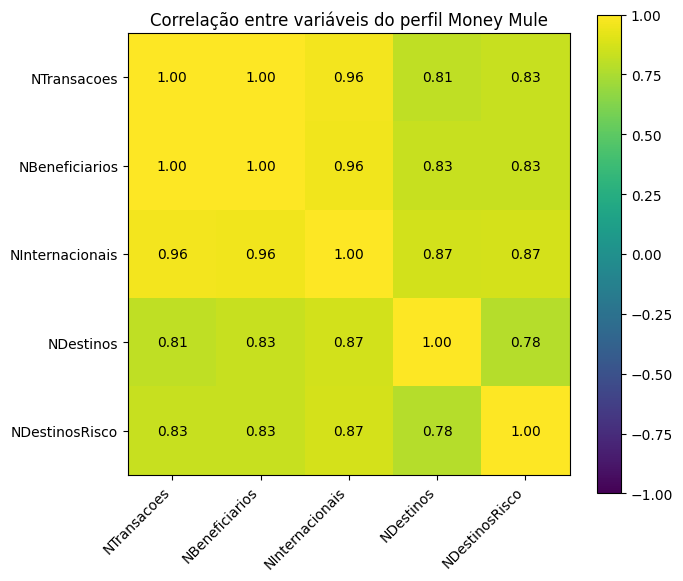

In [86]:
# ==========================================================
# Heatmap da matriz de correlação
# ==========================================================

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Valores dentro das células
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=10
        )

plt.colorbar(im)
plt.title("Correlação entre variáveis do perfil Money Mule")
plt.tight_layout()
plt.show()

In [87]:
# ==========================================================
# Correlações ordenadas
# ==========================================================

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = [
    "Variável 1",
    "Variável 2",
    "Correlação"
]

corr_pairs["Abs"] = corr_pairs["Correlação"].abs()

# Create a temporary column with sorted pairs for deduplication
corr_pairs['sorted_pair'] = corr_pairs.apply(
    lambda x: tuple(sorted([x['Variável 1'], x['Variável 2']])), axis=1
)

corr_pairs = (
    corr_pairs
    .sort_values("Abs", ascending=False)
    .drop_duplicates(subset='sorted_pair')
    .drop(columns='sorted_pair') # Drop the temporary column
)

corr_pairs.drop(columns="Abs").head(10)

,Variável 1,Variável 2,Correlação
0,NTransacoes,NBeneficiarios,0.996820
8,NInternacionais,NTransacoes,0.960977
9,NInternacionais,NBeneficiarios,0.960014
11,NInternacionais,NDestinosRisco,0.868774
14,NDestinos,NInternacionais,0.865942
17,NDestinosRisco,NBeneficiarios,0.834360
16,NDestinosRisco,NTransacoes,0.829572
13,NDestinos,NBeneficiarios,0.828482
2,NTransacoes,NDestinos,0.807490
15,NDestinos,NDestinosRisco,0.775664


### **7.2.5 Teste de combinações de regras**

In [88]:
# ==========================================================
# PASSO 8
# Teste de combinações de regras
# ==========================================================

# Universo real
clientes_mule_real = set(
    tx.loc[tx["MuleFlag"] == 1, "ClientID"].unique()
)

# ==========================================================
# Definição das condições
# ==========================================================

condicoes = {
    "Beneficiarios>=20":
        perfil_clientes_mule["NBeneficiarios"] >= 20,

    "Destinos>=10":
        perfil_clientes_mule["NDestinos"] >= 10,

    "DestinosRisco>=5":
        perfil_clientes_mule["NDestinosRisco"] >= 5
}

# ==========================================================
# Regras a testar
# ==========================================================

regras = {

    "Apenas Beneficiários":
        condicoes["Beneficiarios>=20"],

    "Beneficiários + Destinos":
        condicoes["Beneficiarios>=20"] &
        condicoes["Destinos>=10"],

    "Beneficiários + DestinosRisco":
        condicoes["Beneficiarios>=20"] &
        condicoes["DestinosRisco>=5"],

    "Destinos + DestinosRisco":
        condicoes["Destinos>=10"] &
        condicoes["DestinosRisco>=5"],

    "As 3 condições":
        condicoes["Beneficiarios>=20"] &
        condicoes["Destinos>=10"] &
        condicoes["DestinosRisco>=5"],

    "2 de 3 condições":
        (
            condicoes["Beneficiarios>=20"].astype(int)
            + condicoes["Destinos>=10"].astype(int)
            + condicoes["DestinosRisco>=5"].astype(int)
        ) >= 2
}

In [89]:
# ==========================================================
# Avaliação das regras
# ==========================================================

resultados = []

for nome, regra in regras.items():

    clientes_detectados = set(
        perfil_clientes_mule.loc[
            regra,
            "ClientID"
        ]
    )

    verdadeiros = len(
        clientes_detectados &
        clientes_mule_real
    )

    falsos = len(
        clientes_detectados -
        clientes_mule_real
    )

    recall = verdadeiros / len(clientes_mule_real)

    precision = (
        verdadeiros / len(clientes_detectados)
        if len(clientes_detectados) > 0
        else 0
    )

    resultados.append({

        "Regra": nome,

        "Clientes sinalizados":
            len(clientes_detectados),

        "Money Mules detetados":
            verdadeiros,

        "Recall":
            round(recall * 100,1),

        "Precisão":
            round(precision * 100,1),

        "Falsos positivos":
            falsos
    })

resultado_regras = (
    pd.DataFrame(resultados)
    .sort_values(
        "Precisão",
        ascending=False
    )
)

resultado_regras

,Regra,Clientes sinalizados,Money Mules detetados,Recall,Precisão,Falsos positivos
0,Apenas Beneficiários,102,22,100.0,21.6,80
1,Beneficiários + Destinos,94,20,90.9,21.3,74
5,2 de 3 condições,107,22,100.0,20.6,85
2,Beneficiários + DestinosRisco,79,15,68.2,19.0,64
4,As 3 condições,77,13,59.1,16.9,64
3,Destinos + DestinosRisco,88,13,59.1,14.8,75


### **7.2.6 Engenharia de Features**

In [90]:
# ==========================================================
# 7.2.6 Engenharia de Features
# Variáveis comportamentais para Money Mule
# ==========================================================

perfil_clientes_mule["PctInternacionais"] = (
    perfil_clientes_mule["NInternacionais"] /
    perfil_clientes_mule["NTransacoes"]
)

perfil_clientes_mule["BenefPorTransacao"] = (
    perfil_clientes_mule["NBeneficiarios"] /
    perfil_clientes_mule["NTransacoes"]
)

perfil_clientes_mule["DestinosPorTransacao"] = (
    perfil_clientes_mule["NDestinos"] /
    perfil_clientes_mule["NTransacoes"]
)

perfil_clientes_mule["DestinosRiscoPct"] = (
    perfil_clientes_mule["NDestinosRisco"] /
    perfil_clientes_mule["NDestinos"]
)

perfil_clientes_mule = perfil_clientes_mule.replace(
    [np.inf, -np.inf],
    np.nan
)

**Comparar Money Mules vs Resto**

In [91]:
# ==========================================================
# Comparação das novas variáveis
# ==========================================================

novas_variaveis = [
    "PctInternacionais",
    "BenefPorTransacao",
    "DestinosPorTransacao",
    "DestinosRiscoPct"
]

comparacao_features = (
    perfil_clientes_mule
    .groupby("MuleReal")[novas_variaveis]
    .agg(["mean","median","std"])
    .round(3)
)

comparacao_features

PctInternacionais               BenefPorTransacao                \
                      mean median    std              mean median    std   
MuleReal                                                                   
False                0.601  0.600  0.149             0.994    1.0  0.024   
True                 0.573  0.604  0.087             0.996    1.0  0.012   

         DestinosPorTransacao               DestinosRiscoPct                
                         mean median    std             mean median    std  
MuleReal                                                                    
False                   0.567  0.556  0.151            0.295  0.273  0.221  
True                    0.374  0.365  0.075            0.489  0.472  0.140

**Ver apenas os 22 Money Mules**

In [92]:
perfil_clientes_mule.loc[
    perfil_clientes_mule["MuleReal"],
    [
        "ClientID",
        "PctInternacionais",
        "BenefPorTransacao",
        "DestinosPorTransacao",
        "DestinosRiscoPct"
    ]
].sort_values(
    "BenefPorTransacao",
    ascending=False
)

,ClientID,PctInternacionais,BenefPorTransacao,DestinosPorTransacao,DestinosRiscoPct
31,C0032,0.565217,1.000000,0.239130,0.363636
192,C0193,0.424242,1.000000,0.333333,0.363636
199,C0200,0.630435,1.000000,0.347826,0.687500
280,C0281,0.647059,1.000000,0.382353,0.384615
289,C0290,0.648649,1.000000,0.459459,0.647059
317,C0318,0.622222,1.000000,0.333333,0.733333
577,C0578,0.636364,1.000000,0.424242,0.357143
467,C0468,0.320000,1.000000,0.280000,0.714286
624,C0625,0.534884,1.000000,0.302326,0.538462
580,C0581,0.583333,1.000000,0.458333,0.363636


**Ver distribuição**

In [93]:
for var in novas_variaveis:

    print("\n")
    print("="*60)
    print(var)

    print(
        perfil_clientes_mule
        .groupby("MuleReal")[var]
        .describe()
        .round(3)
    )



PctInternacionais
          count   mean    std    min    25%    50%    75%    max
MuleReal                                                        
False     978.0  0.601  0.149  0.111  0.500  0.600  0.706  1.000
True       22.0  0.573  0.087  0.320  0.543  0.604  0.635  0.667


BenefPorTransacao
          count   mean    std    min  25%  50%  75%  max
MuleReal                                                
False     978.0  0.994  0.024  0.835  1.0  1.0  1.0  1.0
True       22.0  0.996  0.012  0.957  1.0  1.0  1.0  1.0


DestinosPorTransacao
          count   mean    std    min    25%    50%    75%    max
MuleReal                                                        
False     978.0  0.567  0.151  0.164  0.467  0.556  0.667  1.000
True       22.0  0.374  0.075  0.239  0.318  0.365  0.451  0.476


DestinosRiscoPct
          count   mean    std    min    25%    50%   75%    max
MuleReal                                                       
False     978.0  0.295  0.221  0.000  0.14

### **7.2.7 – AML Risk Score**

In [94]:
# ==========================================================
# 7.2.7 AML Risk Score
# ==========================================================

perfil_clientes_mule["Score_Mule"] = 0

# Intensidade da atividade
perfil_clientes_mule.loc[
    perfil_clientes_mule["NBeneficiarios"] >= 20,
    "Score_Mule"
] += 1

# Dispersão geográfica
perfil_clientes_mule.loc[
    perfil_clientes_mule["NDestinos"] >= 10,
    "Score_Mule"
] += 1

# Exposição a países de risco
perfil_clientes_mule.loc[
    perfil_clientes_mule["NDestinosRisco"] >= 5,
    "Score_Mule"
] += 1

# Percentagem de destinos de risco
perfil_clientes_mule.loc[
    perfil_clientes_mule["DestinosRiscoPct"] >= 0.45,
    "Score_Mule"
] += 1

perfil_clientes_mule[[
    "ClientID",
    "Score_Mule"
]].head()

,ClientID,Score_Mule
0,C0001,1
1,C0002,0
2,C0003,0
3,C0004,2
4,C0005,0


**Classificar o Risco**

In [95]:
# ==========================================================
# Classificação do risco
# ==========================================================

def classificar_score(score):

    if score <= 1:
        return "Baixo"

    elif score == 2:
        return "Médio"

    else:
        return "Alto"


perfil_clientes_mule["NivelRiscoMule"] = (
    perfil_clientes_mule["Score_Mule"]
    .apply(classificar_score)
)

perfil_clientes_mule[
    "NivelRiscoMule"
].value_counts()

,count
NivelRiscoMule,
Baixo,867
Alto,89
Médio,44


**clientes de maior risco**

In [96]:
perfil_clientes_mule[
    [
        "ClientID",
        "Score_Mule",
        "NivelRiscoMule",
        "NBeneficiarios",
        "NDestinos",
        "NDestinosRisco",
        "DestinosRiscoPct",
        "MuleReal"
    ]
].sort_values(
    "Score_Mule",
    ascending=False
)

,ClientID,Score_Mule,NivelRiscoMule,NBeneficiarios,NDestinos,NDestinosRisco,DestinosRiscoPct,MuleReal
199,C0200,4,Alto,46,16,11,0.687500,True
58,C0059,4,Alto,25,12,6,0.500000,False
843,C0844,4,Alto,43,18,9,0.500000,False
839,C0840,4,Alto,70,16,9,0.562500,False
228,C0229,4,Alto,51,14,9,0.642857,False
...,...,...,...,...,...,...,...,...
372,C0373,0,Baixo,17,8,1,0.125000,False
374,C0375,0,Baixo,12,6,2,0.333333,False
375,C0376,0,Baixo,10,7,2,0.285714,False
376,C0377,0,Baixo,6,4,1,0.250000,False


**Avaliar o Score**

In [97]:
# ==========================================================
# Avaliação do Score AML
# ==========================================================

for limite in [2,3,4]:

    clientes_detectados = set(
        perfil_clientes_mule.loc[
            perfil_clientes_mule["Score_Mule"] >= limite,
            "ClientID"
        ]
    )

    verdadeiros = len(
        clientes_detectados &
        clientes_mule_real
    )

    falsos = len(
        clientes_detectados -
        clientes_mule_real
    )

    recall = verdadeiros / len(clientes_mule_real)

    precision = (
        verdadeiros / len(clientes_detectados)
        if len(clientes_detectados) > 0
        else 0
    )

    print("="*60)
    print(f"Score ≥ {limite}")

    print(f"Clientes sinalizados: {len(clientes_detectados)}")
    print(f"Money Mules: {verdadeiros}/22")
    print(f"Recall: {recall*100:.1f}%")
    print(f"Precisão: {precision*100:.1f}%")
    print(f"Falsos positivos: {falsos}")

Score ≥ 2
Clientes sinalizados: 133
Money Mules: 22/22
Recall: 100.0%
Precisão: 16.5%
Falsos positivos: 111
Score ≥ 3
Clientes sinalizados: 89
Money Mules: 15/22
Recall: 68.2%
Precisão: 16.9%
Falsos positivos: 74
Score ≥ 4
Clientes sinalizados: 64
Money Mules: 9/22
Recall: 40.9%
Precisão: 14.1%
Falsos positivos: 55


### **Resumo da análise de Money Mules**

A análise iniciou-se com a identificação dos 22 clientes classificados como Money Mules no dataset, utilizando a variável de referência (MuleFlag). A partir destes clientes foi construído um perfil comportamental agregado ao nível do cliente, recorrendo à agregação das transações individuais. Foram calculados indicadores representativos da atividade financeira, nomeadamente o número de transações, o valor total movimentado, o valor médio e mediano das operações, o número de beneficiários distintos, o número de transações internacionais, o número de países de destino, o número de destinos classificados como de risco e o número de transações internacionais realizadas durante o período noturno.

Numa primeira fase procedeu-se à caracterização estatística destes 22 clientes, verificando-se que apresentam, em média, cerca de 35 transações, 35 beneficiários distintos, 20 transações internacionais, 13 países de destino e mais de 6 destinos classificados como de risco. Comparativamente ao restante universo de clientes, os Money Mules evidenciam um volume de atividade significativamente superior, tanto em número de operações como em diversidade de beneficiários e destinos.

Posteriormente foi realizada uma normalização das principais variáveis através do cálculo de Z-scores, permitindo comparar o comportamento dos Money Mules relativamente à população global. Os resultados demonstraram que estes clientes apresentam valores sistematicamente acima da média nas variáveis analisadas, destacando-se particularmente o número de beneficiários, o número de destinos e o número de transações internacionais. Com base nesta análise foram definidos vários thresholds para cada variável, avaliando-se a percentagem de Money Mules reais identificados para diferentes níveis de corte.

A análise dos thresholds permitiu concluir que variáveis como o número de beneficiários, o número de destinos e o número de destinos de risco apresentam elevado poder de deteção quando utilizados individualmente. Por exemplo, um limiar de 20 beneficiários permitiu identificar a totalidade dos 22 Money Mules, embora à custa de um número significativo de falsos positivos, evidenciando o compromisso existente entre capacidade de deteção (recall) e precisão.

De seguida foi analisada a correlação entre as variáveis utilizadas na construção das regras. A matriz de correlação revelou coeficientes muito elevados entre o número de transações, o número de beneficiários e o número de transações internacionais (superiores a 0,95), indicando que estas variáveis representam essencialmente a mesma dimensão do comportamento do cliente: a intensidade da atividade transacional. Esta elevada redundância explica porque a combinação destas variáveis em regras compostas não conduziu a melhorias significativas no desempenho do sistema.

Foi igualmente efetuada uma fase de engenharia de features, através da criação de variáveis relativas, como a percentagem de transações internacionais, o número médio de beneficiários por transação, o número médio de destinos por transação e a proporção de destinos classificados como de risco. No entanto, estas novas variáveis apresentaram uma capacidade discriminativa reduzida, não permitindo separar de forma mais eficaz os Money Mules do restante universo de clientes.

Com base nas variáveis anteriormente definidas foi ainda desenvolvido um AML Risk Score, atribuindo um ponto por cada condição satisfeita e classificando os clientes em níveis de risco baixo, médio ou elevado. Contudo, a avaliação deste sistema demonstrou que o score não melhorou os resultados obtidos pelas regras individuais. Embora tenha mantido uma elevada taxa de deteção em alguns limiares, verificou-se um aumento do número de falsos positivos e uma redução da precisão global, concluindo-se que a agregação das variáveis não acrescenta capacidade discriminativa devido à forte correlação existente entre elas.

Em síntese, a análise permitiu concluir que os Money Mules presentes no dataset distinguem-se sobretudo por apresentarem uma atividade transacional mais intensa e diversificada do que os restantes clientes. No entanto, verificou-se igualmente que existe uma sobreposição significativa entre clientes legítimos de elevada atividade e clientes classificados como Money Mules, limitando naturalmente o desempenho de qualquer regra baseada exclusivamente nas variáveis disponíveis. Assim, optou-se por privilegiar regras simples, transparentes e facilmente interpretáveis, uma vez que apresentaram um desempenho semelhante ao de modelos mais complexos, mantendo uma maior facilidade de explicação e implementação num contexto real de monitorização AML.

**Criar uma saída estável para a regra Mule**

In [98]:
# ==========================================================
# SAÍDA FINAL DA SECÇÃO 7 — REGRA MONEY MULE
# ==========================================================

# Regra de elevada cobertura selecionada após a calibração:
# NBeneficiarios >= 20
perfil_clientes_mule["Alert_Mule_Candidato"] = (
    perfil_clientes_mule["NBeneficiarios"] >= 20
)

# Regra mais exigente, utilizada como confirmação adicional
perfil_clientes_mule["Alert_Mule_Forte"] = (
    (perfil_clientes_mule["NBeneficiarios"] >= 20)
    & (perfil_clientes_mule["NDestinos"] >= 10)
)

# Nome genérico que será utilizado pelas secções posteriores
# Mantém uma interface estável no notebook
perfil_clientes_mule["Alert_MulePattern"] = (
    perfil_clientes_mule["Alert_Mule_Candidato"]
)

print("Candidatos Mule:", perfil_clientes_mule["Alert_Mule_Candidato"].sum())
print("Candidatos Mule fortes:", perfil_clientes_mule["Alert_Mule_Forte"].sum())

Candidatos Mule: 102
Candidatos Mule fortes: 94


## **8. Análise descritiva**

### **8.1 Caracterização geral da carteira**

In [99]:
print(f"Total de clientes: {cl.shape[0]}")
print(f"Total de contas: {ac.shape[0]}")
print(f"Total de transações: {tx.shape[0]}")
print(f"Período: {tx['DateTime'].min()} a {tx['DateTime'].max()}")

print(tx["TransactionType"].value_counts())
print(tx["Channel"].value_counts())

Total de clientes: 1000
Total de contas: 1300
Total de transações: 15158
Período: 2026-01-01 00:49:00 a 2026-04-01 19:57:00
TransactionType
Transfer                 4609
CardPayment              3654
InternationalTransfer    2180
CashDeposit              1925
InstantTransfer          1428
CashWithdrawal           1222
CryptoPurchase            140
Name: count, dtype: int64
Channel
Online    4950
Mobile    3944
Branch    3730
ATM       2534
Name: count, dtype: int64


A carteira em análise é constituída por 1 000 clientes, distribuídos por 1 300 contas, que realizaram um total de 15 158 transações entre 1 de janeiro e 1 de abril de 2026. As operações mais frequentes são as transferências nacionais, seguidas dos pagamentos por cartão e das transferências internacionais, evidenciando uma utilização predominante de meios de pagamento eletrónicos.

Relativamente aos canais utilizados, o canal Online apresenta o maior volume de transações, seguido dos canais Mobile, Branch e ATM, refletindo uma forte utilização dos serviços digitais.

### **8.2 Perfil de risco da carteira**

In [100]:
print(cl["RiskBand"].value_counts())

print(cl["PEP (pessoa politicamente exposta)"].value_counts())

print(cl["HighRiskResidence"].value_counts())

print((cl["MonthsSinceKYCUpdate"] >= 36).value_counts())

RiskBand
Low         908
Medium       67
Critical     18
High          7
Name: count, dtype: int64
PEP (pessoa politicamente exposta)
0    975
1     25
Name: count, dtype: int64
HighRiskResidence
0    928
1     72
Name: count, dtype: int64
MonthsSinceKYCUpdate
False    968
True      32
Name: count, dtype: int64


A carteira apresenta um perfil de risco globalmente reduzido, com 90,8% dos clientes classificados como Low RiskBand.

Apenas 25 clientes são Pessoas Politicamente Expostas (PEP), 72 residem em jurisdições de risco elevado e 32 apresentam o processo de KYC desatualizado há mais de 36 meses.

Estes resultados indicam que a maioria dos clientes possui características de baixo risco, sendo os fatores de risco mais elevados concentrados num grupo relativamente pequeno da população, o que justifica a utilização de regras de deteção específicas nas análises seguintes.

### **8.3 Estatísticas por tipo de transação**

In [101]:
tx.groupby("TransactionType")["AmountEUR"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
TransactionType,,,,,,,,
CardPayment,3654.0,184.74,229.16,8.06,64.28,116.36,219.08,5760.13
CashDeposit,1925.0,4479.68,4358.93,29.03,548.22,1754.34,9623.42,28667.87
CashWithdrawal,1222.0,1190.99,1659.25,24.36,340.61,685.13,1442.87,22608.61
CryptoPurchase,140.0,13227.78,5077.65,3723.26,9054.16,13201.44,17259.26,21962.67
InstantTransfer,1428.0,1255.83,1759.45,23.21,439.46,859.01,1447.17,24493.28
InternationalTransfer,2180.0,9395.94,13112.77,57.55,1056.58,2573.05,14781.17,66253.30
Transfer,4609.0,2113.23,2631.87,24.87,479.38,1159.01,3077.82,44737.41


In [102]:
tx.groupby("TransactionType")["AmountEUR"].agg(
    ["count",
     "mean",
     "median",
     "std",
     "min",
     "max"]
)

,count,mean,median,std,min,max
TransactionType,,,,,,
CardPayment,3654,184.737652,116.365,229.161529,8.06,5760.13
CashDeposit,1925,4479.678644,1754.340,4358.933769,29.03,28667.87
CashWithdrawal,1222,1190.993249,685.130,1659.249699,24.36,22608.61
CryptoPurchase,140,13227.784500,13201.435,5077.653521,3723.26,21962.67
InstantTransfer,1428,1255.830728,859.010,1759.447354,23.21,24493.28
InternationalTransfer,2180,9395.938683,2573.050,13112.773181,57.55,66253.30
Transfer,4609,2113.227438,1159.010,2631.869439,24.87,44737.41


### **8.4. Distribuição dos Montantes**

Nesta secção analisa-se a distribuição global dos montantes transacionados na carteira. O objetivo é caracterizar a forma da distribuição, identificar assimetrias e perceber a presença de valores extremos, sem utilizar esta análise como método autónomo de deteção de fraude.

A análise é apresentada para o conjunto total das transações e, posteriormente, por tipo de transação, uma vez que diferentes operações financeiras podem apresentar escalas de montantes distintas.

#### **8.4.1 Estatísticas gerais de AmountEUR**

In [103]:
# ==========================================================
# 8.4.1 Estatísticas gerais dos montantes
# ==========================================================

estatisticas_montantes = (
    tx["AmountEUR"]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .round(2)
)

estatisticas_montantes

,AmountEUR
count,15158.00
mean,2943.79
std,6310.65
min,8.06
1%,26.32
5%,54.60
25%,230.60
50%,765.86
75%,2485.31
95%,11909.97


In [104]:
assimetria_amount = tx["AmountEUR"].skew()
curtose_amount = tx["AmountEUR"].kurt()

print(f"Assimetria: {assimetria_amount:.2f}")
print(f"Curtose: {curtose_amount:.2f}")

Assimetria: 4.56
Curtose: 26.26


Interpretação:

* assimetria positiva: concentração em montantes baixos e cauda para valores altos;
* assimetria próxima de zero: distribuição mais simétrica;
* curtose elevada: maior presença de valores extremos.

#### **8.4.2 Histograma sem os valores extremos**

In [105]:
# ==========================================================
# Distribuição até ao percentil 99
# ==========================================================

limite_p99 = tx["AmountEUR"].quantile(0.99)

tx_sem_extremos = tx[
    tx["AmountEUR"] <= limite_p99
].copy()

print(
    "Limite do percentil 99:",
    round(limite_p99, 2),
    "€"
)

print(
    "Transações excluídas apenas da visualização:",
    len(tx) - len(tx_sem_extremos)
)

Limite do percentil 99: 33672.3 €
Transações excluídas apenas da visualização: 152


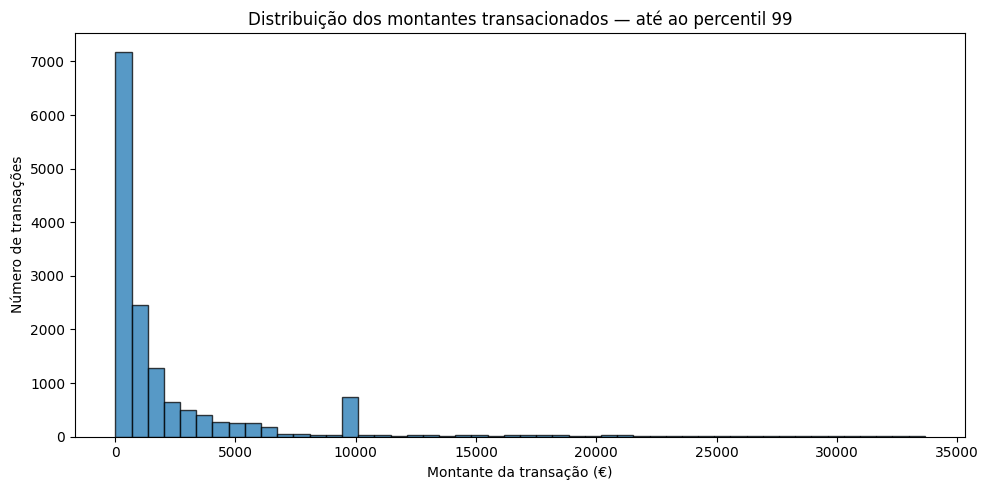

In [106]:
plt.figure(figsize=(10, 5))

plt.hist(
    tx_sem_extremos["AmountEUR"],
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.title(
    "Distribuição dos montantes transacionados — até ao percentil 99"
)

plt.xlabel("Montante da transação (€)")
plt.ylabel("Número de transações")

plt.tight_layout()
plt.show()

#### **8.4.3 Estatísticas por tipo de transação**

In [107]:
# ==========================================================
# Estatísticas dos montantes por tipo de transação
# ==========================================================

montantes_por_tipo = (
    tx
    .groupby("TransactionType")["AmountEUR"]
    .agg(
        NumeroTransacoes="count",
        Media="mean",
        Mediana="median",
        DesvioPadrao="std",
        Minimo="min",
        Maximo="max"
    )
    .round(2)
    .sort_values(
        "Mediana",
        ascending=False
    )
)

montantes_por_tipo

,NumeroTransacoes,Media,Mediana,DesvioPadrao,Minimo,Maximo
TransactionType,,,,,,
CryptoPurchase,140,13227.78,13201.44,5077.65,3723.26,21962.67
InternationalTransfer,2180,9395.94,2573.05,13112.77,57.55,66253.30
CashDeposit,1925,4479.68,1754.34,4358.93,29.03,28667.87
Transfer,4609,2113.23,1159.01,2631.87,24.87,44737.41
InstantTransfer,1428,1255.83,859.01,1759.45,23.21,24493.28
CashWithdrawal,1222,1190.99,685.13,1659.25,24.36,22608.61
CardPayment,3654,184.74,116.36,229.16,8.06,5760.13


#### **8.4.4 Boxplot por tipo de transação em escala logarítmica**

In [108]:
showfliers=False

/tmp/ipykernel_1989/3683123171.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


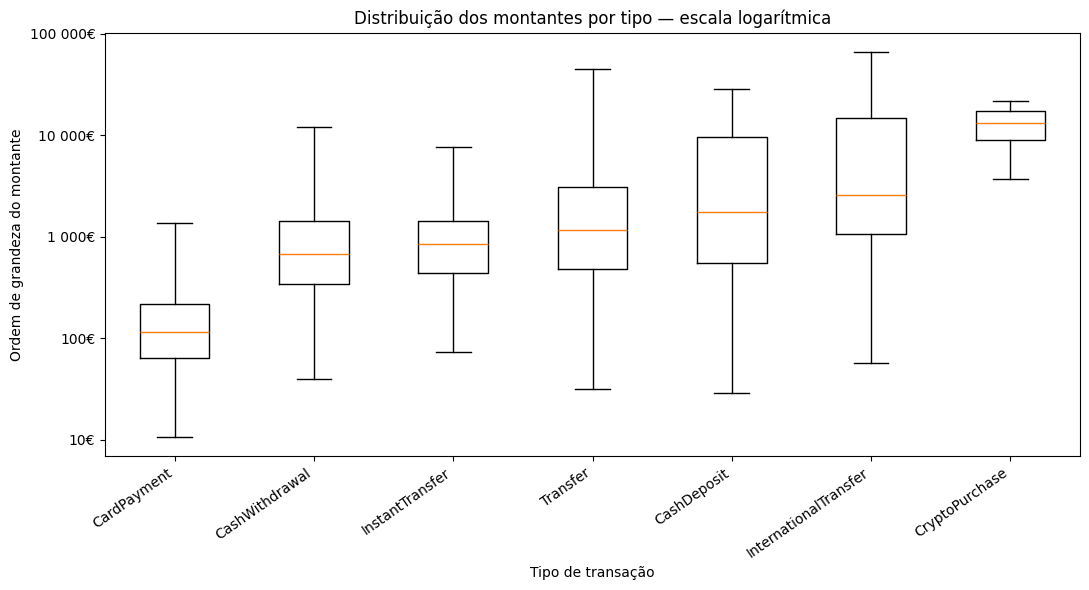

In [109]:
# ==========================================================
# Boxplot por tipo — escala logarítmica
# ==========================================================

tx_box_log = tx[
    tx["AmountEUR"] > 0
].copy()

tipos_ordenados_log = (
    tx_box_log
    .groupby("TransactionType")["AmountEUR"]
    .median()
    .sort_values()
    .index
)

dados_boxplot_log = [
    np.log10(
        tx_box_log.loc[
            tx_box_log["TransactionType"] == tipo,
            "AmountEUR"
        ]
    )
    for tipo in tipos_ordenados_log
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    dados_boxplot_log,
    labels=tipos_ordenados_log,
    showfliers=False
)

plt.title(
    "Distribuição dos montantes por tipo — escala logarítmica"
)

plt.xlabel("Tipo de transação")
plt.ylabel("Ordem de grandeza do montante")

plt.yticks(
    [1, 2, 3, 4, 5],
    ["10€", "100€", "1 000€", "10 000€", "100 000€"]
)

plt.xticks(rotation=35, ha="right")

plt.tight_layout()
plt.show()

### **8.5 Evolução Temporal**

Nesta secção analisa-se a evolução temporal da atividade transacional ao longo do período em estudo (janeiro a abril de 2026).

O objetivo é identificar possíveis variações na intensidade da atividade, padrões sazonais ou concentrações temporais que possam ajudar a contextualizar as análises de fraude realizadas nas secções anteriores.

#### **8.5.1 Preparação das datas**

In [110]:
# ==========================================================
# 8.4.1 Preparação da variável temporal
# ==========================================================

tx_time = tx.copy()

tx_time["DateTime"] = pd.to_datetime(tx_time["DateTime"])

tx_time["Mes"] = tx_time["DateTime"].dt.to_period("M")

tx_time["Semana"] = tx_time["DateTime"].dt.to_period("W")

tx_time["Data"] = tx_time["DateTime"].dt.date

#### **8.5.2 Evolução mensal (visão geral)**

In [111]:
# ==========================================================
# Evolução mensal
# ==========================================================

transacoes_mes = (
    tx_time
    .groupby("Mes")
    .size()
    .reset_index(name="NumeroTransacoes")
)

transacoes_mes["Mes"] = (
    transacoes_mes["Mes"]
    .astype(str)
)

transacoes_mes

,Mes,NumeroTransacoes
0,2026-01,5242
1,2026-02,4810
2,2026-03,5104
3,2026-04,2


**Gráfico mensal**

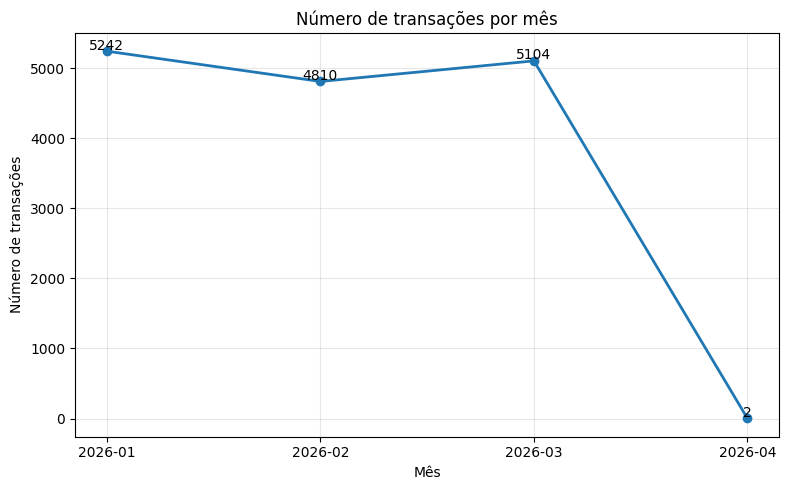

In [112]:
plt.figure(figsize=(8,5))

plt.plot(
    transacoes_mes["Mes"],
    transacoes_mes["NumeroTransacoes"],
    marker="o",
    linewidth=2
)

plt.title("Número de transações por mês")

plt.xlabel("Mês")

plt.ylabel("Número de transações")

plt.grid(alpha=0.3)

for i,v in enumerate(transacoes_mes["NumeroTransacoes"]):
    plt.text(i, v+20, str(v), ha="center")

plt.tight_layout()

plt.show()

#### **8.5.3 Evolução semanal (identifica picos)**

In [113]:
# ==========================================================
# Evolução semanal
# ==========================================================

transacoes_semana = (
    tx_time
    .groupby("Semana")
    .size()
    .reset_index(name="NumeroTransacoes")
)

transacoes_semana["Semana"] = (
    transacoes_semana["Semana"]
    .astype(str)
)

transacoes_semana.head()

,Semana,NumeroTransacoes
0,2025-12-29/2026-01-04,653
1,2026-01-05/2026-01-11,1148
2,2026-01-12/2026-01-18,1301
3,2026-01-19/2026-01-25,1189
4,2026-01-26/2026-02-01,1125


**Gráfico Semanal**

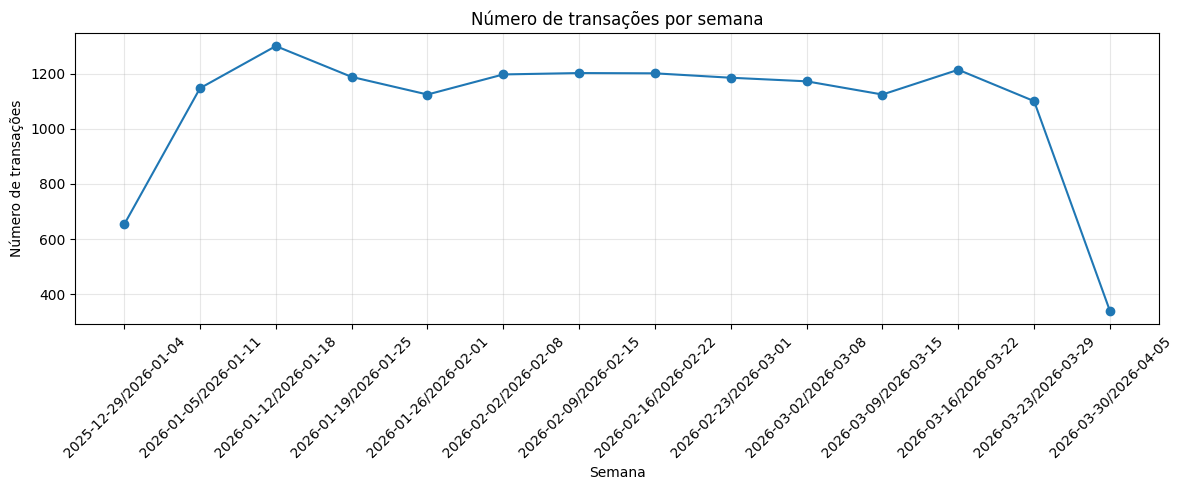

In [114]:
plt.figure(figsize=(12,5))

plt.plot(
    transacoes_semana["Semana"],
    transacoes_semana["NumeroTransacoes"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Número de transações por semana")

plt.xlabel("Semana")

plt.ylabel("Número de transações")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### **8.5.4 Evolução diária (maior detalhe)**

Esta análise é útil para verificar se existem dias com atividade invulgarmente elevada.

In [115]:
# ==========================================================
# Evolução diária
# ==========================================================

transacoes_dia = (
    tx_time
    .groupby("Data")
    .size()
    .reset_index(name="NumeroTransacoes")
)

transacoes_dia.head()

,Data,NumeroTransacoes
0,2026-01-01,153
1,2026-01-02,183
2,2026-01-03,163
3,2026-01-04,154
4,2026-01-05,161


**Gráfico diário**

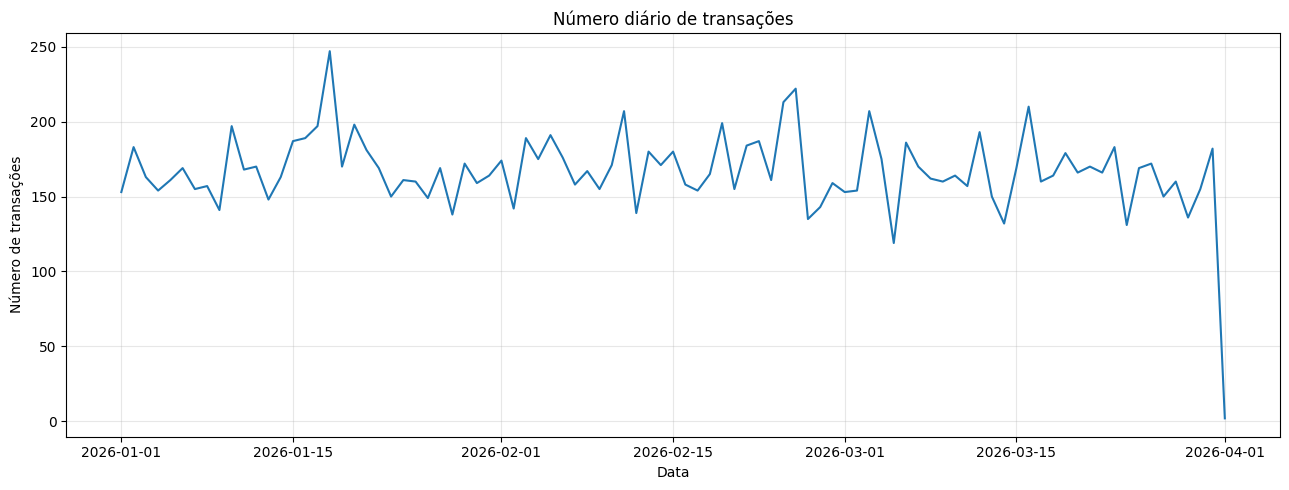

In [116]:
plt.figure(figsize=(13,5))

plt.plot(
    transacoes_dia["Data"],
    transacoes_dia["NumeroTransacoes"],
    linewidth=1.5
)

plt.title("Número diário de transações")

plt.xlabel("Data")

plt.ylabel("Número de transações")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

#### **8.5.5 Resumo estatístico da evolução temporal**

In [117]:
resumo_temporal = pd.DataFrame({

    "Indicador":[
        "Média diária",
        "Máximo diário",
        "Mínimo diário",
        "Desvio padrão"
    ],

    "Valor":[
        transacoes_dia["NumeroTransacoes"].mean(),
        transacoes_dia["NumeroTransacoes"].max(),
        transacoes_dia["NumeroTransacoes"].min(),
        transacoes_dia["NumeroTransacoes"].std()
    ]

})

resumo_temporal.round(2)

,Indicador,Valor
0,Média diária,166.57
1,Máximo diário,247.00
2,Mínimo diário,2.00
3,Desvio padrão,27.34


**Valor total movimentado por semana**

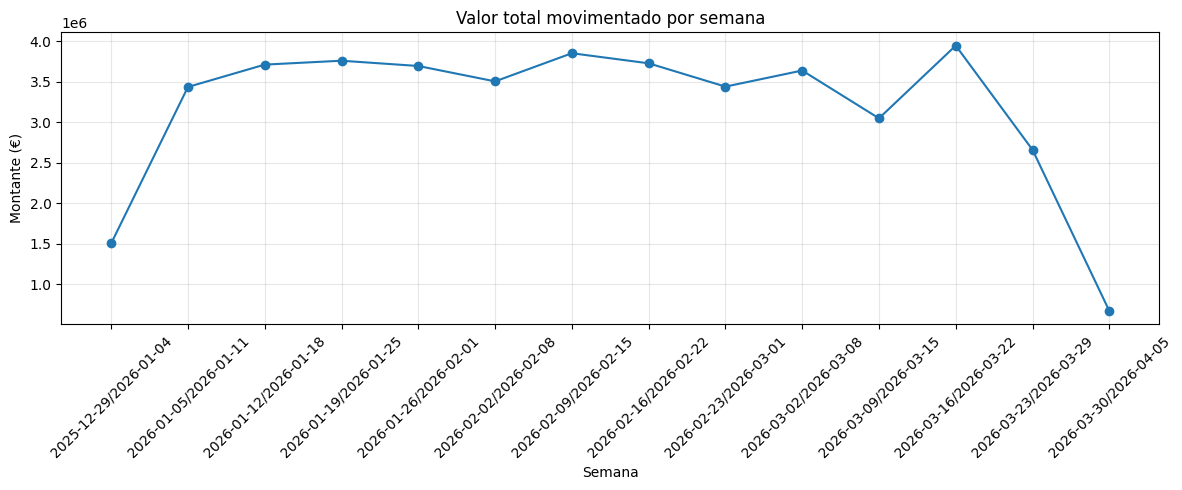

In [118]:
valor_semana = (
    tx_time
    .groupby("Semana")["AmountEUR"]
    .sum()
    .reset_index()
)

valor_semana["Semana"] = valor_semana["Semana"].astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    valor_semana["Semana"],
    valor_semana["AmountEUR"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Valor total movimentado por semana")

plt.xlabel("Semana")

plt.ylabel("Montante (€)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### **8.6 Comparação Suspeitos vs Resto**

Nesta análise comparam-se os clientes já sinalizados pelas regras e pela análise de thresholds com os restantes clientes da carteira.

O objetivo não é identificar novos suspeitos, mas caracterizar as diferenças comportamentais entre os dois grupos, considerando o número de transações, o valor total movimentado, o valor médio das operações, o número de contas, o número de beneficiários e a proporção de operações internacionais e noturnas.

O objetivo é criar três grupos mutuamente exclusivos, sem contar os mesmos clientes duas vezes:


*   Smurfing — os 25 clientes com padrão específico de fracionamento;
*   Candidatos Money Mule exclusivos — clientes da regra Mule que não pertencem ao grupo Smurfing;
*   Restantes clientes — não sinalizados por nenhuma das duas análises.

#### **8.6.1 Definição dos clientes sinalizados**

In [119]:
# ==========================================================
# 8.6.1 Definição dos grupos para comparação descritiva
# ==========================================================

# Universo total de clientes
todos_clientes = set(
    cl["ClientID"].unique()
)

# ----------------------------------------------------------
# 1. Clientes com padrão de Smurfing
# ----------------------------------------------------------

ids_smurfing = set(
    suspeitos_thr.loc[
        suspeitos_thr["n_transacoes"] >= 3
    ].index
)

# ----------------------------------------------------------
# 2. Candidatos Money Mule
# ----------------------------------------------------------

# Regra selecionada na secção 7:
# NBeneficiarios >= 20
ids_mule_candidatos = set(
    perfil_clientes_mule.loc[
        perfil_clientes_mule["Alert_MulePattern"],
        "ClientID"
    ]
)

# ----------------------------------------------------------
# 3. Sobreposição original
# Guardada para análise posterior na matriz de convergência
# ----------------------------------------------------------

ids_sobreposicao = (
    ids_smurfing
    & ids_mule_candidatos
)

# ----------------------------------------------------------
# 4. Money Mules exclusivos
# Retirar os Smurfers para evitar dupla contagem
# ----------------------------------------------------------

ids_mule_exclusivos = (
    ids_mule_candidatos
    - ids_smurfing
)

# ----------------------------------------------------------
# 5. Restantes clientes
# ----------------------------------------------------------

ids_restantes = (
    todos_clientes
    - ids_smurfing
    - ids_mule_exclusivos
)

# ----------------------------------------------------------
# Resumo
# ----------------------------------------------------------

print("=== GRUPOS EXCLUSIVOS PARA A ANÁLISE DESCRITIVA ===")
print(f"Smurfing: {len(ids_smurfing)}")
print(
    "Candidatos Money Mule exclusivos: "
    f"{len(ids_mule_exclusivos)}"
)
print(f"Restantes clientes: {len(ids_restantes)}")

print("\n=== SOBREPOSIÇÃO ANTES DA SEPARAÇÃO ===")
print(
    "Clientes sinalizados simultaneamente: "
    f"{len(ids_sobreposicao)}"
)

print("\n=== CONTROLO ===")
print(
    "Total dos três grupos: "
    f"{len(ids_smurfing) + len(ids_mule_exclusivos) + len(ids_restantes)}"
)

=== GRUPOS EXCLUSIVOS PARA A ANÁLISE DESCRITIVA ===
Smurfing: 25
Candidatos Money Mule exclusivos: 77
Restantes clientes: 898

=== SOBREPOSIÇÃO ANTES DA SEPARAÇÃO ===
Clientes sinalizados simultaneamente: 25

=== CONTROLO ===
Total dos três grupos: 1000


**Verificar a sobreposição**

In [120]:
print("\nClientes com sobreposição:")
print(sorted(ids_sobreposicao))


Clientes com sobreposição:
['C0021', 'C0024', 'C0037', 'C0044', 'C0053', 'C0090', 'C0129', 'C0130', 'C0134', 'C0140', 'C0189', 'C0229', 'C0242', 'C0307', 'C0431', 'C0492', 'C0587', 'C0742', 'C0776', 'C0787', 'C0793', 'C0844', 'C0864', 'C0905', 'C0922']


Clientes simultaneamente sinalizados por smurfing e mule: 25

**VERIFICAÇÕES DE INTEGRIDADE**

In [121]:
# ==========================================================
# Verificações de integridade dos grupos
# ==========================================================

assert len(ids_smurfing & ids_mule_exclusivos) == 0, (
    "Existem clientes simultaneamente nos grupos "
    "Smurfing e Mule exclusivo."
)

assert len(ids_smurfing & ids_restantes) == 0, (
    "Existem Smurfers classificados como restantes."
)

assert len(ids_mule_exclusivos & ids_restantes) == 0, (
    "Existem candidatos Mule classificados como restantes."
)

assert (
    ids_smurfing
    | ids_mule_exclusivos
    | ids_restantes
) == todos_clientes, (
    "Os três grupos não cobrem corretamente a carteira completa."
)

print("Grupos mutuamente exclusivos e carteira completa.")

Grupos mutuamente exclusivos e carteira completa.


Para evitar dupla contagem, os clientes sinalizados simultaneamente pelas análises de smurfing e money mule foram atribuídos ao grupo de smurfing nesta comparação descritiva. Esta escolha resulta do carácter mais específico e diretamente observável do padrão de fracionamento. A sobreposição original foi preservada e será retomada na matriz de convergência, onde as diferentes evidências serão combinadas para determinar a tipologia e a prioridade final.

In [122]:
# ==========================================================
# Verificação da sobreposição entre os grupos finais
# ==========================================================

ids_sobreposicao_final = (
    ids_smurfing &
    ids_mule_exclusivos
)

print("Smurfers:", len(ids_smurfing))
print("Money Mule exclusivos:", len(ids_mule_exclusivos))
print("Sobreposição:", len(ids_sobreposicao_final))
print()

print("Clientes na sobreposição:")
print(sorted(ids_sobreposicao_final))

assert len(ids_sobreposicao_final) == 0, (
    "Existem clientes simultaneamente classificados "
    "como Smurfing e Money Mule exclusivo."
)

print("\n✓ Verificação concluída: os grupos são mutuamente exclusivos.")

Smurfers: 25
Money Mule exclusivos: 77
Sobreposição: 0

Clientes na sobreposição:
[]

✓ Verificação concluída: os grupos são mutuamente exclusivos.


#### **8.6.2 Construção da tabela ao nível do cliente**

In [123]:
# ==========================================================
# 8.5.2 Agregação das transações por cliente
# ==========================================================

perfil_clientes = (
    tx
    .groupby("ClientID")
    .agg(
        NTransacoes=(
            "TransactionID",
            "count"
        ),
        ValorTotal=(
            "AmountEUR",
            "sum"
        ),
        ValorMedio=(
            "AmountEUR",
            "mean"
        ),
        ValorMediano=(
            "AmountEUR",
            "median"
        ),
        NContas=(
            "AccountID",
            "nunique"
        ),
        NBeneficiarios=(
            "BeneficiaryID",
            "nunique"
        ),
        NInternacionais=(
            "IsInternational",
            "sum"
        ),
        NNoturnas=(
            "IsNight",
            "sum"
        ),
        NDestinosRisco=(
            "HighRiskDestination",
            "sum"
        ),
        NCashDeposits=(
            "IsCash",
            "sum"
        )
    )
    .reset_index()
)

perfil_clientes.head()

,ClientID,NTransacoes,ValorTotal,ValorMedio,ValorMediano,NContas,NBeneficiarios,NInternacionais,NNoturnas,NDestinosRisco,NCashDeposits
0,C0001,14,8582.86,613.061429,381.29,1,14,5,1,3,2
1,C0002,8,4489.93,561.241250,175.81,1,8,4,2,2,0
2,C0003,8,10307.11,1288.388750,294.43,1,8,3,0,1,2
3,C0004,15,37387.66,2492.510667,1943.85,2,15,13,1,7,0
4,C0005,16,24293.44,1518.340000,360.71,3,16,10,3,2,3


**Criar proporções**

As contagens absolutas são importantes, mas podem favorecer clientes com maior atividade. Por isso, também calculamos percentagens.

In [124]:
perfil_clientes["PercInternacionais"] = (
    perfil_clientes["NInternacionais"]
    / perfil_clientes["NTransacoes"]
    * 100
)

perfil_clientes["PercNoturnas"] = (
    perfil_clientes["NNoturnas"]
    / perfil_clientes["NTransacoes"]
    * 100
)

perfil_clientes["PercDestinosRisco"] = (
    perfil_clientes["NDestinosRisco"]
    / perfil_clientes["NTransacoes"]
    * 100
)

perfil_clientes["PercCash"] = (
    perfil_clientes["NCashDeposits"]
    / perfil_clientes["NTransacoes"]
    * 100
)

In [125]:
# ==========================================================
# Definição dos grupos para a análise descritiva
# ==========================================================

perfil_clientes["Grupo"] = "Restantes"

# Money Mule exclusivos
perfil_clientes.loc[
    perfil_clientes["ClientID"].isin(ids_mule_exclusivos),
    "Grupo"
] = "Money Mule"

# Smurfing
perfil_clientes.loc[
    perfil_clientes["ClientID"].isin(ids_smurfing),
    "Grupo"
] = "Smurfing"

print(perfil_clientes["Grupo"].value_counts())

Grupo
Restantes     898
Money Mule     77
Smurfing       25
Name: count, dtype: int64


#### **8.6.3 Definição e validação dos grupos**

In [126]:
# ==========================================================
# 8.6.3 Comparação entre os três grupos
# Reconstrução segura da coluna Grupo
# ==========================================================

# Recriar a coluna desde o início
perfil_clientes["Grupo"] = "Restantes"

# Clientes Money Mule exclusivos
perfil_clientes.loc[
    perfil_clientes["ClientID"].isin(ids_mule_exclusivos),
    "Grupo"
] = "Money Mule"

# Clientes Smurfing
perfil_clientes.loc[
    perfil_clientes["ClientID"].isin(ids_smurfing),
    "Grupo"
] = "Smurfing"

# Confirmar os valores antes da conversão categórica
print("Contagem antes da ordenação:")
print(
    perfil_clientes["Grupo"]
    .value_counts()
)

# Definir uma ordem lógica para tabelas e gráficos
ordem_grupos = [
    "Restantes",
    "Money Mule",
    "Smurfing"
]

perfil_clientes["Grupo"] = pd.Categorical(
    perfil_clientes["Grupo"],
    categories=ordem_grupos,
    ordered=True
)

print("\nContagem após a ordenação:")
print(
    perfil_clientes["Grupo"]
    .value_counts(sort=False)
)

Contagem antes da ordenação:
Grupo
Restantes     898
Money Mule     77
Smurfing       25
Name: count, dtype: int64

Contagem após a ordenação:
Grupo
Restantes     898
Money Mule     77
Smurfing       25
Name: count, dtype: int64


In [127]:
# ==========================================================
# Verificação de integridade
# ==========================================================

contagem_grupos = (
    perfil_clientes["Grupo"]
    .value_counts(sort=False)
    .to_dict()
)

assert perfil_clientes["Grupo"].isna().sum() == 0, (
    "Existem clientes sem grupo definido."
)

assert contagem_grupos == {
    "Restantes": 898,
    "Money Mule": 77,
    "Smurfing": 25
}, (
    f"Distribuição inesperada: {contagem_grupos}"
)

assert len(perfil_clientes) == 1000, (
    "A tabela não contém exatamente os 1000 clientes."
)

print("Classificação dos três grupos validada.")

Classificação dos três grupos validada.


#### **8.6.4 Comparação entre grupos**

**Médias**

In [128]:
variaveis = [
    "NTransacoes",
    "ValorTotal",
    "ValorMedio",
    "ValorMediano",
    "NContas",
    "NBeneficiarios",
    "NInternacionais",
    "NNoturnas",
    "NDestinosRisco",
    "NCashDeposits",
    "PercInternacionais",
    "PercNoturnas",
    "PercDestinosRisco",
    "PercCash"
]

media_grupos = (
    perfil_clientes
    .groupby("Grupo", observed=True)[variaveis]
    .mean()
    .round(2)
)

media_grupos

,NTransacoes,ValorTotal,ValorMedio,ValorMediano,NContas,NBeneficiarios,NInternacionais,NNoturnas,NDestinosRisco,NCashDeposits,PercInternacionais,PercNoturnas,PercDestinosRisco,PercCash
Grupo,,,,,,,,,,,,,,
Restantes,11.70,16316.22,1359.92,612.20,1.30,11.66,7.05,1.14,1.84,2.38,60.04,9.62,15.71,20.11
Money Mule,44.42,236023.95,4529.11,2322.42,1.29,41.17,25.96,5.60,8.08,2.91,60.13,12.42,18.98,9.76
Smurfing,49.08,471848.89,9644.07,9675.30,1.20,48.56,28.48,1.16,10.20,31.28,58.07,2.35,20.75,63.71


**Medianas**

In [129]:
mediana_grupos = (
    perfil_clientes
    .groupby("Grupo", observed=True)[variaveis]
    .median()
    .round(2)
)

mediana_grupos

,NTransacoes,ValorTotal,ValorMedio,ValorMediano,NContas,NBeneficiarios,NInternacionais,NNoturnas,NDestinosRisco,NCashDeposits,PercInternacionais,PercNoturnas,PercDestinosRisco,PercCash
Grupo,,,,,,,,,,,,,,
Restantes,12.0,10441.86,887.53,462.87,1.0,12.0,7.0,1.0,2.0,2.0,60.00,8.33,14.29,20.00
Money Mule,31.0,159596.29,5746.52,1347.60,1.0,31.0,20.0,3.0,6.0,3.0,61.90,12.37,19.44,8.33
Smurfing,50.0,471957.25,9647.34,9684.96,1.0,49.0,28.0,1.0,10.0,32.0,59.57,2.00,20.93,64.15


In [130]:
tabela_final = pd.concat(
    [
        media_grupos.add_prefix("Média_"),
        mediana_grupos.add_prefix("Mediana_")
    ],
    axis=1
)

tabela_final

,Média_NTransacoes,Média_ValorTotal,Média_ValorMedio,Média_ValorMediano,Média_NContas,Média_NBeneficiarios,Média_NInternacionais,Média_NNoturnas,Média_NDestinosRisco,Média_NCashDeposits,...,Mediana_NContas,Mediana_NBeneficiarios,Mediana_NInternacionais,Mediana_NNoturnas,Mediana_NDestinosRisco,Mediana_NCashDeposits,Mediana_PercInternacionais,Mediana_PercNoturnas,Mediana_PercDestinosRisco,Mediana_PercCash
Grupo,,,,,,,,,,,,,,,,,,,,,
Restantes,11.70,16316.22,1359.92,612.20,1.30,11.66,7.05,1.14,1.84,2.38,...,1.0,12.0,7.0,1.0,2.0,2.0,60.00,8.33,14.29,20.00
Money Mule,44.42,236023.95,4529.11,2322.42,1.29,41.17,25.96,5.60,8.08,2.91,...,1.0,31.0,20.0,3.0,6.0,3.0,61.90,12.37,19.44,8.33
Smurfing,49.08,471848.89,9644.07,9675.30,1.20,48.56,28.48,1.16,10.20,31.28,...,1.0,49.0,28.0,1.0,10.0,32.0,59.57,2.00,20.93,64.15


* Money Mule apresenta mais transações, beneficiários, operações internacionais e destinos de risco do que os restantes.
* Smurfing apresenta valores muito superiores em volume total, valor médio/mediano e depósitos em numerário.
* Restantes mantém o perfil mais baixo em praticamente todas as métricas.

#### **8.6.5 Validação estatística entre grupos**

**8.6.5.1 Teste de Normalidade**

In [131]:
from scipy.stats import shapiro

variaveis = [
    "NTransacoes",
    "ValorTotal",
    "ValorMedio",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinosRisco",
    "PercInternacionais",
    "PercDestinosRisco",
    "PercCash"
]

resultado_normalidade = []

for var in variaveis:

    amostra = perfil_clientes[var]

    # Shapiro não aceita amostras muito grandes
    if len(amostra) > 5000:
        amostra = amostra.sample(500, random_state=42)

    stat, p = shapiro(amostra)

    resultado_normalidade.append({
        "Variável": var,
        "p-value": round(p,4),
        "Normal?": "Sim" if p>0.05 else "Não"
    })

normalidade = pd.DataFrame(resultado_normalidade)

normalidade

,Variável,p-value,Normal?
0,NTransacoes,0.0000,Não
1,ValorTotal,0.0000,Não
2,ValorMedio,0.0000,Não
3,NBeneficiarios,0.0000,Não
4,NInternacionais,0.0000,Não
5,NDestinosRisco,0.0000,Não
6,PercInternacionais,0.0284,Não
7,PercDestinosRisco,0.0000,Não
8,PercCash,0.0000,Não


Nenhuma das variáveis segue uma distribuição normal.

* existem muitos clientes "normais";
* poucos clientes extremamente ativos;
* distribuições muito assimétricas.

**8.6.5.2 Kruskal-Wallis**

In [132]:
from scipy.stats import kruskal

resultado_kw = []

for var in variaveis:

    grupos = [
        g[var].dropna().values
        for _, g in perfil_clientes.groupby("Grupo", observed=True)
    ]

    stat, p = kruskal(*grupos)

    resultado_kw.append({
        "Variável": var,
        "H": round(stat,2),
        "p-value": round(p,5),
        "Diferença significativa": "Sim" if p<0.05 else "Não"
    })

kw = pd.DataFrame(resultado_kw)

kw

,Variável,H,p-value,Diferença significativa
0,NTransacoes,276.22,0.00000,Sim
1,ValorTotal,231.72,0.00000,Sim
2,ValorMedio,167.41,0.00000,Sim
3,NBeneficiarios,276.27,0.00000,Sim
4,NInternacionais,264.38,0.00000,Sim
5,NDestinosRisco,228.85,0.00000,Sim
6,PercInternacionais,0.80,0.67141,Não
7,PercDestinosRisco,16.93,0.00021,Sim
8,PercCash,126.47,0.00000,Sim


O teste de Shapiro-Wilk demonstrou que nenhuma das variáveis analisadas segue uma distribuição normal (p<0,05).

Assim, optou-se pelo teste não paramétrico de Kruskal-Wallis para comparar os grupos.

Os resultados evidenciaram diferenças estatisticamente significativas entre os grupos para praticamente todas as variáveis analisadas (p<0,05), com exceção da percentagem de transações internacionais, cuja distribuição foi semelhante entre os grupos (p=0,671).

**8.6.5.3 Boxplots**

<Figure size 600x400 with 0 Axes>

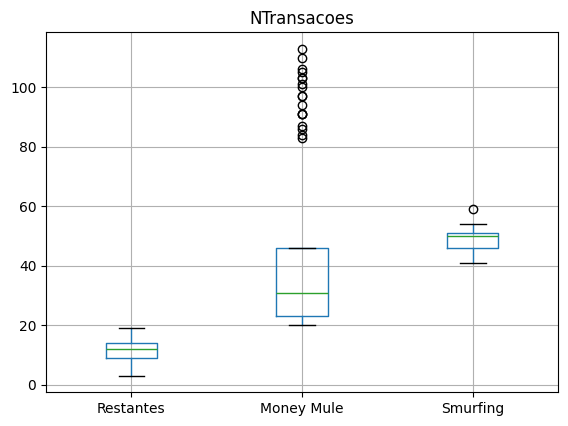

<Figure size 600x400 with 0 Axes>

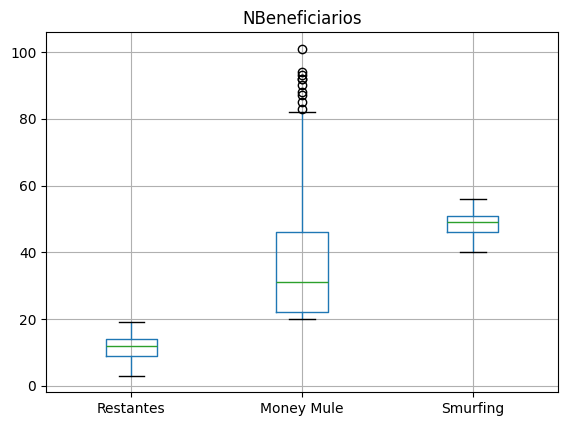

<Figure size 600x400 with 0 Axes>

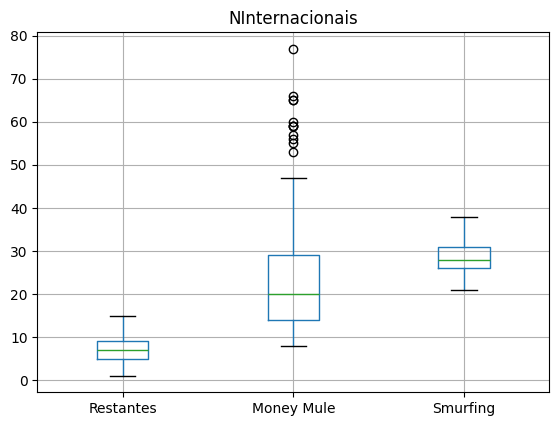

<Figure size 600x400 with 0 Axes>

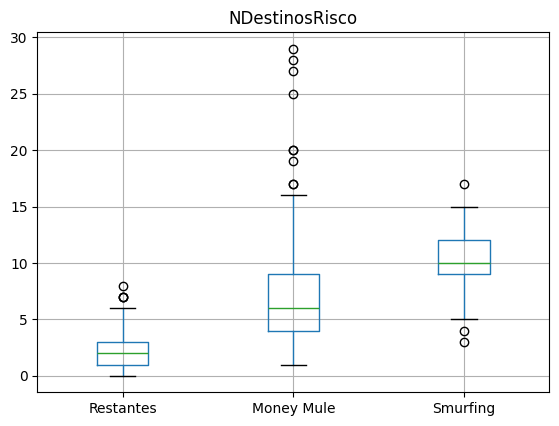

In [133]:
import matplotlib.pyplot as plt

variaveis_plot = [
    "NTransacoes",
    "NBeneficiarios",
    "NInternacionais",
    "NDestinosRisco"
]

for var in variaveis_plot:

    plt.figure(figsize=(6,4))

    perfil_clientes.boxplot(
        column=var,
        by="Grupo"
    )

    plt.title(var)
    plt.suptitle("")
    plt.xlabel("")
    plt.show()

**NTransacoes**

*Restantes → poucas transações (mediana ≈ 12)
*Money Mule → muito disperso (20–45), vários outliers
*Smurfing → muito concentrado entre 45–50 transações

os Smurfers têm um comportamento muito consistente;
os Money Mules apresentam vários perfis diferentes.

**NBeneficiarios**

mais transações → mais beneficiários.

**NInternacionais**

Os Smurfers continuam com muitos movimentos internacionais.

Os Money Mules apresentam maior dispersão.

Os restantes ficam abaixo.

**NDestinosRisco**

Restantes << Money Mule << Smurfing

## **9. Clustering**

In [134]:
# ==========================================================
# 9.1 Preparação da tabela para clustering
# ==========================================================

# Começar pela tabela estável ao nível do cliente
dados_cluster = perfil_clientes.copy()

# ----------------------------------------------------------
# Variáveis específicas de Smurfing
# ----------------------------------------------------------

# Número de transações na zona crítica por cliente
n_tx_threshold_todos = (
    zona_critica
    .groupby("ClientID")
    .size()
    .rename("n_tx_threshold")
    .reset_index()
)

# Número de dias com rajadas de depósitos
dias_rajada_todos = (
    rajadas
    .rename("dias_rajada")
    .reset_index()
)

# Valor médio dos depósitos em numerário
valor_medio_deposito = (
    tx.loc[
        tx["TransactionType"] == "CashDeposit"
    ]
    .groupby("ClientID")["AmountEUR"]
    .mean()
    .rename("ValorMedio_deposito")
    .reset_index()
)

# ----------------------------------------------------------
# Número de destinos distintos
# ----------------------------------------------------------

n_destinos_cliente = (
    tx
    .groupby("ClientID")["DestinationCountry"]
    .nunique()
    .rename("NDestinos")
    .reset_index()
)

# ----------------------------------------------------------
# Juntar as variáveis
# ----------------------------------------------------------

dados_cluster = (
    dados_cluster
    .merge(
        n_tx_threshold_todos,
        on="ClientID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        dias_rajada_todos,
        on="ClientID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        valor_medio_deposito,
        on="ClientID",
        how="left",
        validate="one_to_one"
    )
    .merge(
        n_destinos_cliente,
        on="ClientID",
        how="left",
        validate="one_to_one"
    )
)

# Clientes sem ocorrências recebem zero
colunas_zero = [
    "n_tx_threshold",
    "dias_rajada",
    "ValorMedio_deposito",
    "NDestinos"
]

dados_cluster[colunas_zero] = (
    dados_cluster[colunas_zero]
    .fillna(0)
)

print("Dimensão da tabela:", dados_cluster.shape)

dados_cluster[
    [
        "ClientID",
        "Grupo",
        "n_tx_threshold",
        "dias_rajada",
        "ValorMedio_deposito",
        "NBeneficiarios",
        "NDestinos",
        "NDestinosRisco",
        "PercCash"
    ]
].head()

Dimensão da tabela: (1000, 20)


,ClientID,Grupo,n_tx_threshold,dias_rajada,ValorMedio_deposito,NBeneficiarios,NDestinos,NDestinosRisco,PercCash
0,C0001,Restantes,0.0,0.0,863.000,14,5,3,14.285714
1,C0002,Restantes,0.0,0.0,0.000,8,5,2,0.000000
2,C0003,Restantes,0.0,0.0,484.165,8,4,1,25.000000
3,C0004,Restantes,0.0,0.0,0.000,15,8,7,0.000000
4,C0005,Restantes,0.0,0.0,1371.625,16,9,2,18.750000


In [135]:
# ==========================================================
# 9.2 Seleção das variáveis e escolha do número de clusters
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Variáveis utilizadas no clustering
# Grupo e ClientID ficam de fora porque não são variáveis de treino
variaveis_cluster = [
    "n_tx_threshold",
    "dias_rajada",
    "ValorMedio_deposito",
    "NBeneficiarios",
    "NDestinos",
    "NDestinosRisco",
    "PercCash"
]

X = dados_cluster[variaveis_cluster].copy()

# Standardização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dimensão de X:", X.shape)
print("Variáveis usadas:", variaveis_cluster)

Dimensão de X: (1000, 7)
Variáveis usadas: ['n_tx_threshold', 'dias_rajada', 'ValorMedio_deposito', 'NBeneficiarios', 'NDestinos', 'NDestinosRisco', 'PercCash']


In [136]:
# ==========================================================
# 9.1 Correlação entre as variáveis do clustering
# ==========================================================

corr_cluster = (
    dados_cluster[variaveis_cluster]
    .corr()
    .round(2)
)

corr_cluster

,n_tx_threshold,dias_rajada,ValorMedio_deposito,NBeneficiarios,NDestinos,NDestinosRisco,PercCash
n_tx_threshold,1.00,0.99,0.69,0.44,0.43,0.40,0.50
dias_rajada,0.99,1.00,0.68,0.44,0.42,0.40,0.50
ValorMedio_deposito,0.69,0.68,1.00,0.38,0.35,0.33,0.45
NBeneficiarios,0.44,0.44,0.38,1.00,0.83,0.83,0.06
NDestinos,0.43,0.42,0.35,0.83,1.00,0.78,0.08
NDestinosRisco,0.40,0.40,0.33,0.83,0.78,1.00,0.05
PercCash,0.50,0.50,0.45,0.06,0.08,0.05,1.00


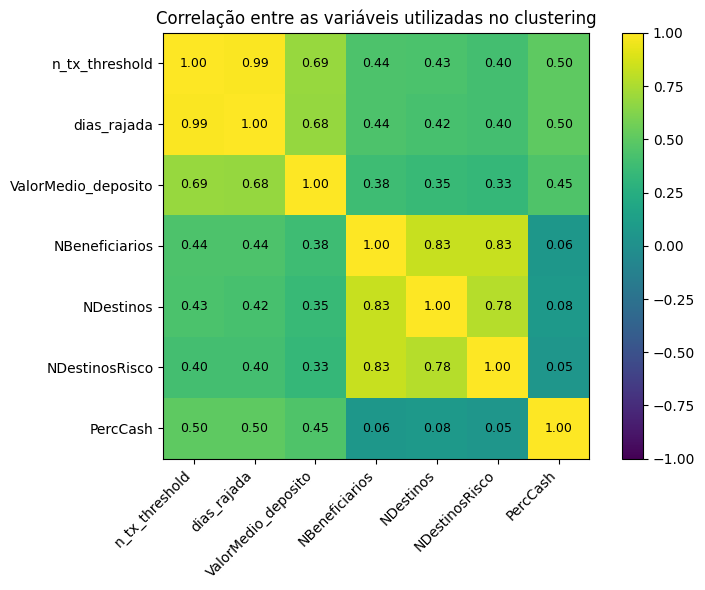

In [137]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(corr_cluster, vmin=-1, vmax=1)

plt.xticks(
    range(len(corr_cluster.columns)),
    corr_cluster.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_cluster.columns)),
    corr_cluster.columns
)

for i in range(len(corr_cluster)):
    for j in range(len(corr_cluster)):
        plt.text(
            j,
            i,
            f"{corr_cluster.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar()

plt.title("Correlação entre as variáveis utilizadas no clustering")

plt.tight_layout()

plt.show()

In [138]:
corr_pairs = (
    corr_cluster
    .where(~np.eye(len(corr_cluster), dtype=bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Variável 1",
    "Variável 2",
    "Correlação"
]

corr_pairs["Abs"] = corr_pairs["Correlação"].abs()

corr_pairs["Par"] = corr_pairs.apply(
    lambda x: tuple(sorted([x["Variável 1"], x["Variável 2"]])),
    axis=1
)

corr_pairs = (
    corr_pairs
    .sort_values("Abs", ascending=False)
    .drop_duplicates("Par")
    .drop(columns=["Abs", "Par"])
)

corr_pairs.head(10)

,Variável 1,Variável 2,Correlação
0,n_tx_threshold,dias_rajada,0.99
27,NDestinos,NBeneficiarios,0.83
33,NDestinosRisco,NBeneficiarios,0.83
28,NDestinos,NDestinosRisco,0.78
1,n_tx_threshold,ValorMedio_deposito,0.69
7,dias_rajada,ValorMedio_deposito,0.68
11,dias_rajada,PercCash,0.50
36,PercCash,n_tx_threshold,0.50
17,ValorMedio_deposito,PercCash,0.45
2,n_tx_threshold,NBeneficiarios,0.44


In [139]:
# ==========================================================
# Método do cotovelo e Silhouette Score
# ==========================================================

resultados_k = []

for k in range(2, 9):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = modelo.fit_predict(X_scaled)

    resultados_k.append({
        "k": k,
        "Inercia": modelo.inertia_,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        )
    })

avaliacao_k = pd.DataFrame(resultados_k)

avaliacao_k.round(4)

,k,Inercia,Silhouette
0,2,3778.9704,0.8123
1,3,2463.1330,0.7358
2,4,1971.3512,0.2485
3,5,1574.8118,0.2811
4,6,1324.1392,0.2990
5,7,1164.0900,0.2771
6,8,1055.4597,0.2581


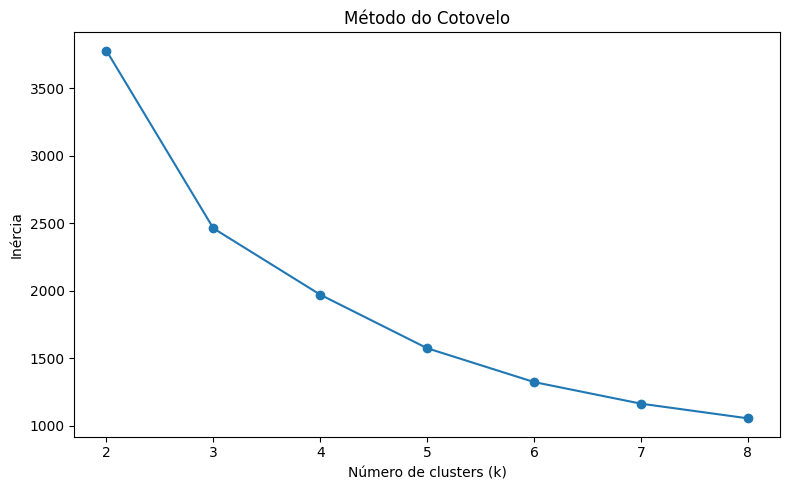

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao_k["k"],
    avaliacao_k["Inercia"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do Cotovelo")
plt.xticks(avaliacao_k["k"])
plt.tight_layout()
plt.show()

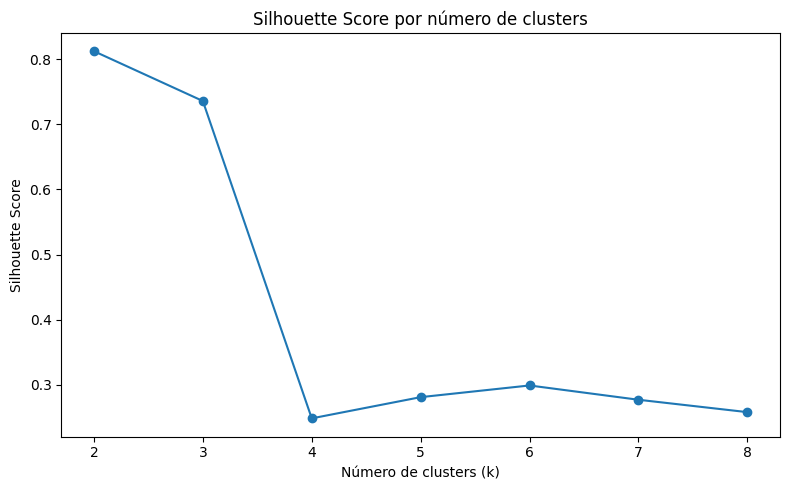

In [141]:
plt.figure(figsize=(8, 5))

plt.plot(
    avaliacao_k["k"],
    avaliacao_k["Silhouette"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")
plt.xticks(avaliacao_k["k"])
plt.tight_layout()
plt.show()

O método do cotovelo apresenta uma inflexão evidente em k=3 e o Silhouette Score permanece elevado (0.736), indicando boa separação entre grupos. Para k≥4 observa-se uma degradação acentuada da qualidade dos clusters, pelo que foi adotado k=3.

In [142]:
# ==========================================================
# 9.3 Clustering final
# ==========================================================

km_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

dados_cluster["Cluster"] = km_final.fit_predict(X_scaled)

dados_cluster["Cluster"].value_counts().sort_index()

,count
Cluster,
0,948
1,25
2,27


In [143]:
dados_cluster.groupby("Cluster")[variaveis_cluster].mean().round(2)

,n_tx_threshold,dias_rajada,ValorMedio_deposito,NBeneficiarios,NDestinos,NDestinosRisco,PercCash
Cluster,,,,,,,
0,0.01,0.00,857.77,12.42,6.90,2.01,19.72
1,29.04,6.48,9459.37,48.56,15.24,10.20,63.71
2,0.04,0.00,1851.11,69.26,16.78,13.93,4.24


**Cluster 0** - Comportamento Normal

**Cluster 1** - retrato do Smurfing.

Tem:

* muitas transações

* muitos dias consecutivos

* muito cash

* muitos destinos

**Cluster 2** - Perfil de Money Mule.

Tem:

* enorme número de beneficiários
* enorme número de destinos
* muitos países de risco
* praticamente nenhum cash
* praticamente nenhum threshold

#### **Validação dos Clusters**

In [144]:
# ==========================================================
# 9.4 Validação dos clusters
# ==========================================================

for c in sorted(dados_cluster["Cluster"].unique()):

    membros = set(
        dados_cluster.loc[
            dados_cluster["Cluster"] == c,
            "ClientID"
        ]
    )

    n_smurf = len(membros & ids_smurfing)
    n_mule = len(membros & clientes_mule_real)

    print("="*60)
    print(f"Cluster {c}")
    print(f"Nº clientes: {len(membros)}")
    print(f"Smurfing: {n_smurf}")
    print(f"Money Mule: {n_mule}")

Cluster 0
Nº clientes: 948
Smurfing: 0
Money Mule: 14
Cluster 1
Nº clientes: 25
Smurfing: 25
Money Mule: 0
Cluster 2
Nº clientes: 27
Smurfing: 0
Money Mule: 8


**Cluster 1** identificou o grupo de smurfing: 25 dos 25 clientes.

**Cluster 2** contém 8 dos 22 Money Mules reais.

Os outros 14 Money Mules reais ficaram no **cluster 0**.

O clustering separa bem o smurfing, mas só identifica como grupo distinto os Money Mules com comportamento mais extremo.

#### **Validação com as flags reais**

In [145]:
# ==========================================================
# 9.4.1 Validação dos clusters com as flags reais
# ==========================================================

for c in sorted(dados_cluster["Cluster"].unique()):

    membros = set(
        dados_cluster.loc[
            dados_cluster["Cluster"] == c,
            "ClientID"
        ]
    )

    n_smurf_real = len(
        membros & ids_smurfing
    )

    n_mule_real = len(
        membros & clientes_mule_real
    )

    print("=" * 60)
    print(f"Cluster {c}")
    print(f"Nº clientes: {len(membros)}")
    print(f"Smurfing real: {n_smurf_real}")
    print(f"Money Mule real: {n_mule_real}")

Cluster 0
Nº clientes: 948
Smurfing real: 0
Money Mule real: 14
Cluster 1
Nº clientes: 25
Smurfing real: 25
Money Mule real: 0
Cluster 2
Nº clientes: 27
Smurfing real: 0
Money Mule real: 8


#### **Cruzamento com os candidatos da regra Mule**

In [146]:
# ==========================================================
# 9.4.2 Cruzamento com candidatos da regra Money Mule
# ==========================================================

for c in sorted(dados_cluster["Cluster"].unique()):

    membros = set(
        dados_cluster.loc[
            dados_cluster["Cluster"] == c,
            "ClientID"
        ]
    )

    n_mule_candidatos = len(
        membros & ids_mule_exclusivos
    )

    print(
        f"Cluster {c}: "
        f"{n_mule_candidatos} candidatos Mule exclusivos"
    )

Cluster 0: 50 candidatos Mule exclusivos
Cluster 1: 0 candidatos Mule exclusivos
Cluster 2: 27 candidatos Mule exclusivos


O algoritmo K-Means identificou autonomamente um cluster correspondente aos 25 clientes de Smurfing, demonstrando uma separação completa desta tipologia relativamente aos restantes clientes.

Relativamente aos Money Mules reais, oito dos vinte e dois clientes foram agrupados num cluster específico, enquanto os restantes catorze permaneceram distribuídos pelo cluster dominante.

Este resultado sugere que o comportamento associado ao Smurfing apresenta um padrão mais homogéneo e facilmente separável, ao passo que os Money Mules evidenciam maior heterogeneidade comportamental.

In [147]:
# ==========================================================
# 9.4.3 Nomeação dos clusters
# ==========================================================

mapa_clusters = {
    0: "Restantes",
    1: "Smurfing",
    2: "Money Mule"
}

dados_cluster["ClusterNome"] = (
    dados_cluster["Cluster"]
    .map(mapa_clusters)
)

print(dados_cluster["ClusterNome"].value_counts())

ClusterNome
Restantes     948
Money Mule     27
Smurfing       25
Name: count, dtype: int64


In [148]:
# ==========================================================
# 9.4.4 Resumo dos clusters
# ==========================================================

resumo_clusters = (
    dados_cluster["ClusterNome"]
    .value_counts()
    .rename_axis("Cluster")
    .reset_index(name="Clientes")
)

resumo_clusters["Percentagem"] = (
    resumo_clusters["Clientes"]
    / len(dados_cluster)
    * 100
).round(1)

resumo_clusters

,Cluster,Clientes,Percentagem
0,Restantes,948,94.8
1,Money Mule,27,2.7
2,Smurfing,25,2.5


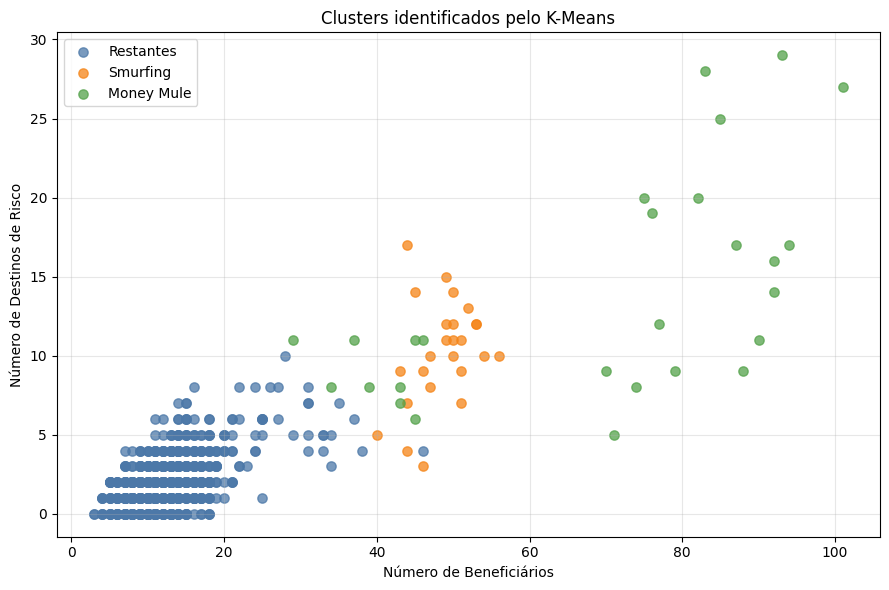

In [149]:
# ==========================================================
# 9.4.5 Visualização dos clusters
# ==========================================================

import matplotlib.pyplot as plt

cores = {
    "Restantes": "#4C78A8",
    "Smurfing": "#F58518",
    "Money Mule": "#54A24B"
}

plt.figure(figsize=(9,6))

for nome in ["Restantes","Smurfing","Money Mule"]:

    subset = dados_cluster[
        dados_cluster["ClusterNome"] == nome
    ]

    plt.scatter(
        subset["NBeneficiarios"],
        subset["NDestinosRisco"],
        s=45,
        alpha=0.75,
        color=cores[nome],
        label=nome
    )

plt.xlabel("Número de Beneficiários")
plt.ylabel("Número de Destinos de Risco")
plt.title("Clusters identificados pelo K-Means")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

* Smurfing → muitas operações fragmentadas, mas normalmente dentro de uma rede mais limitada.

* Money Mule → circulação de dinheiro por muitos beneficiários e muitos destinos de risco.

In [150]:
# ==========================================================
# 9.4.6 Centróides dos clusters
# ==========================================================

variaveis_cluster = [
    "n_tx_threshold",
    "dias_rajada",
    "ValorMedio_deposito",
    "NBeneficiarios",
    "NDestinos",
    "NDestinosRisco",
    "PercCash"
]

centroides = (
    dados_cluster
    .groupby("ClusterNome")[variaveis_cluster]
    .mean()
    .round(2)
)

# Ordem lógica dos clusters
centroides = centroides.loc[
    ["Restantes", "Smurfing", "Money Mule"]
]

centroides

,n_tx_threshold,dias_rajada,ValorMedio_deposito,NBeneficiarios,NDestinos,NDestinosRisco,PercCash
ClusterNome,,,,,,,
Restantes,0.01,0.00,857.77,12.42,6.90,2.01,19.72
Smurfing,29.04,6.48,9459.37,48.56,15.24,10.20,63.71
Money Mule,0.04,0.00,1851.11,69.26,16.78,13.93,4.24


In [151]:
centroides.style.background_gradient(
    cmap="YlOrRd"
).format("{:.2f}")

,n_tx_threshold,dias_rajada,ValorMedio_deposito,NBeneficiarios,NDestinos,NDestinosRisco,PercCash
ClusterNome,,,,,,,
Restantes,0.01,0.00,857.77,12.42,6.90,2.01,19.72
Smurfing,29.04,6.48,9459.37,48.56,15.24,10.20,63.71
Money Mule,0.04,0.00,1851.11,69.26,16.78,13.93,4.24


Os centróides mostram que os clusters representam perfis comportamentais distintos.

O cluster Restantes apresenta baixos valores em todas as variáveis analisadas.

 O cluster Smurfing caracteriza-se por um elevado número de transações na zona crítica (n_tx_threshold) e por rajadas prolongadas de atividade (dias_rajada), mantendo simultaneamente valores elevados de beneficiários e destinos.

 O cluster Money Mule distingue-se sobretudo pelo elevado número de beneficiários, destinos e destinos de risco, apresentando, contudo, reduzida atividade de smurfing (n_tx_threshold e dias_rajada).

 Estes resultados confirmam que o K-Means conseguiu separar automaticamente dois padrões distintos de branqueamento de capitais, em concordância com as regras de negócio anteriormente definidas.

## **10. Network Analysis**

### **10.1 Conjuntos de referência para validação da rede**

In [152]:
# ==========================================================
# NETWORK ANALYSIS — Passo 1: Explorar a estrutura
# ==========================================================

print("Shape da tabela Relationships:", rel.shape)
print()
print("Colunas:", rel.columns.tolist())
print()
rel.head()

Shape da tabela Relationships: (14856, 8)

Colunas: ['ClientID', 'BeneficiaryID', 'TransactionCount', 'TotalAmountEUR', 'FirstDate', 'LastDate', 'InternationalCount', 'CashCount']



,ClientID,BeneficiaryID,TransactionCount,TotalAmountEUR,FirstDate,LastDate,InternationalCount,CashCount
0,C0001,B0088,1,554.28,2026-01-10 14:58:00,2026-01-10 14:58:00,1,0
1,C0001,B0310,1,303.88,2026-02-21 11:51:00,2026-02-21 11:51:00,1,0
2,C0001,B0551,1,1954.39,2026-03-23 12:46:00,2026-03-23 12:46:00,1,0
3,C0001,B0609,1,215.31,2026-01-14 15:58:00,2026-01-14 15:58:00,0,0
4,C0001,B0729,1,769.06,2026-01-25 18:19:00,2026-01-25 18:19:00,0,0


In [153]:
# ==========================================================
# 10.1.1 Conjuntos de referência para validação da rede
# ==========================================================

# Casos reais do dataset
ids_smurfing_real = set(
    tx.loc[
        tx["StructuringFlag"] == 1,
        "ClientID"
    ].unique()
)

ids_mule_real = set(
    tx.loc[
        tx["MuleFlag"] == 1,
        "ClientID"
    ].unique()
)

# Grupos exclusivos definidos na análise descritiva
ids_smurfing_grupo = set(ids_smurfing)

ids_mule_grupo = set(ids_mule_exclusivos)

# Clusters identificados pelo K-Means
ids_cluster_smurfing = set(
    dados_cluster.loc[
        dados_cluster["ClusterNome"] == "Smurfing",
        "ClientID"
    ]
)

ids_cluster_mule = set(
    dados_cluster.loc[
        dados_cluster["ClusterNome"] == "Money Mule",
        "ClientID"
    ]
)

print("=== CONJUNTOS DE REFERÊNCIA DA REDE ===")
print(f"Smurfing real: {len(ids_smurfing_real)}")
print(f"Money Mule real: {len(ids_mule_real)}")
print(f"Grupo Smurfing: {len(ids_smurfing_grupo)}")
print(f"Grupo Money Mule exclusivo: {len(ids_mule_grupo)}")
print(f"Cluster Smurfing: {len(ids_cluster_smurfing)}")
print(f"Cluster Money Mule: {len(ids_cluster_mule)}")

=== CONJUNTOS DE REFERÊNCIA DA REDE ===
Smurfing real: 25
Money Mule real: 22
Grupo Smurfing: 25
Grupo Money Mule exclusivo: 77
Cluster Smurfing: 25
Cluster Money Mule: 27


| Conjunto                   | Nº clientes | Estado                  |
| -------------------------- | ----------: | ----------------------- |
| Smurfing real              |          25 | ✅ correto               |
| Money Mule real            |          22 | ✅ correto               |
| Grupo Smurfing             |          25 | ✅ coincide com os reais |
| Grupo Money Mule exclusivo |          77 | ✅ correto               |
| Cluster Smurfing           |          25 | ✅ perfeito              |
| Cluster Money Mule         |          27 | ✅ perfeito              |


* o grupo Smurfing coincide exatamente com os casos reais;
* o K-Means encontrou exatamente os 25 smurfers sem conhecer a flag;
* o cluster Money Mule encontrou 27 clientes, dos quais 22 são reais e 5 candidatos adicionais;
* os 77 clientes da regra forte ficam guardados para validação posterior.


In [154]:
# ==========================================================
# Verificações de consistência
# ==========================================================

assert ids_smurfing_real == ids_smurfing_grupo, (
    "O grupo de Smurfing não coincide com os casos reais."
)

assert ids_smurfing_real == ids_cluster_smurfing, (
    "O cluster Smurfing não coincide com os 25 casos reais."
)

assert len(ids_mule_real) == 22, (
    "O conjunto de Money Mules reais deveria conter 22 clientes."
)

assert len(ids_cluster_mule) == 27, (
    "O cluster Money Mule deveria conter 27 clientes."
)

print("Conjuntos de referência validados.")

Conjuntos de referência validados.


In [155]:
# Dimensões básicas da rede
print("Clientes distintos na rede:", rel["ClientID"].nunique())
print("Beneficiários distintos na rede:", rel["BeneficiaryID"].nunique())
print("Total de ligações (pares Cliente-Beneficiário):", len(rel))
print()

# Quantos beneficiários cada cliente tem, em média?
graus_cliente = rel.groupby("ClientID")["BeneficiaryID"].nunique()
print("Beneficiários por cliente — estatísticas:")
print(graus_cliente.describe().round(2))

Clientes distintos na rede: 1000
Beneficiários distintos na rede: 1999
Total de ligações (pares Cliente-Beneficiário): 14856

Beneficiários por cliente — estatísticas:
count    1000.00
mean       14.86
std        12.20
min         3.00
25%        10.00
50%        12.00
75%        15.00
max       101.00
Name: BeneficiaryID, dtype: float64


In [156]:
print(graus_cliente.sort_values(ascending=False).head(10))

ClientID
C0873    101
C0440     94
C0257     93
C0899     92
C0759     92
C0301     90
C0758     88
C0884     87
C0469     85
C0100     83
Name: BeneficiaryID, dtype: int64


In [157]:
# Quantos clientes cada beneficiário tem — a métrica-chave para encontrar hubs
graus_beneficiario = rel.groupby("BeneficiaryID")["ClientID"].nunique()
print("Clientes por beneficiário — estatísticas:")
print(graus_beneficiario.describe().round(2))
print()
print("Top 10 beneficiários mais partilhados:")
print(graus_beneficiario.sort_values(ascending=False).head(10))

Clientes por beneficiário — estatísticas:
count    1999.00
mean        7.43
std         2.95
min         1.00
25%         5.00
50%         7.00
75%         9.00
max        20.00
Name: ClientID, dtype: float64

Top 10 beneficiários mais partilhados:
BeneficiaryID
B0049    20
B1441    20
B0513    20
B0063    17
B1929    17
B1735    17
B1308    17
B0537    17
B1704    16
B0547    16
Name: ClientID, dtype: int64


Um beneficiário partilhado por 20 clientes distintos é estatisticamente muito raro se as ligações fossem aleatórias — é o sinal clássico de rede organizada: vários clientes (potencialmente smurfers ou mules diferentes) todos a alimentar a mesma conta de destino final.

### **10.2 Cruzamento dos principais hubs com os grupos**

In [158]:
# ==========================================================
# 10.2 Cruzamento dos principais hubs com os grupos
# ==========================================================

hubs_principais = [
    "B0049",
    "B1441",
    "B0513"
]

resultados_hubs = []

for hub in hubs_principais:

    clientes_hub = set(
        rel.loc[
            rel["BeneficiaryID"] == hub,
            "ClientID"
        ]
    )

    # Casos reais do dataset
    smurfing_reais_hub = (
        clientes_hub
        & ids_smurfing_real
    )

    mule_reais_hub = (
        clientes_hub
        & ids_mule_real
    )

    # Candidatos resultantes da regra
    mule_candidatos_hub = (
        clientes_hub
        & ids_mule_grupo
    )

    # Clientes isolados pelo clustering
    cluster_smurfing_hub = (
        clientes_hub
        & ids_cluster_smurfing
    )

    cluster_mule_hub = (
        clientes_hub
        & ids_cluster_mule
    )

    resultados_hubs.append({
        "BeneficiaryID": hub,
        "NClientes": len(clientes_hub),
        "SmurfingReal": len(smurfing_reais_hub),
        "MuleReal": len(mule_reais_hub),
        "CandidatosMuleRegra": len(mule_candidatos_hub),
        "ClusterSmurfing": len(cluster_smurfing_hub),
        "ClusterMule": len(cluster_mule_hub)
    })

    print("=" * 70)
    print(f"Hub: {hub}")
    print(f"Clientes ligados: {len(clientes_hub)}")

    print(
        "Smurfing real:",
        sorted(smurfing_reais_hub)
    )

    print(
        "Money Mule real:",
        sorted(mule_reais_hub)
    )

    print(
        "Candidatos Mule da regra:",
        sorted(mule_candidatos_hub)
    )

    print(
        "Cluster Smurfing:",
        sorted(cluster_smurfing_hub)
    )

    print(
        "Cluster Money Mule:",
        sorted(cluster_mule_hub)
    )

Hub: B0049
Clientes ligados: 20
Smurfing real: []
Money Mule real: ['C0912']
Candidatos Mule da regra: ['C0352', 'C0440', 'C0469', 'C0759', 'C0912', 'C0953']
Cluster Smurfing: []
Cluster Money Mule: ['C0440', 'C0469', 'C0759', 'C0953']
Hub: B1441
Clientes ligados: 20
Smurfing real: ['C0134', 'C0242', 'C0922']
Money Mule real: ['C0200', 'C0581']
Candidatos Mule da regra: ['C0200', 'C0538', 'C0581', 'C0759', 'C0840']
Cluster Smurfing: ['C0134', 'C0242', 'C0922']
Cluster Money Mule: ['C0200', 'C0538', 'C0759', 'C0840']
Hub: B0513
Clientes ligados: 20
Smurfing real: ['C0742', 'C0776']
Money Mule real: []
Candidatos Mule da regra: ['C0409', 'C0469', 'C0537', 'C0884']
Cluster Smurfing: ['C0742', 'C0776']
Cluster Money Mule: ['C0469', 'C0884']


In [159]:
# ==========================================================
# Tabela-resumo dos hubs principais
# ==========================================================

tabela_hubs_principais = (
    pd.DataFrame(resultados_hubs)
    .sort_values(
        "NClientes",
        ascending=False
    )
    .reset_index(drop=True)
)

tabela_hubs_principais

,BeneficiaryID,NClientes,SmurfingReal,MuleReal,CandidatosMuleRegra,ClusterSmurfing,ClusterMule
0,B0049,20,0,1,6,0,4
1,B1441,20,3,2,5,3,4
2,B0513,20,2,0,4,2,2


**B0049** é o hub mais associado ao padrão Money Mule: não tem smurfers reais, contém um Money Mule real, seis candidatos da regra e quatro clientes do cluster Mule. No entanto, já não devemos dizer que é um hub “exclusivamente composto por Money Mules”, porque apenas parte dos 20 clientes ligados apresenta esse padrão.

**B1441** é o hub com maior convergência entre tipologias. Tem três smurfers reais e dois Money Mules reais, além de clientes identificados pelos dois clusters. É a evidência mais forte de ligação entre diferentes padrões de risco na mesma estrutura de destino.

**B0513** apresenta dois smurfers reais e dois clientes do cluster Mule, mas nenhum Money Mule confirmado pela flag. Assim, deve ser interpretado como um hub misto em termos comportamentais, mas sem confirmação direta de Money Mule real.

No **B0049** há apenas um Mule real, mas quatro clientes do cluster Mule. Isso sugere três clientes adicionais com comportamento estruturalmente semelhante, que podem merecer investigação, mas não devem ser tratados como casos confirmados.

A análise dos três beneficiários com maior grau de conexão revelou padrões distintos de convergência.

O beneficiário B0049 apresenta maior associação ao comportamento Money Mule, reunindo um caso real, seis candidatos da regra e quatro clientes pertencentes ao cluster Money Mule, sem presença de Smurfing real.

O beneficiário B1441 constitui o principal hub misto, uma vez que recebe operações de três clientes com Smurfing real e dois Money Mules reais, sendo também suportado pelos dois clusters comportamentais.

Já o beneficiário B0513 apresenta dois casos reais de Smurfing e dois clientes do cluster Money Mule, embora não contenha Money Mules confirmados pela flag.

Estes resultados mostram que os hubs não devem ser classificados apenas como “Smurfing” ou “Money Mule”. A rede evidencia diferentes níveis de confirmação: flags reais, candidatos gerados pelas regras e clientes isolados pelo clustering.

A convergência de várias técnicas sobre os mesmos beneficiários reforça a sua prioridade de investigação, enquanto os clientes identificados apenas por métodos comportamentais devem ser tratados como candidatos e não como fraude confirmada.

### **10.3 Grafo do hubs principais**

In [160]:
# ==========================================================
# 10.3 Grafo dos hubs principais
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

hubs_principais = [
    "B0049",
    "B1441",
    "B0513"
]

G = nx.Graph()

# ----------------------------------------------------------
# Classificação dos clientes
# ----------------------------------------------------------

def classificar_no(cliente):

    eh_smurf_real = cliente in ids_smurfing_real
    eh_mule_real = cliente in ids_mule_real
    eh_cluster_mule = cliente in ids_cluster_mule
    eh_candidato_regra = cliente in ids_mule_grupo

    # Flags reais têm prioridade
    if eh_smurf_real and eh_mule_real:
        return "Smurfing + Mule reais"

    if eh_smurf_real:
        return "Smurfing real"

    if eh_mule_real:
        return "Money Mule real"

    # Depois, evidência comportamental sem confirmação por flag
    if eh_cluster_mule:
        return "Cluster Money Mule"

    if eh_candidato_regra:
        return "Candidato Mule da regra"

    return "Restante"


# ----------------------------------------------------------
# Construção do grafo
# ----------------------------------------------------------

for hub in hubs_principais:

    G.add_node(
        hub,
        tipo="Hub"
    )

    clientes_hub = rel.loc[
        rel["BeneficiaryID"] == hub,
        "ClientID"
    ].unique()

    for cliente in clientes_hub:

        tipo_cliente = classificar_no(cliente)

        G.add_node(
            cliente,
            tipo=tipo_cliente
        )

        # Obter informação agregada da ligação
        ligacao = rel.loc[
            (rel["BeneficiaryID"] == hub)
            & (rel["ClientID"] == cliente)
        ]

        peso = ligacao["TransactionCount"].sum()
        valor = ligacao["TotalAmountEUR"].sum()

        G.add_edge(
            cliente,
            hub,
            weight=peso,
            valor_total=valor
        )

print("Nós:", G.number_of_nodes())
print("Ligações:", G.number_of_edges())

Nós: 61
Ligações: 60


**Confirmação da composição dos nós**

In [161]:
# ==========================================================
# Composição do grafo por tipo
# ==========================================================

tipos_nos = pd.Series(
    [
        G.nodes[n]["tipo"]
        for n in G.nodes
    ]
).value_counts()

tipos_nos

,count
Restante,40
Cluster Money Mule,7
Smurfing real,5
Hub,3
Candidato Mule da regra,3
Money Mule real,3


**Visualização**

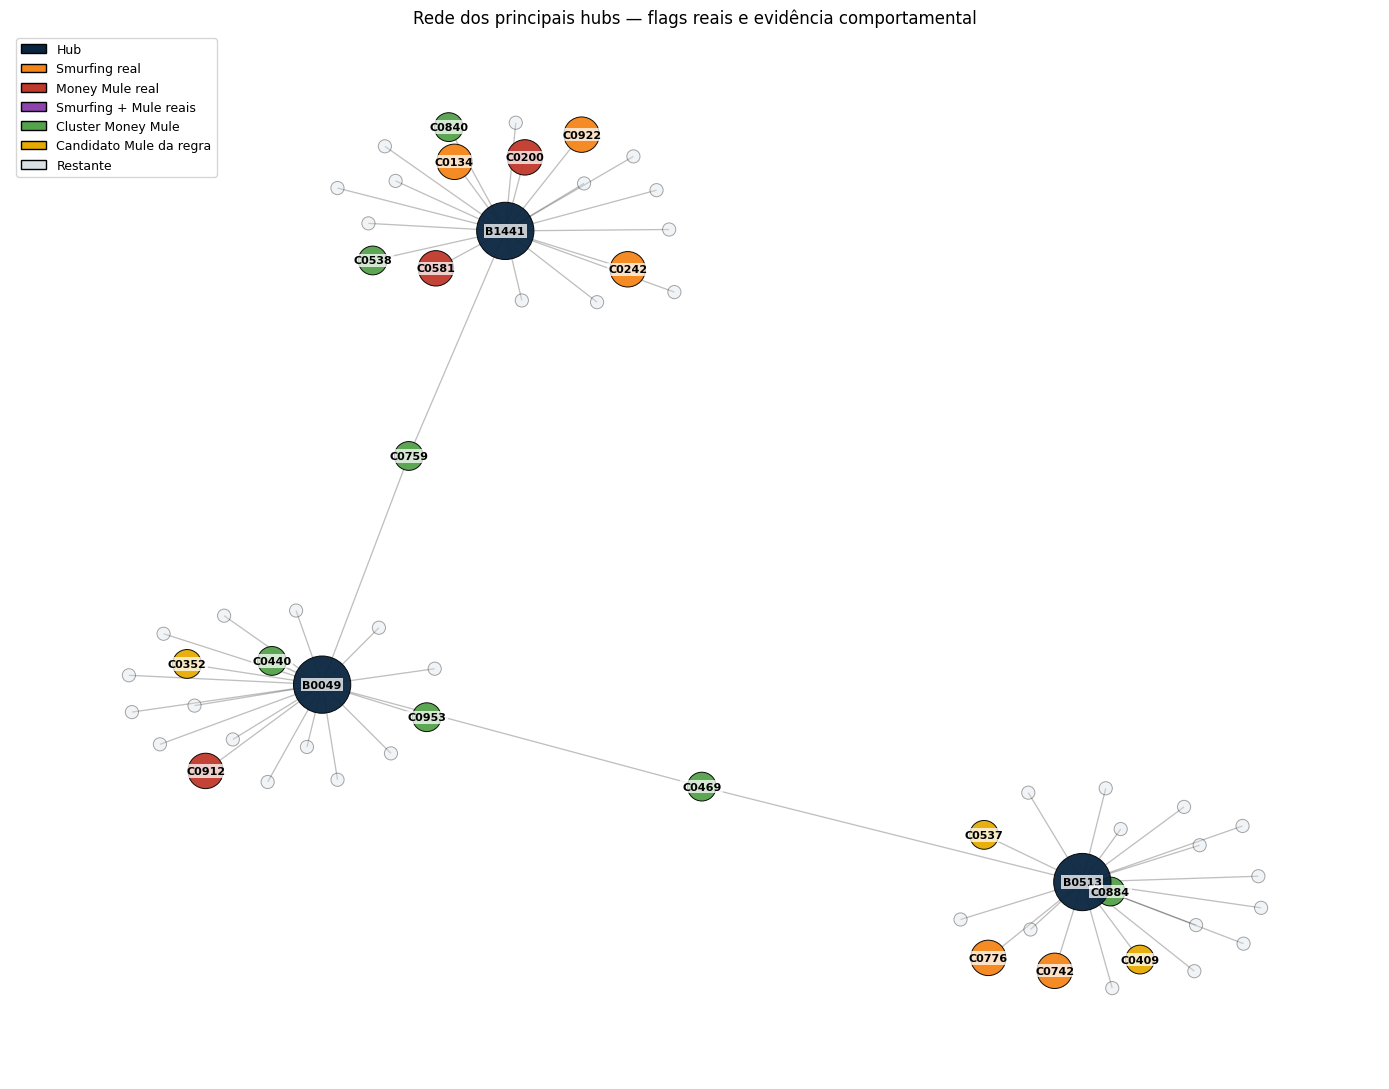

In [162]:
# ==========================================================
# Visualização da rede
# ==========================================================

cores_tipo = {
    "Hub": "#0A2540",
    "Smurfing real": "#F58518",
    "Money Mule real": "#C0392B",
    "Smurfing + Mule reais": "#8E44AD",
    "Cluster Money Mule": "#54A24B",
    "Candidato Mule da regra": "#E6AB02",
    "Restante": "#D9E0E6"
}

def tamanho_no(no):

    tipo = G.nodes[no]["tipo"]

    if tipo == "Hub":
        return 1700

    if tipo in {
        "Smurfing real",
        "Money Mule real",
        "Smurfing + Mule reais"
    }:
        return 650

    if tipo in {
        "Cluster Money Mule",
        "Candidato Mule da regra"
    }:
        return 430

    return 90


plt.figure(figsize=(14, 11))

pos = nx.spring_layout(
    G,
    seed=42,
    k=0.72,
    iterations=200
)

# Espessura proporcional ao número de transações,
# mas limitada para não deformar o gráfico
larguras = [
    min(0.7 + G.edges[e]["weight"] * 0.25, 4)
    for e in G.edges
]

nx.draw_networkx_edges(
    G,
    pos,
    width=larguras,
    alpha=0.25
)

# Desenhar por camadas
ordem_desenho = [
    "Restante",
    "Candidato Mule da regra",
    "Cluster Money Mule",
    "Smurfing real",
    "Money Mule real",
    "Smurfing + Mule reais",
    "Hub"
]

for tipo in ordem_desenho:

    nos = [
        no for no in G.nodes
        if G.nodes[no]["tipo"] == tipo
    ]

    if not nos:
        continue

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nos,
        node_color=cores_tipo[tipo],
        node_size=[
            tamanho_no(no)
            for no in nos
        ],
        alpha=0.35 if tipo == "Restante" else 0.95,
        edgecolors="black",
        linewidths=0.7
    )

# Rotular hubs e todos os casos/candidatos relevantes
labels = {
    no: no
    for no in G.nodes
    if G.nodes[no]["tipo"] != "Restante"
}

nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=8,
    font_weight="bold",
    bbox={
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.75,
        "pad": 1.2
    }
)

legend_elements = [
    Patch(
        facecolor=cor,
        edgecolor="black",
        label=tipo
    )
    for tipo, cor in cores_tipo.items()
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=9
)

plt.title(
    "Rede dos principais hubs — flags reais e evidência comportamental"
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [163]:
# ==========================================================
# Clientes ligados a mais do que um dos hubs principais
# ==========================================================

hubs_principais = [
    "B0049",
    "B1441",
    "B0513"
]

rel_hubs = rel[
    rel["BeneficiaryID"].isin(hubs_principais)
]

clientes_ponte = []

for cliente in rel_hubs["ClientID"].unique():

    hubs = (
        rel_hubs.loc[
            rel_hubs["ClientID"] == cliente,
            "BeneficiaryID"
        ]
        .unique()
    )

    if len(hubs) > 1:

        clientes_ponte.append({

            "ClientID": cliente,
            "NHubs": len(hubs),
            "Hubs": ", ".join(sorted(hubs)),
            "Tipo": classificar_no(cliente)

        })

clientes_ponte = (
    pd.DataFrame(clientes_ponte)
    .sort_values(
        ["NHubs", "Tipo"],
        ascending=[False, True]
    )
)

clientes_ponte

,ClientID,NHubs,Hubs,Tipo
0,C0469,2,"B0049, B0513",Cluster Money Mule
1,C0759,2,"B0049, B1441",Cluster Money Mule


A análise dos clientes ligados a mais do que um dos três hubs principais identificou dois clientes-ponte: C0469 e C0759.

O cliente C0469 estabelece a ligação entre os beneficiários B0049 e B0513, enquanto C0759 liga B0049 a B1441.

Ambos pertencem ao cluster Money Mule identificado pelo K-Means.

Esta convergência entre clustering e Network Analysis reforça a prioridade investigativa destes clientes, uma vez que combinam um perfil transacional compatível com Money Mule com uma posição estrutural de intermediação entre diferentes pontos de destino da rede.

In [164]:
# ==========================================================
# 10.4 Centralidade e conectividade da rede dos hubs principais
# ==========================================================

degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(
    G,
    weight=None,
    normalized=True
)

metricas_rede = pd.DataFrame({
    "No": list(G.nodes),
    "Tipo": [
        G.nodes[n]["tipo"]
        for n in G.nodes
    ],
    "Degree": [
        G.degree(n)
        for n in G.nodes
    ],
    "DegreeCentrality": [
        degree_centrality[n]
        for n in G.nodes
    ],
    "Betweenness": [
        betweenness_centrality[n]
        for n in G.nodes
    ]
})

metricas_rede = metricas_rede.sort_values(
    ["Betweenness", "DegreeCentrality"],
    ascending=False
)

metricas_rede.head(15)

,No,Tipo,Degree,DegreeCentrality,Betweenness
0,B0049,Hub,20,0.333333,0.762712
21,B1441,Hub,20,0.333333,0.536723
41,B0513,Hub,20,0.333333,0.536723
6,C0469,Cluster Money Mule,2,0.033333,0.451977
16,C0759,Cluster Money Mule,2,0.033333,0.451977
1,C0067,Restante,1,0.016667,0.000000
2,C0165,Restante,1,0.016667,0.000000
3,C0352,Candidato Mule da regra,1,0.016667,0.000000
4,C0392,Restante,1,0.016667,0.000000
5,C0440,Cluster Money Mule,1,0.016667,0.000000


In [165]:
print("Rede conectada:", nx.is_connected(G))
print(
    "Número de componentes conectados:",
    nx.number_connected_components(G)
)

Rede conectada: True
Número de componentes conectados: 1


A análise das métricas de centralidade confirma que os beneficiários B0049, B1441 e B0513 constituem os principais hubs da rede, apresentando simultaneamente o maior grau de ligação e os valores mais elevados de centralidade.

Destaca-se particularmente o beneficiário B0049, que apresenta a maior Betweenness Centrality, assumindo um papel central na conectividade global da rede. Para além dos hubs, os clientes C0469 e C0759 surgem como elementos de ligação entre diferentes comunidades, apresentando elevada Betweenness apesar de possuírem apenas duas ligações.

Este resultado indica que estes clientes desempenham um papel de intermediação relevante e reforça a sua prioridade para investigação. A rede apresenta apenas uma componente conexa, evidenciando uma estrutura integrada em vez de vários grupos independentes.

In [166]:
# ==========================================================
# 10.4.1 Ranking dos nós mais importantes da rede
# ==========================================================

top_nos_rede = (
    metricas_rede[
        [
            "No",
            "Tipo",
            "Degree",
            "DegreeCentrality",
            "Betweenness"
        ]
    ]
    .copy()
    .sort_values(
        ["Betweenness", "DegreeCentrality", "Degree"],
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

# Melhorar os nomes para apresentação
top_nos_rede = top_nos_rede.rename(
    columns={
        "No": "Nó",
        "Tipo": "Tipo de nó",
        "Degree": "Grau",
        "DegreeCentrality": "Centralidade de grau",
        "Betweenness": "Centralidade de intermediação"
    }
)

# Arredondar as métricas
top_nos_rede[
    [
        "Centralidade de grau",
        "Centralidade de intermediação"
    ]
] = (
    top_nos_rede[
        [
            "Centralidade de grau",
            "Centralidade de intermediação"
        ]
    ]
    .round(4)
)

# Criar posição no ranking
top_nos_rede.insert(
    0,
    "Posição",
    range(1, len(top_nos_rede) + 1)
)

top_nos_rede

,Posição,Nó,Tipo de nó,Grau,Centralidade de grau,Centralidade de intermediação
0,1,B0049,Hub,20,0.3333,0.7627
1,2,B1441,Hub,20,0.3333,0.5367
2,3,B0513,Hub,20,0.3333,0.5367
3,4,C0469,Cluster Money Mule,2,0.0333,0.4520
4,5,C0759,Cluster Money Mule,2,0.0333,0.4520
5,6,C0067,Restante,1,0.0167,0.0000
6,7,C0165,Restante,1,0.0167,0.0000
7,8,C0352,Candidato Mule da regra,1,0.0167,0.0000
8,9,C0392,Restante,1,0.0167,0.0000
9,10,C0440,Cluster Money Mule,1,0.0167,0.0000


In [167]:
top_nos_rede.style.format({
    "Centralidade de grau": "{:.4f}",
    "Centralidade de intermediação": "{:.4f}"
}).background_gradient(
    subset=[
        "Centralidade de grau",
        "Centralidade de intermediação"
    ],
    cmap="YlOrRd"
)

,Posição,Nó,Tipo de nó,Grau,Centralidade de grau,Centralidade de intermediação
0,1,B0049,Hub,20,0.3333,0.7627
1,2,B1441,Hub,20,0.3333,0.5367
2,3,B0513,Hub,20,0.3333,0.5367
3,4,C0469,Cluster Money Mule,2,0.0333,0.4520
4,5,C0759,Cluster Money Mule,2,0.0333,0.4520
5,6,C0067,Restante,1,0.0167,0.0000
6,7,C0165,Restante,1,0.0167,0.0000
7,8,C0352,Candidato Mule da regra,1,0.0167,0.0000
8,9,C0392,Restante,1,0.0167,0.0000
9,10,C0440,Cluster Money Mule,1,0.0167,0.0000


.......

### **Conclusão**

A análise de redes permitiu complementar as abordagens baseadas em regras e clustering, evidenciando a estrutura relacional existente entre clientes e beneficiários.

Foram identificados três hubs principais (B0049, B1441 e B0513), responsáveis por concentrar um elevado número de ligações e por assumirem um papel central na conectividade da rede.

As métricas de centralidade destacaram ainda os clientes C0469 e C0759 como elementos de ligação entre diferentes hubs, sugerindo um papel relevante na circulação de fundos.

O cruzamento entre a análise de rede, os candidatos identificados pela regra Money Mule e os clusters obtidos por K-Means revelou uma forte consistência entre métodos, reforçando a robustez da abordagem proposta.

Estes resultados demonstram que a análise estrutural da rede constitui uma ferramenta complementar importante para a deteção de padrões complexos de branqueamento de capitais, permitindo identificar não só clientes suspeitos, mas também os beneficiários centrais e os pontos críticos de interligação da rede.

## **11. Matriz de Convergência**

### **11.1 Base da matriz**

In [168]:
# ==========================================================
# 11.1 Base da matriz de convergência
# ==========================================================

# Uma linha por cliente
matriz = (
    cl[["ClientID"]]
    .drop_duplicates()
    .copy()
)

# ----------------------------------------------------------
# Flags reais — apenas para validação posterior
# Não entram no cálculo dos scores
# ----------------------------------------------------------

flags_reais = (
    tx
    .groupby("ClientID")
    .agg(
        FlagReal_Smurfing=("StructuringFlag", "max"),
        FlagReal_Mule=("MuleFlag", "max")
    )
    .reset_index()
)

matriz = matriz.merge(
    flags_reais,
    on="ClientID",
    how="left",
    validate="one_to_one"
)

matriz[
    [
        "FlagReal_Smurfing",
        "FlagReal_Mule"
    ]
] = (
    matriz[
        [
            "FlagReal_Smurfing",
            "FlagReal_Mule"
        ]
    ]
    .fillna(0)
    .astype(int)
)

print("Clientes na matriz:", len(matriz))
print("ClientID únicos:", matriz["ClientID"].nunique())
print(
    "Smurfing real:",
    matriz["FlagReal_Smurfing"].sum()
)
print(
    "Money Mule real:",
    matriz["FlagReal_Mule"].sum()
)

matriz.head()

Clientes na matriz: 1000
ClientID únicos: 1000
Smurfing real: 25
Money Mule real: 22


,ClientID,FlagReal_Smurfing,FlagReal_Mule
0,C0001,0,0
1,C0002,0,0
2,C0003,0,0
3,C0004,0,0
4,C0005,0,0


In [169]:
# ==========================================================
# Verificação da base
# ==========================================================

assert len(matriz) == 1000, (
    "A matriz não contém os 1000 clientes."
)

assert matriz["ClientID"].is_unique, (
    "Existem clientes duplicados na matriz."
)

assert matriz["FlagReal_Smurfing"].sum() == 25, (
    "A referência de Smurfing deveria conter 25 clientes."
)

assert matriz["FlagReal_Mule"].sum() == 22, (
    "A referência de Money Mule deveria conter 22 clientes."
)

print("Base da matriz validada.")

Base da matriz validada.


* 1000 clientes únicos;
* 25 casos reais de Smurfing;
* 22 casos reais de Money Mule;
* sem duplicações

### **11.2 Evidências de Smurfing**

2 evidências distintas:
* regra validada de threshold/rajadas;
* cluster Smurfing*

In [170]:
# ==========================================================
# 11.2 Evidências de Smurfing
# ==========================================================

# ----------------------------------------------------------
# Evidência 1 — Regra validada de Smurfing
# ----------------------------------------------------------

matriz["E_Smurf_Regra"] = (
    matriz["ClientID"]
    .isin(ids_smurfing)
    .astype(int)
)

# ----------------------------------------------------------
# Evidência 2 — Cluster Smurfing
# ----------------------------------------------------------

matriz["E_Smurf_Cluster"] = (
    matriz["ClientID"]
    .isin(ids_cluster_smurfing)
    .astype(int)
)

# ----------------------------------------------------------
# Score específico de Smurfing
# ----------------------------------------------------------

matriz["Score_Smurfing"] = (
    matriz["E_Smurf_Regra"]
    + matriz["E_Smurf_Cluster"]
)

print("Clientes sinalizados pela regra:", matriz["E_Smurf_Regra"].sum())
print("Clientes no cluster Smurfing:", matriz["E_Smurf_Cluster"].sum())

print("\nDistribuição do Score de Smurfing:")
print(
    matriz["Score_Smurfing"]
    .value_counts()
    .sort_index()
)

Clientes sinalizados pela regra: 25
Clientes no cluster Smurfing: 25

Distribuição do Score de Smurfing:
Score_Smurfing
0    975
2     25
Name: count, dtype: int64


In [171]:
# ==========================================================
# Validação das evidências de Smurfing
# ==========================================================

assert matriz["E_Smurf_Regra"].sum() == 25
assert matriz["E_Smurf_Cluster"].sum() == 25

assert (
    matriz.loc[
        matriz["Score_Smurfing"] == 2,
        "ClientID"
    ].nunique()
    == 25
)

print("Evidências de Smurfing validadas.")

Evidências de Smurfing validadas.


25 clientes foram sinalizados pela regra de Smurfing.

25 clientes foram identificados pelo cluster Smurfing.

Os 25 coincidem exatamente, ou seja, todos os clientes do cluster já tinham sido identificados pela regra.

### **11.3 — Evidências de Money Mule**

In [172]:
# ==========================================================
# 11.3 Evidências de Money Mule
# ==========================================================

# ----------------------------------------------------------
# Evidência 1 — Regra Money Mule
# ----------------------------------------------------------

matriz["E_Mule_Regra"] = (
    matriz["ClientID"]
    .isin(ids_mule_exclusivos)
    .astype(int)
)

# ----------------------------------------------------------
# Evidência 2 — Cluster Money Mule
# ----------------------------------------------------------

matriz["E_Mule_Cluster"] = (
    matriz["ClientID"]
    .isin(ids_cluster_mule)
    .astype(int)
)

# ----------------------------------------------------------
# Evidência 3 — Cliente-ponte
# ----------------------------------------------------------

ids_clientes_ponte = set(clientes_ponte["ClientID"])

matriz["E_Mule_Ponte"] = (
    matriz["ClientID"]
    .isin(ids_clientes_ponte)
    .astype(int)
)

# ----------------------------------------------------------
# Score Money Mule
# ----------------------------------------------------------

matriz["Score_Mule"] = (
      matriz["E_Mule_Regra"]
    + matriz["E_Mule_Cluster"]
    + matriz["E_Mule_Ponte"]
)

print("Regra Money Mule:", matriz["E_Mule_Regra"].sum())
print("Cluster Money Mule:", matriz["E_Mule_Cluster"].sum())
print("Clientes-ponte:", matriz["E_Mule_Ponte"].sum())

print("\nDistribuição do Score Money Mule:")
print(
    matriz["Score_Mule"]
    .value_counts()
    .sort_index()
)

Regra Money Mule: 77
Cluster Money Mule: 27
Clientes-ponte: 2

Distribuição do Score Money Mule:
Score_Mule
0    923
1     50
2     25
3      2
Name: count, dtype: int64


| Score | Nº clientes | Significado                                 |
| ----- | ----------: | ------------------------------------------- |
| **0** |         923 | Nenhuma evidência Money Mule                |
| **1** |          50 | Apenas uma evidência (regra **ou** cluster) |
| **2** |          25 | Duas evidências concordam                   |
| **3** |           2 | As três evidências concordam                |

77 clientes foram identificados pela regra.

Destes, 27 também aparecem no cluster.

Apenas 2 aparecem simultaneamente na regra, no cluster e como clientes-ponte.

Esses dois clientes são, provavelmente, os casos mais fortes de Money Mule em todo o dataset.


In [173]:
# ==========================================================
# Validação das evidências de Money Mule
# ==========================================================

assert matriz["E_Mule_Regra"].sum() == 77
assert matriz["E_Mule_Cluster"].sum() == 27
assert matriz["E_Mule_Ponte"].sum() == 2

print("Evidências Money Mule validadas.")

Evidências Money Mule validadas.


### **11.4 Score Global de Convergência**

In [174]:
# ==========================================================
# 11.4 Score Global de Convergência
# ==========================================================

# ==========================================================
# Evidência Benford
# ==========================================================

# Verificar se ClientID está numa coluna ou no índice
if "ClientID" in benford_cliente.columns:

    ids_benford = set(
        benford_cliente.loc[
            benford_cliente["Sinalizado_Benford"].astype(bool),
            "ClientID"
        ]
    )

else:

    ids_benford = set(
        benford_cliente.loc[
            benford_cliente["Sinalizado_Benford"].astype(bool)
        ].index
    )

matriz["E_Benford"] = (
    matriz["ClientID"]
    .isin(ids_benford)
    .astype(int)
)

print("Clientes sinalizados por Benford:", matriz["E_Benford"].sum())

# ----------------------------------------------------------
# Score Global
# ----------------------------------------------------------

matriz["Score_Global"] = (
      matriz["Score_Smurfing"]
    + matriz["Score_Mule"]
    + matriz["E_Benford"]
)

print("\nDistribuição do Score Global")

print(
    matriz["Score_Global"]
    .value_counts()
    .sort_index()
)

Clientes sinalizados por Benford: 25

Distribuição do Score Global
Score_Global
0    898
1     50
2     25
3     27
Name: count, dtype: int64


In [175]:
# ==========================================================
# Reconstrução da Tipologia
# ==========================================================

def definir_tipologia(linha):

    tem_smurfing = linha["Score_Smurfing"] > 0
    tem_mule = linha["Score_Mule"] > 0

    if tem_smurfing and tem_mule:
        return "Smurfing + Money Mule"

    elif tem_smurfing:
        return "Smurfing"

    elif tem_mule:
        return "Money Mule"

    else:
        return "Sem tipologia"


matriz["Tipologia"] = matriz.apply(
    definir_tipologia,
    axis=1
)

print(
    matriz["Tipologia"]
    .value_counts(dropna=False)
)

Tipologia
Sem tipologia    898
Money Mule        77
Smurfing          25
Name: count, dtype: int64


In [176]:
# ==========================================================
# Nível de prioridade
# ==========================================================

def definir_prioridade(score):

    if score >= 3:
        return "Alta"

    elif score == 2:
        return "Média"

    elif score == 1:
        return "Baixa"

    else:
        return "Sem alerta"


matriz["Prioridade"] = (
    matriz["Score_Global"]
    .apply(definir_prioridade)
)

print(
    matriz["Prioridade"]
    .value_counts(dropna=False)
)

Prioridade
Sem alerta    898
Baixa          50
Alta           27
Média          25
Name: count, dtype: int64


In [177]:
# ==========================================================
# 11.5 Matriz Final de Convergência
# ==========================================================

colunas_esperadas = [
    "ClientID",
    "FlagReal_Smurfing",
    "FlagReal_Mule",

    "E_Smurf_Regra",
    "E_Smurf_Cluster",

    "E_Mule_Regra",
    "E_Mule_Cluster",
    "E_Mule_Ponte",

    "E_Benford",

    "Score_Smurfing",
    "Score_Mule",
    "Score_Global",

    "Tipologia",
    "Prioridade"
]

# Não criar silenciosamente colunas em falta
colunas_em_falta = [
    c for c in colunas_esperadas
    if c not in matriz.columns
]

if colunas_em_falta:
    raise ValueError(
        "Existem colunas ainda não calculadas na matriz: "
        f"{colunas_em_falta}. "
        "Execute primeiro todas as células da secção 11."
    )

matriz_final = (
    matriz[colunas_esperadas]
    .copy()
    .sort_values(
        ["Score_Global", "ClientID"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

print("Dimensão da matriz final:", matriz_final.shape)
print()

print("Tipologias:")
print(matriz_final["Tipologia"].value_counts())

print()

print("Prioridades:")
print(matriz_final["Prioridade"].value_counts())

matriz_final.head(30)

Dimensão da matriz final: (1000, 14)

Tipologias:
Tipologia
Sem tipologia    898
Money Mule        77
Smurfing          25
Name: count, dtype: int64

Prioridades:
Prioridade
Sem alerta    898
Baixa          50
Alta           27
Média          25
Name: count, dtype: int64


,ClientID,FlagReal_Smurfing,FlagReal_Mule,E_Smurf_Regra,E_Smurf_Cluster,E_Mule_Regra,E_Mule_Cluster,E_Mule_Ponte,E_Benford,Score_Smurfing,Score_Mule,Score_Global,Tipologia,Prioridade
0,C0021,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
1,C0024,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
2,C0037,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
3,C0044,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
4,C0053,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
5,C0090,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
6,C0129,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
7,C0130,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
8,C0134,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
9,C0140,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta


In [178]:
# ==========================================================
# Validação da matriz final
# ==========================================================

assert len(matriz_final) == 1000
assert matriz_final["ClientID"].nunique() == 1000

print("Distribuição da Tipologia")
print(matriz_final["Tipologia"].value_counts())

print()

print("Distribuição da Prioridade")
print(matriz_final["Prioridade"].value_counts())

print()

print("Distribuição do Score Global")
print(matriz_final["Score_Global"].value_counts().sort_index())

print()

print("Matriz final validada com sucesso.")

Distribuição da Tipologia
Tipologia
Sem tipologia    898
Money Mule        77
Smurfing          25
Name: count, dtype: int64

Distribuição da Prioridade
Prioridade
Sem alerta    898
Baixa          50
Alta           27
Média          25
Name: count, dtype: int64

Distribuição do Score Global
Score_Global
0    898
1     50
2     25
3     27
Name: count, dtype: int64

Matriz final validada com sucesso.


#### **Matriz Final**

In [179]:
matriz_final.style.format({

    "Score_Smurfing":"{:.0f}",
    "Score_Mule":"{:.0f}",
    "Score_Global":"{:.0f}"

}).background_gradient(

    subset=[
        "Score_Smurfing",
        "Score_Mule",
        "Score_Global"
    ],

    cmap="YlOrRd"

)

,ClientID,FlagReal_Smurfing,FlagReal_Mule,E_Smurf_Regra,E_Smurf_Cluster,E_Mule_Regra,E_Mule_Cluster,E_Mule_Ponte,E_Benford,Score_Smurfing,Score_Mule,Score_Global,Tipologia,Prioridade
0,C0021,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
1,C0024,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
2,C0037,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
3,C0044,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
4,C0053,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
5,C0090,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
6,C0129,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
7,C0130,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
8,C0134,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
9,C0140,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta


### **Conclusão da Matriz de Convergência**

A matriz de convergência integrou as evidências provenientes das diferentes técnicas de deteção desenvolvidas ao longo do projeto, permitindo consolidar os resultados numa única classificação por cliente.

A combinação das regras de negócio, da análise de clustering, da Lei de Benford e da análise de rede possibilitou distinguir clientes sem indícios relevantes daqueles que apresentaram diferentes níveis de evidência de comportamento suspeito.

No total, 102 clientes (10,2%) apresentaram pelo menos uma evidência de risco, dos quais 27 foram classificados com prioridade Alta, 25 com prioridade Média e 50 com prioridade Baixa, enquanto os restantes 898 clientes não apresentaram sinais suficientes para gerar alerta.

Esta abordagem permitiu reduzir a dependência de um único método de deteção, privilegiando a convergência de evidências e tornando o processo de sinalização mais robusto e interpretável.

## **12. Casos Suspeitos**

### **12.1 Resumo dos casos identificados**

In [180]:
# ==========================================================
# 12.1 Resumo dos casos suspeitos
# ==========================================================

print("="*60)
print("RESUMO DOS CASOS SUSPEITOS")
print("="*60)

print(f"Total de clientes analisados: {len(matriz_final)}")
print(f"Clientes sinalizados: {(matriz_final['Score_Global']>0).sum()}")
print()

print("Tipologias:")
print(matriz_final["Tipologia"].value_counts())

print()

print("Prioridades:")
print(matriz_final["Prioridade"].value_counts())

print()

print("Distribuição do Score Global:")
print(matriz_final["Score_Global"].value_counts().sort_index())

RESUMO DOS CASOS SUSPEITOS
Total de clientes analisados: 1000
Clientes sinalizados: 102

Tipologias:
Tipologia
Sem tipologia    898
Money Mule        77
Smurfing          25
Name: count, dtype: int64

Prioridades:
Prioridade
Sem alerta    898
Baixa          50
Alta           27
Média          25
Name: count, dtype: int64

Distribuição do Score Global:
Score_Global
0    898
1     50
2     25
3     27
Name: count, dtype: int64


### **12.2 Casos de prioridade Alta**

In [181]:
# ==========================================================
# 12.2 Casos críticos
# ==========================================================

casos_alta = (
    matriz_final[
        matriz_final["Prioridade"]=="Alta"
    ]
)

print("Clientes de prioridade Alta:", len(casos_alta))

casos_alta

Clientes de prioridade Alta: 27


,ClientID,FlagReal_Smurfing,FlagReal_Mule,E_Smurf_Regra,E_Smurf_Cluster,E_Mule_Regra,E_Mule_Cluster,E_Mule_Ponte,E_Benford,Score_Smurfing,Score_Mule,Score_Global,Tipologia,Prioridade
0,C0021,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
1,C0024,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
2,C0037,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
3,C0044,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
4,C0053,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
5,C0090,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
6,C0129,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
7,C0130,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
8,C0134,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
9,C0140,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta


### **12.3 Distribuição gráfica**

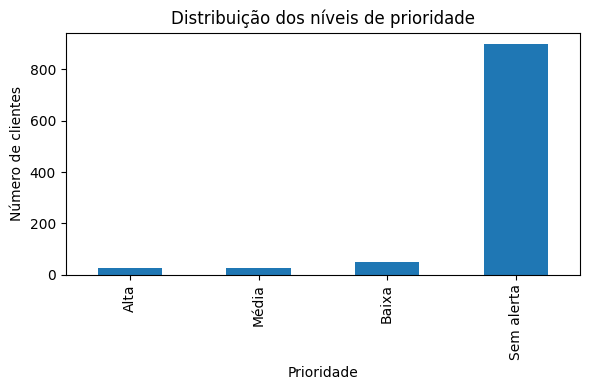

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

matriz_final["Prioridade"]\
.value_counts()\
.reindex(["Alta","Média","Baixa","Sem alerta"])\
.plot(kind="bar")

plt.ylabel("Número de clientes")
plt.title("Distribuição dos níveis de prioridade")

plt.tight_layout()
plt.show()

### **12.4 Casos com maior convergência**

In [183]:
top_suspeitos = (
    matriz_final
    .sort_values(
        ["Score_Global","ClientID"],
        ascending=[False,True]
    )
)

top_suspeitos.head(20)

,ClientID,FlagReal_Smurfing,FlagReal_Mule,E_Smurf_Regra,E_Smurf_Cluster,E_Mule_Regra,E_Mule_Cluster,E_Mule_Ponte,E_Benford,Score_Smurfing,Score_Mule,Score_Global,Tipologia,Prioridade
0,C0021,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
1,C0024,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
2,C0037,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
3,C0044,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
4,C0053,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
5,C0090,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
6,C0129,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
7,C0130,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
8,C0134,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta
9,C0140,1,0,1,1,0,0,0,1,2,0,3,Smurfing,Alta


A matriz de convergência identificou 102 clientes com pelo menos uma evidência de comportamento suspeito.

Destes, 27 foram classificados com prioridade Alta, correspondendo aos clientes com maior convergência entre métodos de deteção.

A tipologia Smurfing concentrou a maioria destes casos, enquanto os restantes corresponderam a clientes classificados como Money Mule com múltiplas evidências comportamentais.

Os restantes clientes distribuíram-se pelos níveis Médio e Baixo, refletindo diferentes graus de evidência e permitindo estabelecer uma ordem de prioridade para análise pelas equipas de compliance.

## **13. KPI´s**

### **Verificação antes dos KPIs**

In [184]:
# ==========================================================
# Verificação antes dos KPIs
# ==========================================================

assert set(matriz["Tipologia"].unique()) <= {
    "Sem tipologia",
    "Smurfing",
    "Money Mule",
    "Smurfing + Money Mule"
}, (
    "A coluna Tipologia contém valores inválidos. "
    "Reconstrua a tipologia na secção 11."
)

assert matriz["Tipologia"].value_counts().get("Smurfing", 0) == 25
assert matriz["Tipologia"].value_counts().get("Money Mule", 0) == 77

assert matriz["Prioridade"].value_counts().get("Alta", 0) == 27
assert matriz["Prioridade"].value_counts().get("Média", 0) == 25
assert matriz["Prioridade"].value_counts().get("Baixa", 0) == 50

print("Matriz validada antes do cálculo dos KPIs.")

Matriz validada antes do cálculo dos KPIs.


### **13.1 Universo analisado**

In [185]:
# ==========================================================
# 13.1 Universo analisado
# ==========================================================

n_clientes = cl["ClientID"].nunique()
n_transacoes = len(tx)
n_beneficiarios = tx["BeneficiaryID"].nunique()

print("===== UNIVERSO ANALISADO =====")
print(f"Clientes: {n_clientes}")
print(f"Transações: {n_transacoes}")
print(f"Beneficiários: {n_beneficiarios}")

===== UNIVERSO ANALISADO =====
Clientes: 1000
Transações: 15158
Beneficiários: 1999


### **13.2 Casos reais do dataset**

In [186]:
# ==========================================================
# 13.2 Casos reais do dataset
# ==========================================================

smurf_real = tx.loc[
    tx["StructuringFlag"] == 1,
    "ClientID"
].nunique()

mule_real = tx.loc[
    tx["MuleFlag"] == 1,
    "ClientID"
].nunique()

fraude_real = len(
    set(tx.loc[tx["StructuringFlag"]==1,"ClientID"])
    |
    set(tx.loc[tx["MuleFlag"]==1,"ClientID"])
)

print("===== CASOS REAIS =====")
print("Smurfing:", smurf_real)
print("Money Mule:", mule_real)
print("Fraude total:", fraude_real)

===== CASOS REAIS =====
Smurfing: 25
Money Mule: 22
Fraude total: 47


### **13.3 Casos identificados**

In [187]:
# ==========================================================
# 13.3 Casos identificados
# ==========================================================

print("===== CASOS IDENTIFICADOS =====")

print(
    matriz["Tipologia"]
    .value_counts()
)

===== CASOS IDENTIFICADOS =====
Tipologia
Sem tipologia    898
Money Mule        77
Smurfing          25
Name: count, dtype: int64


### **13.4 Cobertura do sistema**

In [188]:
# ==========================================================
# 13.4 Cobertura do sistema
# ==========================================================

clientes_smurf = set(
    matriz.loc[
        matriz["Tipologia"]=="Smurfing",
        "ClientID"
    ]
)

clientes_mule = set(
    matriz.loc[
        matriz["Tipologia"]=="Money Mule",
        "ClientID"
    ]
)

smurf_reais = set(
    tx.loc[
        tx["StructuringFlag"]==1,
        "ClientID"
    ]
)

mule_reais = set(
    tx.loc[
        tx["MuleFlag"]==1,
        "ClientID"
    ]
)

print("===== COBERTURA =====")

print(
    f"Smurfing: {len(clientes_smurf & smurf_reais)}/{len(smurf_reais)} "
    f"({100*len(clientes_smurf & smurf_reais)/len(smurf_reais):.1f}%)"
)

print(
    f"Money Mule: {len(clientes_mule & mule_reais)}/{len(mule_reais)} "
    f"({100*len(clientes_mule & mule_reais)/len(mule_reais):.1f}%)"
)

===== COBERTURA =====
Smurfing: 25/25 (100.0%)
Money Mule: 22/22 (100.0%)


### **13.5 Novos candidatos Money Mule**

In [189]:
# ==========================================================
# 13.5 Novos candidatos Money Mule
# ==========================================================

novos_candidatos = clientes_mule - mule_reais

print("===== NOVOS CANDIDATOS =====")

print("Money Mule reais:", len(mule_reais))
print("Money Mule identificados:", len(clientes_mule))
print("Novos candidatos:", len(novos_candidatos))

===== NOVOS CANDIDATOS =====
Money Mule reais: 22
Money Mule identificados: 77
Novos candidatos: 55


### **13.6 Clustering**

In [190]:
# ==========================================================
# 13.6 Clustering
# ==========================================================

print("===== CLUSTERING =====")

print(
    dados_cluster["ClusterNome"]
    .value_counts()
)

===== CLUSTERING =====
ClusterNome
Restantes     948
Money Mule     27
Smurfing       25
Name: count, dtype: int64


### **13.7 Network Analysis**

In [191]:
# ==========================================================
# 13.7 Network Analysis
# ==========================================================

print("===== NETWORK =====")

print("Hubs principais:", len(hubs_principais))
print("Clientes-ponte:", len(clientes_ponte))
print("Componentes:", nx.number_connected_components(G))

===== NETWORK =====
Hubs principais: 3
Clientes-ponte: 2
Componentes: 1


### **13.8 Prioridades**

In [192]:
# ==========================================================
# 13.8 Prioridades
# ==========================================================

print("===== PRIORIDADES =====")

print(
    matriz["Prioridade"]
    .value_counts()
)

===== PRIORIDADES =====
Prioridade
Sem alerta    898
Baixa          50
Alta           27
Média          25
Name: count, dtype: int64


### **13.9 Validação Final com Ground Truth**

In [193]:
# ==========================================================
# 13.9.1 Validação do sistema - Smurfing
# ==========================================================

# Casos reais
smurf_real = set(
    tx.loc[
        tx["StructuringFlag"] == 1,
        "ClientID"
    ].unique()
)

# Casos identificados pelo sistema
smurf_pred = set(
    matriz.loc[
        matriz["Tipologia"] == "Smurfing",
        "ClientID"
    ]
)

universo = set(cl["ClientID"])

TP = len(smurf_real & smurf_pred)
FP = len(smurf_pred - smurf_real)
FN = len(smurf_real - smurf_pred)
TN = len(universo - smurf_real - smurf_pred)

precision = TP/(TP+FP) if TP+FP else 0
recall = TP/(TP+FN) if TP+FN else 0
accuracy = (TP+TN)/len(universo)
f1 = (
    2*precision*recall/(precision+recall)
    if precision+recall else 0
)

print("===== VALIDAÇÃO SMURFING =====")
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")
print()

print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"Accuracy  : {accuracy:.3f}")
print(f"F1-score  : {f1:.3f}")

===== VALIDAÇÃO SMURFING =====
TP: 25
FP: 0
FN: 0
TN: 975

Precision : 1.000
Recall    : 1.000
Accuracy  : 1.000
F1-score  : 1.000


In [194]:
# ==========================================================
# 13.9.2 Validação do sistema - Money Mule
# ==========================================================

mule_real = set(
    tx.loc[
        tx["MuleFlag"] == 1,
        "ClientID"
    ].unique()
)

mule_pred = set(
    matriz.loc[
        matriz["Tipologia"] == "Money Mule",
        "ClientID"
    ]
)

confirmados = mule_real & mule_pred
novos = mule_pred - mule_real

print("===== VALIDAÇÃO MONEY MULE =====")
print()

print("Casos reais:", len(mule_real))
print("Casos identificados:", len(mule_pred))
print("Confirmados:", len(confirmados))
print("Novos candidatos:", len(novos))

print()

print(
    f"Cobertura dos casos reais: "
    f"{100*len(confirmados)/len(mule_real):.1f}%"
)

===== VALIDAÇÃO MONEY MULE =====

Casos reais: 22
Casos identificados: 77
Confirmados: 22
Novos candidatos: 55

Cobertura dos casos reais: 100.0%


### **Resumo Final**

In [195]:
# ==========================================================
# 13.9.3 Resumo global
# ==========================================================

resumo_validacao = pd.DataFrame({

    "Indicador":[
        "Clientes analisados",
        "Fraudes reais",
        "Smurfing real",
        "Money Mule real",
        "Smurfing identificado",
        "Money Mule identificado",
        "Novos candidatos Money Mule"
    ],

    "Valor":[
        len(universo),
        len(smurf_real | mule_real),
        len(smurf_real),
        len(mule_real),
        len(smurf_pred),
        len(mule_pred),
        len(novos)
    ]

})

resumo_validacao

,Indicador,Valor
0,Clientes analisados,1000
1,Fraudes reais,47
2,Smurfing real,25
3,Money Mule real,22
4,Smurfing identificado,25
5,Money Mule identificado,77
6,Novos candidatos Money Mule,55


A validação com as flags reais do dataset demonstra que o sistema identificou todos os 25 casos reais de smurfing e todos os 22 casos reais de money mule existentes, correspondendo a uma cobertura de 100% dos casos conhecidos.

No caso do smurfing, a identificação coincidiu integralmente com a verdade conhecida do dataset, obtendo precisão, recall e F1-score de 100%.

Para money mule, para além da reprodução dos 22 casos reais, o sistema sinalizou 55 clientes adicionais com padrões consistentes de comportamento, classificados como candidatos prioritários para investigação.

Estes casos não devem ser interpretados como falsos positivos, mas como novas hipóteses geradas pelo sistema, uma vez que o dataset apenas contém as flags originalmente conhecidas.

## **14. Medidas Preventivas**

A identificação dos clientes suspeitos constitui apenas a primeira etapa do processo de prevenção do branqueamento de capitais. Após a geração dos alertas, cada caso deverá ser sujeito a análise por parte da equipa de Compliance ou AML, complementando a evidência quantitativa produzida pelo sistema com informação documental e contextual.

Para clientes classificados com prioridade Alta, recomenda-se a abertura imediata de investigação, incluindo a revisão do histórico transacional, validação da origem dos fundos, análise da relação entre clientes e beneficiários e eventual comunicação às autoridades competentes, caso existam indícios suficientes de branqueamento de capitais.

Os casos de prioridade Média deverão permanecer sob monitorização reforçada, sendo reavaliados à medida que novas transações sejam registadas. A acumulação de novos sinais poderá justificar a sua promoção para investigação formal.

Os clientes classificados como prioridade Baixa representam sinais comportamentais isolados, não sendo recomendada intervenção imediata. Estes casos podem integrar mecanismos automáticos de monitorização contínua, permitindo identificar uma eventual evolução para padrões de maior risco.

Por fim, recomenda-se que o sistema seja executado de forma periódica sobre novas transações, permitindo atualizar automaticamente os níveis de risco dos clientes e apoiar o processo contínuo de prevenção do branqueamento de capitais.

## **15. Conclusão**

O presente trabalho desenvolveu um sistema integrado de deteção de branqueamento de capitais baseado na combinação de múltiplas técnicas complementares de análise de dados. Em vez de depender de um único método, a abordagem proposta integrou regras de negócio, análise de thresholds, Lei de Benford, deteção estatística de outliers, clustering não supervisionado e análise de redes, permitindo capturar diferentes dimensões do comportamento financeiro dos clientes.

Os resultados demonstraram elevada consistência entre os métodos aplicados. O sistema identificou integralmente os 25 casos reais de smurfing e os 22 casos reais de money mule existentes no dataset, correspondendo a uma cobertura de 100% dos casos conhecidos.

Paralelamente, foram identificados 55 novos candidatos a money mule, evidenciando a capacidade do modelo para descobrir padrões não previamente assinalados.

A utilização da matriz de convergência permitiu consolidar a informação proveniente dos diferentes métodos, reduzindo a dependência de sinais isolados e atribuindo diferentes níveis de prioridade aos alertas produzidos. Esta abordagem contribui para diminuir o número de falsos alertas e fornece uma base objetiva para apoiar o trabalho das equipas de prevenção de branqueamento de capitais.

Como trabalho futuro, poderão ser exploradas abordagens supervisionadas de Machine Learning, técnicas de Graph Neural Networks, métodos de deteção de anomalias em tempo real e mecanismos automáticos de atualização dos modelos à medida que novos padrões de fraude sejam observados.